# Riesgo demográfico y sostenibilidad del sistema público de pensiones en España
## Pipeline ETL con arquitectura Medallion · explicación paso a paso

**Universidad Autónoma de Occidente · Maestría en Ciencia de Datos e IA · Curso ETL · Grupo 5**
Juan Miguel León Gómez · Mauricio José Mozo Terán · Kevin Fernando Rodríguez Duque · Brandon Eduardo Tobar Sanchez

| Parte | Contenido | Pregunta que responde |
|---|---|---|
| **0** | Contexto, OKRs y KPIs | ¿Para qué se construye el pipeline? |
| **1** | Extracción desde **INE**, **Seguridad Social** y **Eurostat** | ¿Cómo se conecta, extrae, almacena y verifica cada fuente? |
| **2** | Comprensión inicial de cada dataset | ¿Qué estructura, variables, tipos y fechas tiene cada fuente? |
| **3** | Perfil de calidad (nulos, únicos, duplicados, tipos) | ¿Qué problemas trae el dato original? |
| **4** | Estadísticos descriptivos sin integrar | ¿Cómo se distribuyen las variables numéricas y categóricas? |
| **5** | Preguntas de negocio con pandas sobre los datos originales | ¿Qué dicen los datos sobre el reto demográfico y los KPIs? |
| **6** | Transformación Medallion: Bronce → Plata → Oro | ¿Cómo se tratan nulos, duplicados y categorías, y qué se publica? |
| **7** | Automatización con la librería `schedule` | ¿Cómo se ejecuta el pipeline sin intervención manual? |

> **Convenciones.** En las Partes 1 a 5 se trabajan sobre los **datos originales** (lo que publica cada organismo, sin limpiar). La Parte 6 aplica la transformación. Ninguna celda imputa ni corrige datos fuera del pipeline (`src/`). 

# PARTE 0 · Contexto del proyecto

El sistema público de pensiones español es **de reparto**: las cotizaciones de quienes trabajan hoy financian las pensiones en curso. Su equilibrio depende de cuántas personas cotizan por cada pensión y de cuánto se gasta en relación con lo que produce la economía. Tres fuerzas demográficas lo presionan a la vez: el **envejecimiento**, la **baja fecundidad** y la **mayor longevidad**. La información para seguirlas está dispersa entre organismos con formatos distintos; integrarla con calidad y trazabilidad es el objetivo del ETL.

| Objetivo (OKR) | Resultados clave |
|---|---|
| **O1** Integrar fuentes oficiales con calidad y trazabilidad | KR1.1 3 fuentes automatizadas · KR1.2 completitud ≥ 95 % · KR1.3 linaje 100 % documentado |
| **O2** Indicadores y tablero | KR2.1 8 KPIs calculados por el pipeline · KR2.2 tablero en Power BI |
| **O3** Uso analítico | KR3.1 escenarios **oficiales** en una capa separada · KR3.2 informe reproducible (este notebook) |

| KPI | Indicador | Fórmula | Fuente |
|---|---|---|---|
| KPI-01 | Índice de envejecimiento | P65+ / P0-15 × 100 | INE |
| KPI-02 | Tasa de dependencia | (P0-15 + P65+) / P16-64 × 100 | INE |
| KPI-03 | Dependencia de mayores | P65+ / P16-64 × 100 | INE |
| KPI-04 | Indicador coyuntural de fecundidad | publicado por el INE | INE |
| KPI-05 | Saldo vegetativo | nacimientos − defunciones | INE |
| KPI-06 | Saldo migratorio exterior | publicado por el INE | INE |
| KPI-07 | Afiliados en alta por pensión contributiva | afiliados (31/12) ÷ pensiones (1/12) | Seguridad Social |
| KPI-08 | Gasto en pensiones / PIB | gasto ESSPROS ÷ PIB × 100 | Eurostat |

```text
 FUENTES                 BRONCE                  PLATA                       ORO                                   CARGA
 INE (API JSON)     ──►  bytes originales   ──►  stg_poblacion_anual    ──►  indicadores (8 KPIs)              ──►  SQLite (PK/FK)
 Seguridad Social   ──►  + manifiesto       ──►  stg_afiliados_mensual  ──►  modelo en estrella (observado)   ──►  CSV · PostgreSQL
   (XLSX)                (URL, sha256)            stg_pensiones_*            escenarios (proyecciones INE)     ──►  Power BI
 Eurostat (JSON-stat)──► sin modificar      ──►  stg_macro_anual
```

In [1]:
# Preparación del entorno
from pathlib import Path
import copy, glob, hashlib, json, os, sqlite3, sys, time, warnings

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

from src.logger import configure_logging

with open("config/config.yaml", encoding="utf-8") as file:
    config = yaml.safe_load(file)
configure_logging(config["logging"])         
pd.set_option("display.max_columns", 30, "display.width", 200, "display.max_colwidth", 45)

# Estilo de gráficos: paleta fija, líneas de 2 px, rejilla suave, un solo eje por gráfico.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#7a5cc4", "#3d9fb8", "#a0522d"]
TINTA = "#3d3d3a"
plt.rcParams.update({
    "figure.figsize": (10, 4.2), "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": "#e5e5e0", "grid.linewidth": 0.8, "axes.edgecolor": "#8a8a85", "lines.linewidth": 2,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
})
print("Proyecto:", config["project"]["name"], "· fuentes:", ", ".join(config["sources"]))

Proyecto: proyecto_final_etl · fuentes: ine, seguridad_social, eurostat


# PARTE 1 · Extracción de datos desde las fuentes oficiales

| Fuente | Organismo | Tipo de conexión | Formato recibido | Qué se extrae |
|---|---|---|---|---|
| **INE** | Instituto Nacional de Estadística | API REST pública *Tempus3* (`servicios.ine.es/wstempus/js`) | JSON con metadatos | 9 tablas: población por sexo y edad, nacimientos y defunciones, migraciones, fecundidad, esperanza de vida y proyecciones 2026-2076 |
| **Seguridad Social** | TGSS (afiliación) e INSS (pensiones) | Descarga HTTP de los ficheros del portal estadístico | Libros Excel `.xlsx` | Afiliados en alta (mensual, desde 1985); número e importe de las pensiones contributivas por clase |
| **Eurostat** | Comisión Europea | API REST de difusión | JSON-stat 2.0 | PIB, gasto en pensiones (ESSPROS) y población a 1 de enero (control) |

**¿Qué es aquí una conexión?** Ninguna de las tres fuentes es una base de datos con usuario y contraseña: son servicios web públicos. La conexión es una sesión HTTP (`requests.Session`) que reutiliza el canal TCP/TLS entre peticiones, aplica un tiempo máximo de espera y una política de reintentos, y debe cerrarse al terminar.

Cada fuente se recorre con los mismos **seis pasos**:

| Paso | Qué se hace | Código del proyecto |
|---|---|---|
| 1 | Importar las librerías de conexión | `requests`, `json`, `openpyxl` + extractores de `src/extract/` |
| 2 | Crear la conexión y probarla | `IneExtractor`, `SeguridadSocialExtractor`, `EurostatExtractor` (cada uno abre su `HttpClient`) |
| 3 | Extraer los registros | `extract_tables` · `extract_files` · `extract_datasets` |
| 4 | Almacenar lo extraído | **Bronce**: bytes originales + manifiesto con URL, parámetros, código HTTP, tamaño y **sha256** |
| 5 | Comprobar con `.shape`, `.columns`, `.head()` y una muestra aleatoria de 5 registros | `src/eda/bronce_a_dataframe.py` convierte Bronce en un DataFrame **original** (sin limpiar) |
| 6 | Cerrar la conexión | `extractor.close()` (en el pipeline, con `with ... as extractor:`) |

> `EXTRAER_EN_VIVO = True` descarga los datos en este momento. Si la red falla (o se pone en `False`), se reutiliza el **último Bronce completado**, que es exactamente lo que guardó la última descarga correcta.

In [2]:
# Configuración común de la extracción
EXTRAER_EN_VIVO = True

from src.eda.bronce_a_dataframe import ultimo_manifiesto


def extraer(fuente, descargar, carpeta_manifiestos):
    """Ejecuta la descarga; si no hay red, reutiliza el último Bronce completado (nunca datos inventados)."""
    if EXTRAER_EN_VIVO:
        try:
            inicio = time.perf_counter()
            resultado = descargar()
            print(f"\nDescarga en vivo de {fuente} completada en {time.perf_counter() - inicio:.0f} s · run_id {resultado['run_id']}")
            return resultado
        except (ConnectionError, TimeoutError, RuntimeError, ValueError, OSError) as error:
            print(f"No se pudo descargar {fuente}: {error}")
    ruta, manifiesto = ultimo_manifiesto(carpeta_manifiestos)
    print(f"Se reutiliza el último Bronce completado de {fuente}: {manifiesto['run_id']}")
    return {"run_id": manifiesto["run_id"], "manifest_path": str(ruta), "records": manifiesto["payloads"]}

## 1.1 Fuente 1 · INE (API JSON Tempus3)

### Paso 1 · Importar las librerías de conexión

| Librería | Para qué se usa |
|---|---|
| `requests` | Cliente HTTP: abre la sesión, envía las peticiones GET y devuelve el código de estado y los bytes |
| `json` | El INE responde en JSON; se valida que la respuesta sea JSON válido y no vacío |
| `hashlib` | Calcula la huella **sha256** de los bytes guardados (prueba de que Bronce no se altera) |
| `IneExtractor` (`src/extract/ine/`) | Orquesta la conexión: resuelve los filtros por etiqueta, descarga, valida, guarda y escribe el manifiesto |
| `ine_a_dataframe` (`src/eda/`) | Aplana el JSON guardado en un DataFrame original para comprobarlo |

In [3]:
# PASO 1 · Librerías para conectarse al INE
import hashlib                                                   # huella sha256 de lo descargado
import json                                                      # formato de respuesta del INE
import requests                                                  # cliente HTTP: la conexión con la API
from src.extract.ine.ine_extractor import IneExtractor           # conexión + filtros + descarga + Bronce + manifiesto
from src.eda.bronce_a_dataframe import ine_a_dataframe           # Bronce (JSON) → DataFrame original, sin limpiar

print(f"requests {requests.__version__} · pandas {pd.__version__}")

requests 2.34.2 · pandas 3.0.6


### Paso 2 · Crear la conexión
`IneExtractor` crea un `HttpClient`, que envuelve una `requests.Session` con los parámetros de `config.yaml › sources.ine.request`: tiempo máximo de espera, número de reintentos y códigos HTTP que justifican reintentar. Para comprobar que la conexión funciona se pide algo ligero: la lista de variables de la tabla 56934 (`GRUPOS_TABLA`).

In [4]:
# PASO 2 · Crear la conexión con la API del INE y probarla
config_ine = config["sources"]["ine"]
extractor_ine = IneExtractor(config_ine)
http_ine = extractor_ine.api.http

print("Objeto de conexión  :", type(http_ine.session))
print("URL base de la API  :", config_ine["base_url"])
print("Plantilla de datos  :", config_ine["endpoints"]["data_table"], "+ parámetros", config_ine["data_parameters"])
print(f"Política de la sesión: espera máx. {http_ine.timeout_seconds} s · {http_ine.max_attempts} intentos · reintenta ante HTTP {sorted(http_ine.retry_statuses)}")
print("¿Conexión cerrada?  :", extractor_ine.closed)

try:
    inicio = time.perf_counter()
    grupos = extractor_ine.api.groups("56934")
    print(f"\nConexión verificada en {time.perf_counter() - inicio:.2f} s. Variables de la tabla 56934:")
    display(pd.DataFrame(grupos))
except (ConnectionError, TimeoutError, RuntimeError, ValueError) as error:
    print("\nSin conexión con el INE:", error)

Objeto de conexión  : <class 'requests.sessions.Session'>
URL base de la API  : https://servicios.ine.es/wstempus/js
Plantilla de datos  : {base_url}/{language}/DATOS_TABLA/{table_id} + parámetros {'tip': 'M'}
Política de la sesión: espera máx. 30 s · 4 intentos · reintenta ante HTTP [429, 500, 502, 503, 504]
¿Conexión cerrada?  : False

Conexión verificada en 1.39 s. Variables de la tabla 56934:


,Id,Nombre
0,113325,Edad simple
1,113326,Sexo


### Paso 3 · Extraer los registros
`extract_tables` recorre las 9 tablas configuradas. Para cada tabla y consulta:

1. Resuelve los filtros por etiqueta («Hombres», «65 años»…) consultando los metadatos (`GRUPOS_TABLA`, `VALORES_GRUPOSTABLA`); así no depende de códigos internos que el INE puede cambiar.
2. Pide los datos: `GET DATOS_TABLA/{tabla}?tv=...&tip=M` (`tip=M` añade los metadatos de cada serie).
3. Valida la respuesta: JSON válido, con series y con observaciones. Una respuesta vacía o con error no se guarda.

Algunas tablas usan varias consultas (`detalle`, `total_edad`, `semiintervalos_edad`) porque el INE publica por separado las edades simples, el total y los tramos abiertos.

In [5]:
# PASO 3 · Extraer los registros de las 9 tablas
print("Tablas a extraer:", ", ".join(config_ine["enabled_tables"]))
bronce_ine = extraer("INE", lambda: extractor_ine.extract_tables(config_ine["enabled_tables"]), config_ine["storage"]["manifests_path"])

Tablas a extraer: 56934, 6566, 24309, 69758, 36643, 36652, 1407, 1414, 1415


  OK | 56934 · Población por sexo y edad: 3 consultas descargadas (HTTP 200, 3,99 MB)

  OK | 6566 · Fenómenos demográficos por tipo de fenómeno demográfico: 1 consulta descargada (HTTP 200, 23,2 KB)

  OK | 24309 · Saldo migratorio con el extranjero: 1 consulta descargada (HTTP 200, 1,9 KB)

  OK | 69758 · Saldos migratorios: 1 consulta descargada (HTTP 200, 0,8 KB)

...

  OK | 36652 · Escenarios de población residente proyectada: 2 consultas descargadas (HTTP 200, 15,48 MB)

  OK | 1407 · Indicador Coyuntural de Fecundidad según orden del nacimiento y nacionalidad de la madre: 1 consulta 
descargada (HTTP 200, 5,8 KB)

  OK | 1414 · Esperanza de Vida al Nacimiento según sexo: 1 consulta descargada (HTTP 200, 17,3 KB)

  OK | 1415 · Esperanza de Vida a los 65 años según sexo: 1 consulta descargada (HTTP 200, 17,3 KB)


Descarga en vivo de INE completada en 73 s · run_id ine_20261003T225152.878902Z


### Paso 4 · Almacenar los registros extraídos en la capa Bronce
Cada respuesta se guarda **byte a byte, sin modificar**, en `data/bronze/ine/`, y la ejecución se registra en un manifiesto JSON con la URL exacta, los filtros, el código HTTP, el tamaño y la huella sha256. Bronce es inmutable: nunca se corrige ni se sobrescribe; si la fuente cambia, se guarda una nueva versión.

In [6]:
# PASO 4 · Lo que quedó almacenado en Bronce
manifiesto_ine = json.loads(Path(bronce_ine["manifest_path"]).read_text(encoding="utf-8"))
print("Manifiesto:", Path(bronce_ine["manifest_path"]).as_posix(), "· estado:", manifiesto_ine["status"], "· inicio:", manifiesto_ine["started_at_utc"])
display(pd.DataFrame([{"tabla": p["table_id"], "consulta": p["query"], "HTTP": p["status_code"], "series": p["validations"]["series_count"],
                       "observaciones": p["validations"]["observation_count"], "KB": round(p["size_bytes"] / 1000, 1),
                       "sha256": p["sha256"][:12] + "…", "archivo": p["path"]} for p in manifiesto_ine["payloads"]]))

# Prueba de inmutabilidad: se recalcula el sha256 de cada archivo guardado y se compara con el manifiesto
carpeta_ine = Path(config_ine["storage"]["manifests_path"])
coinciden = [hashlib.sha256((carpeta_ine / p["path"]).read_bytes()).hexdigest() == p["sha256"] for p in manifiesto_ine["payloads"]]
print(f"sha256 recalculado = manifiesto en {sum(coinciden)} de {len(coinciden)} archivos")

Manifiesto: data/bronze/ine/manifests/ine_20261003T225152.878902Z.manifest.json · estado: completada · inicio: 2026-10-03T22:51:52.878902Z


,tabla,consulta,HTTP,series,observaciones,KB,sha256,archivo
0,56934,detalle,200,318,35127,3883.6,42feb829e046…,../56934_detalle_20261003T225206.171057Z....
1,56934,total_edad,200,3,351,40.2,0cb8974e0b02…,../56934_total_edad_20261003T225206.19941...
2,56934,semiintervalos_edad,200,6,642,70.9,b25103bbf500…,../56934_semiintervalos_edad_20261003T225...
3,6566,detalle,200,6,198,23.2,447b49ba9e76…,../6566_detalle_20261003T225207.612705Z.json
4,24309,detalle,200,1,14,1.9,1c0523b88d74…,../24309_detalle_20261003T225209.294845Z....
5,69758,detalle,200,1,4,0.8,b9e56cadd53c…,../69758_detalle_20261003T225211.098238Z....
6,36643,detalle,200,303,15453,1883.8,f7eb3bd7813c…,../36643_detalle_20261003T225217.498344Z....
7,36643,total_edad,200,3,153,19.3,83373ce81745…,../36643_total_edad_20261003T225217.50138...
8,36652,detalle,200,2424,123624,15326.9,17ca450ec7b9…,../36652_detalle_20261003T225300.478720Z....
9,36652,total_edad,200,24,1224,157.0,d6d4c8514ea6…,../36652_total_edad_20261003T225300.49917...


sha256 recalculado = manifiesto en 13 de 13 archivos


### Paso 5 · Comprobar la extracción
El JSON del INE es anidado: una lista de series; cada serie tiene sus metadatos (`MetaData`: sexo, edad, concepto…) y su lista de observaciones (`Data`: fecha, año, valor). Para revisarlo con pandas se aplana a una fila por observación, copiando los metadatos de la serie en columnas. No se limpia, filtra, tipa ni deduplica nada: es el dato tal como llega.

In [7]:
# Estructura de una serie en el JSON original (tabla 1407, fecundidad)
ruta_1407 = carpeta_ine / next(p["path"] for p in manifiesto_ine["payloads"] if p["table_id"] == "1407")
serie_1407 = json.loads(ruta_1407.read_text(encoding="utf-8"))[0]
print("Claves de una serie :", list(serie_1407))
print("MetaData            :", [(m["FK_Variable"], m["Nombre"]) for m in serie_1407["MetaData"]])
print("Primera observación :", serie_1407["Data"][0])

# PASO 5 · DataFrame original del INE
df_ine = ine_a_dataframe(carpeta_ine, manifiesto_ine)
print("\ndf_ine.shape  →", df_ine.shape)
print("df_ine.columns →", df_ine.columns.tolist())

Claves de una serie : ['COD', 'Nombre', 'FK_Unidad', 'FK_Escala', 'MetaData', 'Data']
MetaData            : [(349, 'Total Nacional'), (259, 'Fecundidad'), (260, 'Indicador coyuntural de fecundidad'), (310, 'Anual'), (3, 'Dato base'), (141, 'Ambas nacionalidades'), (452, 'Todos')]
Primera observación : {'Fecha': 1704063600000, 'FK_TipoDato': 1, 'FK_Periodo': 28, 'Anyo': 2024, 'Valor': 1.1, 'Secreto': False}

df_ine.shape  → (177140, 24)
df_ine.columns → ['tabla_id', 'consulta', 'COD', 'Nombre', 'FK_Unidad', 'FK_Escala', 'territorio', 'edad', 'tipo_variable_edad', 'sexo', 'concepto', 'tipo_dato', 'Fecha', 'FK_TipoDato', 'FK_Periodo', 'Anyo', 'Valor', 'Secreto', 'nacionalidad', 'pais_nacimiento', 'escenario_o_tipo_saldo', 'grupo_indicadores', 'periodicidad', 'orden_nacimiento']


In [8]:
df_ine.head()

,tabla_id,consulta,COD,Nombre,FK_Unidad,FK_Escala,territorio,edad,tipo_variable_edad,sexo,concepto,tipo_dato,Fecha,FK_TipoDato,FK_Periodo,Anyo,Valor,Secreto,nacionalidad,pais_nacimiento,escenario_o_tipo_saldo,grupo_indicadores,periodicidad,orden_nacimiento
0,56934,detalle,ECP317,Total Nacional. 0 años. Total. Población....,3,1,Total Nacional,0 años,edad simple,Total,Población,Número,1735686000000,1,19,2025,318907.0,False,NaN,NaN,NaN,NaN,NaN,NaN
1,56934,detalle,ECP317,Total Nacional. 0 años. Total. Población....,3,1,Total Nacional,0 años,edad simple,Total,Población,Número,1727733600000,1,22,2024,319895.0,False,NaN,NaN,NaN,NaN,NaN,NaN
2,56934,detalle,ECP317,Total Nacional. 0 años. Total. Población....,3,1,Total Nacional,0 años,edad simple,Total,Población,Número,1719784800000,1,21,2024,320516.0,False,NaN,NaN,NaN,NaN,NaN,NaN
3,56934,detalle,ECP317,Total Nacional. 0 años. Total. Población....,3,1,Total Nacional,0 años,edad simple,Total,Población,Número,1711922400000,1,20,2024,321773.0,False,NaN,NaN,NaN,NaN,NaN,NaN
4,56934,detalle,ECP317,Total Nacional. 0 años. Total. Población....,3,1,Total Nacional,0 años,edad simple,Total,Población,Número,1704063600000,1,19,2024,321282.0,False,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Muestra aleatoria de 5 registros
df_ine.sample(5, random_state=42)

,tabla_id,consulta,COD,Nombre,FK_Unidad,FK_Escala,territorio,edad,tipo_variable_edad,sexo,concepto,tipo_dato,Fecha,FK_TipoDato,FK_Periodo,Anyo,Valor,Secreto,nacionalidad,pais_nacimiento,escenario_o_tipo_saldo,grupo_indicadores,periodicidad,orden_nacimiento
60419,36652,detalle,PROP5114,Central. Hombres. Total Nacional. Proyecc...,3,1,Total Nacional,65 años,edad simple,Hombres,Población,Proyección a largo plazo,2997990000000,1,28,2065,332783.042081,False,NaN,NaN,Central,NaN,NaN,NaN
55663,36652,detalle,PROP5209,Central. Total. Total Nacional. Proyecció...,3,1,Total Nacional,72 años,edad simple,Total,Población,Proyección a largo plazo,1798758000000,1,28,2027,475238.883369,False,NaN,NaN,Central,NaN,NaN,NaN
161525,36652,detalle,PROP3112,Saldo migratorio nulo. Total. Total Nacio...,3,1,Total Nacional,27 años,edad simple,Total,Población,Proyección a largo plazo,2240607600000,1,28,2041,479413.536937,False,NaN,NaN,Saldo migratorio nulo,NaN,NaN,NaN
96438,36652,detalle,PROP4401,Fecundidad baja. Mujeres. Total Nacional....,3,1,Total Nacional,64 años,edad simple,Mujeres,Población,Proyección a largo plazo,2587676400000,1,28,2052,342211.982913,False,NaN,NaN,Fecundidad baja,NaN,NaN,NaN
40092,36643,detalle,PROP234,Total. Población. Total Nacional. Proyecc...,3,1,Total Nacional,73 años,edad simple,Total,Población,Proyección a largo plazo,2303679600000,1,28,2043,670008.920366,False,NaN,NaN,NaN,NaN,NaN,NaN


### Paso 6 · Cerrar la conexión
`close()` cierra la `requests.Session` y libera las conexiones. Después, cualquier intento de usarla falla con un mensaje claro. En el pipeline (`src/pipeline.py`) el extractor se usa como gestor de contexto (`with IneExtractor(config) as extractor:`), que cierra la conexión también cuando la descarga falla.

In [11]:
# PASO 6 · Cerrar la conexión
extractor_ine.close()
print("¿Conexión cerrada?", extractor_ine.closed)
try:
    extractor_ine.api.groups("56934")
except RuntimeError as error:
    print("Intento de reutilizarla →", error)

¿Conexión cerrada? True
Intento de reutilizarla → La conexión HTTP ya está cerrada; no se puede solicitar https://servicios.ine.es/wstempus/js/ES/GRUPOS_TABLA/56934. Cree un extractor nuevo.


## 1.2 Fuente 2 · Seguridad Social (libros Excel)

### Paso 1 · Importar las librerías de conexión

| Librería | Para qué se usa |
|---|---|
| `requests` | Descarga los libros `.xlsx` del portal estadístico de la Seguridad Social |
| `openpyxl` | Abre el libro descargado para **validar** que es un Excel real y que contiene las hojas esperadas |
| `pandas` (`read_excel`) | Lee cada hoja en un DataFrame para comprobar la extracción |
| `SeguridadSocialExtractor` (`src/extract/seguridad_social/`) | Conexión, descarga, validación, almacenamiento en Bronce y manifiesto |

In [12]:
# PASO 1 · Librerías para conectarse a la Seguridad Social
import openpyxl                                                                  # validación del libro Excel
from src.extract.seguridad_social.seguridad_social_extractor import SeguridadSocialExtractor
from src.eda.bronce_a_dataframe import seguridad_social_a_dataframes             # Bronce (XLSX) → DataFrames originales

print(f"requests {requests.__version__} · openpyxl {openpyxl.__version__}")

requests 2.34.2 · openpyxl 3.1.5


### Paso 2 · Crear la conexión
La Seguridad Social no ofrece API: publica ficheros. La conexión es igualmente una sesión HTTP. Para probarla sin descargar el libro entero se pide el fichero en modo *stream* y se leen solo las cabeceras y los 4 primeros bytes: un `.xlsx` es un ZIP y debe empezar por `PK\x03\x04`. Si el portal devolviera una página HTML de error, esta firma no aparecería.

In [13]:
# PASO 2 · Crear la conexión con el portal de la Seguridad Social y probarla
config_ss = config["sources"]["seguridad_social"]
extractor_ss = SeguridadSocialExtractor(config_ss)
http_ss = extractor_ss.http
print("Objeto de conexión  :", type(http_ss.session))
print(f"Política de la sesión: espera máx. {http_ss.timeout_seconds} s · {http_ss.max_attempts} intentos · reintenta ante HTTP {sorted(http_ss.retry_statuses)}")
display(pd.DataFrame([{"archivo": f, "nombre": config_ss["files"][f]["name"], "publicador": config_ss["files"][f]["publisher"],
                       "hoja": config_ss["files"][f]["sheet"]} for f in config_ss["enabled_files"]]))

try:
    url_afiliados = config_ss["files"]["afiliados_alta"]["url"]
    with http_ss.session.get(url_afiliados, stream=True, timeout=http_ss.timeout_seconds) as respuesta:
        firma = respuesta.raw.read(4)
        print(f"Conexión verificada: HTTP {respuesta.status_code} · {respuesta.headers.get('Content-Type')} · "
              f"{int(respuesta.headers.get('Content-Length', 0)) / 1000:.1f} KB · firma {firma!r} (XLSX = {firma == b'PK' + bytes([3, 4])})")
except Exception as error:
    print("Sin conexión con la Seguridad Social:", error)

Objeto de conexión  : <class 'requests.sessions.Session'>
Política de la sesión: espera máx. 60 s · 4 intentos · reintenta ante HTTP [429, 500, 502, 503, 504]


,archivo,nombre,publicador,hoja
0,afiliados_alta,Serie de afiliados en alta por regímenes ...,Tesorería General de la Seguridad Social,Hoja1
1,pensionistas_nomina,Avance mensual de pensiones contributivas...,Instituto Nacional de la Seguridad Social,Nº Pens. Clases


Conexión verificada: HTTP 200 · application/vnd.openxmlformats-officedocument.spreadsheetml.sheet · 70.9 KB · firma b'PK\x03\x04' (XLSX = True)


### Paso 3 · Extraer los registros
`extract_files` descarga los dos libros y, antes de guardarlos, comprueba que:
1. el contenido empieza con la firma de un `.xlsx` (no es una página HTML de error);
2. `openpyxl` puede abrirlo;
3. contiene las hojas que Plata necesita (`Hoja1`; `Nº Pens. Clases` e `Importe €`).

Las URL incluyen el mes de publicación, por eso están en `config.yaml` y se actualizan cuando la Seguridad Social publica un fichero nuevo.

In [14]:
# PASO 3 · Extraer los libros de afiliación y pensiones
bronce_ss = extraer("Seguridad Social", lambda: extractor_ss.extract_files(config_ss["enabled_files"]), config_ss["storage"]["manifests_path"])

  OK | afiliados_alta · Serie de afiliados en alta por regímenes (último día del mes): HTTP 200, 70,9 KB, hoja 
'Hoja1' presente

  OK | pensionistas_nomina · Avance mensual de pensiones contributivas del sistema: HTTP 200, 92,3 KB, hoja 'Nº 
Pens. Clases' presente


Descarga en vivo de Seguridad Social completada en 1 s · run_id seguridad_social_20261003T225614.901428Z


In [15]:
# PASO 4 · Lo que quedó almacenado en Bronce
manifiesto_ss = json.loads(Path(bronce_ss["manifest_path"]).read_text(encoding="utf-8"))
carpeta_ss = Path(config_ss["storage"]["manifests_path"])
print("Manifiesto:", Path(bronce_ss["manifest_path"]).as_posix(), "· estado:", manifiesto_ss["status"])
display(pd.DataFrame([{"archivo": p["file_id"], "publicador": p["publisher"], "HTTP": p["status_code"], "KB": round(p["size_bytes"] / 1000, 1),
                       "hojas validadas": ", ".join(p["validations"]["sheets"]), "sha256": p["sha256"][:12] + "…", "ruta": p["path"]}
                      for p in manifiesto_ss["payloads"]]))
coinciden = [hashlib.sha256((carpeta_ss / p["path"]).read_bytes()).hexdigest() == p["sha256"] for p in manifiesto_ss["payloads"]]
print(f"sha256 recalculado = manifiesto en {sum(coinciden)} de {len(coinciden)} archivos")

Manifiesto: data/bronze/seguridad_social/manifests/seguridad_social_20261003T225614.901428Z.manifest.json · estado: completada


,archivo,publicador,HTTP,KB,hojas validadas,sha256,ruta
0,afiliados_alta,Tesorería General de la Seguridad Social,200,70.9,Hoja1,13d95b838de0…,../afiliados_alta_20261003T225615.391387Z...
1,pensionistas_nomina,Instituto Nacional de la Seguridad Social,200,92.3,"Portada, Indice, Nº Pens. Clases, Importe...",e8df77d753a7…,../pensionistas_nomina_20261003T225615.73...


sha256 recalculado = manifiesto en 2 de 2 archivos


### Paso 5 · Comprobar la extracción
Los libros son informes de presentación, no tablas: títulos, encabezados en dos filas, celdas combinadas, notas al pie y, en pensiones, una segunda sección de porcentajes debajo de los valores. Primero se ve la hoja tal cual; después, la conversión a DataFrame original, que solo localiza la fila de encabezado y conserva todas las filas de debajo (también notas y separadores) para que el perfil de calidad las vea.

In [16]:
# La hoja de afiliados tal cual (sin encabezado): título y encabezado en dos filas
rutas_ss = {p["file_id"]: carpeta_ss / p["path"] for p in manifiesto_ss["payloads"]}
pd.read_excel(rutas_ss["afiliados_alta"], sheet_name="Hoja1", header=None).iloc[:6, :6]

,0,1,2,3,4,5
0,Datos totales de afiliados en alta por Re...,NaN,NaN,NaN,NaN,NaN
1,Régimen,REGIMEN GENERAL\n,NaN,NaN,RÉGIMEN ESPECIAL DE AUTÓNOMOS,NaN
2,Periodo,Régimen General (1) \n,Sistema Especial Agrario (2),Sistema Esp. Empleados de Hogar (3),Régimen Especial de Trabajadores Autónomo...,Sistema Especial de Trabajadores Agrarios...
3,Enero 1985,6362022,NaN,NaN,1844633,NaN
4,Febrero 1985,6354814,NaN,NaN,1844737,NaN
5,Marzo 1985,6339422,NaN,NaN,1855379,NaN


In [17]:
# PASO 5 · DataFrames originales de la Seguridad Social
frames_ss = seguridad_social_a_dataframes(carpeta_ss, config_ss, manifiesto_ss)
df_afiliados, df_pensiones = frames_ss["afiliados"], frames_ss["pensiones"]
for nombre, frame in [("df_afiliados", df_afiliados), ("df_pensiones", df_pensiones)]:
    print(f"{nombre}.shape   →", frame.shape)
    print(f"{nombre}.columns →", frame.columns.tolist(), "\n")

df_afiliados.shape   → (513, 17)
df_afiliados.columns → ['Periodo', 'REGIMEN GENERAL | Régimen General (1)', 'REGIMEN GENERAL | Sistema Especial Agrario (2)', 'REGIMEN GENERAL | Sistema Esp. Empleados de Hogar (3)', 'RÉGIMEN ESPECIAL DE AUTÓNOMOS | Régimen Especial de Trabajadores Autónomos (4)', 'RÉGIMEN ESPECIAL DE AUTÓNOMOS | Sistema Especial de Trabajadores Agrarios (5)', 'RÉGIMEN ESPECIAL DEL MAR (11) | Cuenta Ajena', 'RÉGIMEN ESPECIAL DEL MAR (11) | Cuenta Propia', 'RÉGIMEN ESPECIAL DEL MAR (11) | Sin desglose', 'RÉGIMEN ESPECIAL MINERIA DEL CARBÓN', 'RÉGIMEN ESPECIAL DE EMPLEADOS DE HOGAR (12) | Contínuos (6)', 'RÉGIMEN ESPECIAL DE EMPLEADOS DE HOGAR (12) | Discontínuos (7)', 'RÉGIMEN ESPECIAL DE EMPLEADOS DE HOGAR (12) | Sin desglose', 'RÉGIMEN ESPECIAL AGRARIO | Cuenta Ajena (8)', 'RÉGIMEN ESPECIAL AGRARIO | Cuenta Propia (9)', 'TOTAL SISTEMA', 'CUIDADORES (10)'] 

df_pensiones.shape   → (152, 9)
df_pensiones.columns → ['PERIODO', 'MES', 'INCAPACIDAD PERMANENTE', 'JUBILACIÓN',

In [18]:
df_afiliados.head()

,Periodo,REGIMEN GENERAL | Régimen General (1),REGIMEN GENERAL | Sistema Especial Agrario (2),REGIMEN GENERAL | Sistema Esp. Empleados de Hogar (3),RÉGIMEN ESPECIAL DE AUTÓNOMOS | Régimen Especial de Trabajadores Autónomos (4),RÉGIMEN ESPECIAL DE AUTÓNOMOS | Sistema Especial de Trabajadores Agrarios (5),RÉGIMEN ESPECIAL DEL MAR (11) | Cuenta Ajena,RÉGIMEN ESPECIAL DEL MAR (11) | Cuenta Propia,RÉGIMEN ESPECIAL DEL MAR (11) | Sin desglose,RÉGIMEN ESPECIAL MINERIA DEL CARBÓN,RÉGIMEN ESPECIAL DE EMPLEADOS DE HOGAR (12) | Contínuos (6),RÉGIMEN ESPECIAL DE EMPLEADOS DE HOGAR (12) | Discontínuos (7),RÉGIMEN ESPECIAL DE EMPLEADOS DE HOGAR (12) | Sin desglose,RÉGIMEN ESPECIAL AGRARIO | Cuenta Ajena (8),RÉGIMEN ESPECIAL AGRARIO | Cuenta Propia (9),TOTAL SISTEMA,CUIDADORES (10)
0,Enero 1985,6362022.0,NaN,NaN,1844633.0,NaN,NaN,NaN,139060.0,49341.0,NaN,NaN,359601.0,887405.0,815283.0,10457345.0,NaN
1,Febrero 1985,6354814.0,NaN,NaN,1844737.0,NaN,NaN,NaN,138596.0,49556.0,NaN,NaN,352403.0,884228.0,809384.0,10433718.0,NaN
2,Marzo 1985,6339422.0,NaN,NaN,1855379.0,NaN,NaN,NaN,139428.0,50419.0,NaN,NaN,344919.0,886735.0,806576.0,10422878.0,NaN
3,Abril 1985,6371345.0,NaN,NaN,1865651.0,NaN,NaN,NaN,139789.0,51067.0,NaN,NaN,339039.0,884381.0,801711.0,10452983.0,NaN
4,Mayo 1985,6423041.0,NaN,NaN,1869432.0,NaN,NaN,NaN,139641.0,51164.0,NaN,NaN,334849.0,882413.0,797950.0,10498490.0,NaN


In [19]:
df_afiliados.sample(5, random_state=42)

,Periodo,REGIMEN GENERAL | Régimen General (1),REGIMEN GENERAL | Sistema Especial Agrario (2),REGIMEN GENERAL | Sistema Esp. Empleados de Hogar (3),RÉGIMEN ESPECIAL DE AUTÓNOMOS | Régimen Especial de Trabajadores Autónomos (4),RÉGIMEN ESPECIAL DE AUTÓNOMOS | Sistema Especial de Trabajadores Agrarios (5),RÉGIMEN ESPECIAL DEL MAR (11) | Cuenta Ajena,RÉGIMEN ESPECIAL DEL MAR (11) | Cuenta Propia,RÉGIMEN ESPECIAL DEL MAR (11) | Sin desglose,RÉGIMEN ESPECIAL MINERIA DEL CARBÓN,RÉGIMEN ESPECIAL DE EMPLEADOS DE HOGAR (12) | Contínuos (6),RÉGIMEN ESPECIAL DE EMPLEADOS DE HOGAR (12) | Discontínuos (7),RÉGIMEN ESPECIAL DE EMPLEADOS DE HOGAR (12) | Sin desglose,RÉGIMEN ESPECIAL AGRARIO | Cuenta Ajena (8),RÉGIMEN ESPECIAL AGRARIO | Cuenta Propia (9),TOTAL SISTEMA,CUIDADORES (10)
304,Mayo 2010,13371507.0,NaN,NaN,2926989.0,213962.0,51636.0,13837.0,NaN,6807.0,203770.0,92673.0,NaN,818391.0,NaN,17699572.0,128729.0
496,Mayo 2026,17796321.0,692623.0,357547.0,3307091.0,158369.0,51831.0,11554.0,NaN,823.0,NaN,NaN,NaN,NaN,NaN,22376159.0,103656.0
439,Agosto 2021,14756511.0,686244.0,377534.0,3129847.0,179168.0,51416.0,13335.0,NaN,1060.0,NaN,NaN,NaN,NaN,NaN,19195115.0,65096.0
153,Octubre 1997,9345490.0,NaN,NaN,2364869.0,NaN,67382.0,14338.0,NaN,25511.0,101181.0,39648.0,NaN,785931.0,370245.0,13114595.0,NaN
498,Julio 2026,17753495.0,610158.0,366237.0,3305421.0,157261.0,55665.0,11635.0,NaN,762.0,NaN,NaN,NaN,NaN,NaN,22260634.0,105862.0


In [20]:
# df_pensiones une las dos hojas del libro (número de pensiones e importe de la nómina); la columna `hoja` las distingue
df_pensiones.head()

,PERIODO,MES,INCAPACIDAD PERMANENTE,JUBILACIÓN,VIUDEDAD,ORFANDAD,F. FAMILIAR,TOTAL,hoja
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nº Pens. Clases
1,2016,NaN,944600,5784748.0,2364388.0,339471.0,40275.0,9473482.0,Nº Pens. Clases
2,2017,NaN,951871,5884135.0,2365468.0,339052.0,41244.0,9581770.0,Nº Pens. Clases
3,2018,NaN,955269,5994755.0,2365497.0,338470.0,42281.0,9696272.0,Nº Pens. Clases
4,2019,NaN,962035,6089294.0,2366788.0,340106.0,43156.0,9801379.0,Nº Pens. Clases


In [21]:
df_pensiones.sample(5, random_state=42)

,PERIODO,MES,INCAPACIDAD PERMANENTE,JUBILACIÓN,VIUDEDAD,ORFANDAD,F. FAMILIAR,TOTAL,hoja
68,NaN,Ago,2.440376,2.173518e+00,-1.615384e-01,-1.091320,0.600240,1.557426e+00,Nº Pens. Clases
147,NaN,Nov,NaN,NaN,NaN,NaN,NaN,NaN,Importe €
96,NaN,Sep,1256508.79606,9.969135e+06,2.197305e+06,178607.737900,36527.256210,1.363808e+07,Importe €
82,2021,NaN,948340.07063,7.438438e+06,1.752308e+06,143182.920210,26821.145050,1.030909e+07,Importe €
135,NaN,Nov,10.170839,5.974461e+00,4.136666e+00,3.886507,6.366381,6.021696e+00,Importe €


In [22]:
# PASO 6 · Cerrar la conexión
extractor_ss.close()
print("¿Conexión cerrada?", extractor_ss.closed)

¿Conexión cerrada? True


## 1.3 Fuente 3 · Eurostat (API JSON-stat 2.0)

### Paso 1 · Importar las librerías de conexión

| Librería | Para qué se usa |
|---|---|
| `requests` | Consulta la API de difusión de Eurostat con filtros en la URL |
| `json` | La respuesta es JSON-stat 2.0; se valida su versión y que tenga observaciones |
| `EurostatExtractor` (`src/extract/eurostat/`) | Conexión, descarga, validación, Bronce y manifiesto (guarda la versión de la fuente, `updated`) |
| `JsonStatParser` (`src/transform/eurostat/`) | Decodifica el vector de valores de JSON-stat en filas |

In [23]:
# PASO 1 · Librerías para conectarse a Eurostat
from src.extract.eurostat.eurostat_extractor import EurostatExtractor
from src.transform.eurostat.jsonstat_parser import JsonStatParser
from src.eda.bronce_a_dataframe import eurostat_a_dataframe

print(f"requests {requests.__version__} · json (biblioteca estándar)")

requests 2.34.2 · json (biblioteca estándar)


In [24]:
# PASO 2 · Crear la conexión con la API de Eurostat y probarla con una consulta mínima (PIB de España en 2024)
config_eu = config["sources"]["eurostat"]
extractor_eu = EurostatExtractor(config_eu)
http_eu = extractor_eu.http
print("Objeto de conexión  :", type(http_eu.session))
print("URL base de la API  :", config_eu["base_url"])
print(f"Política de la sesión: espera máx. {http_eu.timeout_seconds} s · {http_eu.max_attempts} intentos · reintenta ante HTTP {sorted(http_eu.retry_statuses)}")
display(pd.DataFrame([{"conjunto": d, "código Eurostat": config_eu["datasets"][d]["code"], "nombre": config_eu["datasets"][d]["name"],
                       "filtros": config_eu["datasets"][d]["filters"]} for d in config_eu["enabled_datasets"]]))
try:
    prueba = http_eu.get(f"{config_eu['base_url']}/nama_10_gdp",
                         params={**config_eu["common_parameters"], "geo": "ES", "unit": "CP_MEUR", "na_item": "B1GQ", "time": "2024"})
    contenido = prueba.json()
    print(f"Conexión verificada: HTTP {prueba.status_code} · PIB 2024 = {contenido['value']['0']:,.1f} millones € · versión de la fuente {contenido['updated']}")
except (ConnectionError, TimeoutError, RuntimeError, ValueError) as error:
    print("Sin conexión con Eurostat:", error)

Objeto de conexión  : <class 'requests.sessions.Session'>
URL base de la API  : https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data
Política de la sesión: espera máx. 90 s · 4 intentos · reintenta ante HTTP [429, 500, 502, 503, 504]


,conjunto,código Eurostat,nombre,filtros
0,pib,nama_10_gdp,Producto interior bruto a precios de merc...,"{'geo': 'ES', 'freq': 'A', 'na_item': 'B1..."
1,gasto_pensiones,spr_exp_pens,"Gasto en pensiones (ESSPROS), total de ti...","{'geo': 'ES', 'freq': 'A', 'spdepb': 'TOT..."
2,poblacion_control,demo_pjan,Población a 1 de enero (control de consis...,"{'geo': 'ES', 'freq': 'A', 'age': 'TOTAL'..."


Conexión verificada: HTTP 200 · PIB 2024 = 1,598,588.0 millones € · versión de la fuente 2026-10-02T23:00:00+0200


### Paso 3 · Extraer los registros
`extract_datasets` pide cada conjunto con sus filtros (España, frecuencia anual, unidad, partida…), comprueba que la respuesta es JSON-stat 2.0, que no es un mensaje de error de la API y que tiene observaciones, y registra la fecha de actualización que declara Eurostat (`updated`). Esa fecha permite saber qué versión de los datos se usó, porque Eurostat revisa cifras recientes (p. ej. el PIB).

In [25]:
# PASO 3 · Extraer los conjuntos de Eurostat
bronce_eu = extraer("Eurostat", lambda: extractor_eu.extract_datasets(config_eu["enabled_datasets"]), config_eu["storage"]["manifests_path"])

  OK | pib · nama_10_gdp: HTTP 200, 4,7 KB, 31 observaciones (actualizado en origen 2026-10-02T23:00:00+0200)

  OK | gasto_pensiones · spr_exp_pens: HTTP 200, 5,4 KB, 65 observaciones (actualizado en origen 
2026-09-30T23:00:00+0200)

  OK | poblacion_control · demo_pjan: HTTP 200, 5,0 KB, 66 observaciones (actualizado en origen 
2026-09-25T23:00:00+0200)


Descarga en vivo de Eurostat completada en 1 s · run_id eurostat_20261003T230106.796927Z


In [26]:
# PASO 4 · Lo que quedó almacenado en Bronce
manifiesto_eu = json.loads(Path(bronce_eu["manifest_path"]).read_text(encoding="utf-8"))
carpeta_eu = Path(config_eu["storage"]["manifests_path"])
print("Manifiesto:", Path(bronce_eu["manifest_path"]).as_posix(), "· estado:", manifiesto_eu["status"])
display(pd.DataFrame([{"conjunto": p["dataset_id"], "código": p["code"], "HTTP": p["status_code"], "observaciones": p["validations"]["observations"],
                       "versión de la fuente": p["source_updated"], "KB": round(p["size_bytes"] / 1000, 1), "sha256": p["sha256"][:12] + "…"}
                      for p in manifiesto_eu["payloads"]]))
coinciden = [hashlib.sha256((carpeta_eu / p["path"]).read_bytes()).hexdigest() == p["sha256"] for p in manifiesto_eu["payloads"]]
print(f"sha256 recalculado = manifiesto en {sum(coinciden)} de {len(coinciden)} archivos")

Manifiesto: data/bronze/eurostat/manifests/eurostat_20261003T230106.796927Z.manifest.json · estado: completada


,conjunto,código,HTTP,observaciones,versión de la fuente,KB,sha256
0,pib,nama_10_gdp,200,31,2026-10-02T23:00:00+0200,4.7,09ecdea3223a…
1,gasto_pensiones,spr_exp_pens,200,65,2026-09-30T23:00:00+0200,5.4,a3086c73f47f…
2,poblacion_control,demo_pjan,200,66,2026-09-25T23:00:00+0200,5.0,d3b611ee65e3…


sha256 recalculado = manifiesto en 3 de 3 archivos


### Paso 5 · Comprobar la extracción
En JSON-stat los valores llegan como un vector indexado por posición; la posición codifica la combinación de categorías de todas las dimensiones (orden *row-major*). Para comprobarlo con pandas, cada posición se decodifica en sus etiquetas: una fila por observación.

In [27]:
# Estructura JSON-stat del gasto en pensiones tal como llegó
crudo_gasto = json.loads((carpeta_eu / next(p["path"] for p in manifiesto_eu["payloads"] if p["dataset_id"] == "gasto_pensiones")).read_text(encoding="utf-8"))
print("Dimensiones (id)      :", crudo_gasto["id"], "· tamaños:", crudo_gasto["size"])
print("Valores (posición→valor):", dict(list(crudo_gasto["value"].items())[:4]), "…")

# PASO 5 · DataFrame original de Eurostat
df_eurostat = eurostat_a_dataframe(carpeta_eu, manifiesto_eu)
print("\ndf_eurostat.shape   →", df_eurostat.shape)
print("df_eurostat.columns →", df_eurostat.columns.tolist())

Dimensiones (id)      : ['freq', 'spdepb', 'spdepm', 'unit', 'geo', 'time'] · tamaños: [1, 1, 1, 2, 1, 35]
Valores (posición→valor): {'0': 36487.38, '1': 41240.74, '2': 44756.71, '3': 43313.25} …

df_eurostat.shape   → (162, 14)
df_eurostat.columns → ['dataset_id', 'codigo_eurostat', 'freq', 'unit', 'na_item', 'geo', 'time', 'valor', 'flag', 'version_fuente', 'spdepb', 'spdepm', 'age', 'sex']


In [28]:
df_eurostat.head()

,dataset_id,codigo_eurostat,freq,unit,na_item,geo,time,valor,flag,version_fuente,spdepb,spdepm,age,sex
0,pib,nama_10_gdp,A,CP_MEUR,B1GQ,ES,1995,469819.9,NaN,2026-10-02T23:00:00+0200,NaN,NaN,NaN,NaN
1,pib,nama_10_gdp,A,CP_MEUR,B1GQ,ES,1996,506096.6,NaN,2026-10-02T23:00:00+0200,NaN,NaN,NaN,NaN
2,pib,nama_10_gdp,A,CP_MEUR,B1GQ,ES,1997,520533.1,NaN,2026-10-02T23:00:00+0200,NaN,NaN,NaN,NaN
3,pib,nama_10_gdp,A,CP_MEUR,B1GQ,ES,1998,552906.5,NaN,2026-10-02T23:00:00+0200,NaN,NaN,NaN,NaN
4,pib,nama_10_gdp,A,CP_MEUR,B1GQ,ES,1999,595242.0,NaN,2026-10-02T23:00:00+0200,NaN,NaN,NaN,NaN


In [29]:
df_eurostat.sample(5, random_state=42)

,dataset_id,codigo_eurostat,freq,unit,na_item,geo,time,valor,flag,version_fuente,spdepb,spdepm,age,sex
158,poblacion_control,demo_pjan,A,NR,NaN,ES,2022,47486843.00,None,2026-09-25T23:00:00+0200,NaN,NaN,TOTAL,T
109,poblacion_control,demo_pjan,A,NR,NaN,ES,1973,34800600.00,None,2026-09-25T23:00:00+0200,NaN,NaN,TOTAL,T
131,poblacion_control,demo_pjan,A,NR,NaN,ES,1995,39639726.00,None,2026-09-25T23:00:00+0200,NaN,NaN,TOTAL,T
55,gasto_pensiones,spr_exp_pens,A,MIO_EUR,NaN,ES,2014,132384.73,None,2026-09-30T23:00:00+0200,TOTAL,TOTAL,NaN,NaN
94,gasto_pensiones,spr_exp_pens,A,PC_GDP,NaN,ES,2023,13.16,None,2026-09-30T23:00:00+0200,TOTAL,TOTAL,NaN,NaN


In [30]:
# PASO 6 · Cerrar la conexión
extractor_eu.close()
print("¿Conexión cerrada?", extractor_eu.closed)

¿Conexión cerrada? True


## 1.4 Resumen de la extracción
Cuatro DataFrames originales, uno por conjunto lógico. Todas las conexiones quedaron cerradas y cada DataFrame conserva el `run_id` del Bronce del que procede para así tener la trazabilidad.

In [31]:
originales = {"df_ine": df_ine, "df_afiliados": df_afiliados, "df_pensiones": df_pensiones, "df_eurostat": df_eurostat}
fuente_de = {"df_ine": "INE", "df_afiliados": "Seguridad Social (TGSS)", "df_pensiones": "Seguridad Social (INSS)", "df_eurostat": "Eurostat"}
pd.DataFrame([{"DataFrame": n, "fuente": fuente_de[n], "registros": f.shape[0], "variables": f.shape[1], "run_id de Bronce": f.attrs["run_id"]}
              for n, f in originales.items()]).set_index("DataFrame").assign(
    conexión_cerrada=[extractor_ine.closed, extractor_ss.closed, extractor_ss.closed, extractor_eu.closed])

,fuente,registros,variables,run_id de Bronce,conexión_cerrada
DataFrame,,,,,
df_ine,INE,177140,24,ine_20261003T225152.878902Z,True
df_afiliados,Seguridad Social (TGSS),513,17,seguridad_social_20261003T225614.901428Z,True
df_pensiones,Seguridad Social (INSS),152,9,seguridad_social_20261003T225614.901428Z,True
df_eurostat,Eurostat,162,14,eurostat_20261003T230106.796927Z,True


# PARTE 2 · Comprensión inicial de cada dataset

Para cada DataFrame original se documenta: número de registros y variables, nombre y tipo de cada variable, valores no nulos, y el rol de cada variable (identificador, categórica, numérica, fecha/tiempo, texto). Después, el rango de fechas y otros aspectos de calidad que se ven a simple vista. La función `ficha_variables` resume `df.info()` en una tabla.

In [32]:
def ficha_variables(df, roles):
    """Una fila por variable: tipo de pandas, no nulos, nulos, valores distintos, rol y un ejemplo."""
    filas = []
    for columna in df.columns:
        serie = df[columna]
        no_nulos = int(serie.notna().sum())
        filas.append({"variable": columna, "tipo_pandas": str(serie.dtype), "no_nulos": no_nulos, "nulos": len(serie) - no_nulos,
                      "distintos": int(serie.nunique()), "rol": roles.get(columna, "otro"),
                      "ejemplo": serie.dropna().iloc[0] if no_nulos else None})
    return pd.DataFrame(filas).set_index("variable")


def comprension(nombre, df, roles):
    print(f"{nombre}: {df.shape[0]:,} registros × {df.shape[1]} variables · Bronce {df.attrs.get('run_id')}\n")
    df.info(memory_usage="deep")
    ficha = ficha_variables(df, roles)
    print()
    for rol in ["identificador", "categórica", "numérica", "fecha/tiempo", "texto"]:
        columnas = ficha.index[ficha.rol.str.startswith(rol)].tolist()
        print(f"  {rol:<14}: {', '.join(columnas) if columnas else '—'}")
    return ficha

## 2.1 `df_ine` · INE

In [33]:
roles_ine = {
    "tabla_id": "identificador (tabla del INE)", "consulta": "identificador (consulta de Bronce)", "COD": "identificador (código de serie)",
    "Nombre": "texto (descripción de la serie)", "Fecha": "fecha/tiempo (ms desde 1970, UTC)", "Anyo": "fecha/tiempo (año)",
    "Valor": "numérica (valor observado o proyectado)", "Secreto": "categórica (booleana: dato confidencial)",
    "FK_Unidad": "categórica (código de unidad)", "FK_Escala": "categórica (código de escala)", "FK_TipoDato": "categórica (código)",
    "FK_Periodo": "categórica (código de periodo)", "tipo_variable_edad": "categórica (tipo de edad)",
}
roles_ine.update({c: "categórica" for c in ["territorio", "sexo", "edad", "concepto", "tipo_dato", "escenario_o_tipo_saldo", "nacionalidad",
                                            "pais_nacimiento", "grupo_indicadores", "periodicidad", "orden_nacimiento"]})
ficha_ine = comprension("df_ine", df_ine, roles_ine)
ficha_ine

df_ine: 177,140 registros × 24 variables · Bronce ine_20261003T225152.878902Z

<class 'pandas.DataFrame'>
RangeIndex: 177140 entries, 0 to 177139
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   tabla_id                177140 non-null  str    
 1   consulta                177140 non-null  str    
 2   COD                     177140 non-null  str    
 3   Nombre                  177140 non-null  str    
 4   FK_Unidad               177140 non-null  int64  
 5   FK_Escala               177140 non-null  int64  
 6   territorio              177136 non-null  str    
 7   edad                    176874 non-null  str    
 8   tipo_variable_edad      176874 non-null  str    
 9   sexo                    176878 non-null  str    
 10  concepto                177136 non-null  str    
 11  tipo_dato               177126 non-null  str    
 12  Fecha                   177140 non-null  int64  
 13  FK_Tip

,tipo_pandas,no_nulos,nulos,distintos,rol,ejemplo
variable,,,,,,
tabla_id,str,177140,0,9,identificador (tabla del INE),56934
consulta,str,177140,0,3,identificador (consulta de Bronce),detalle
COD,str,177140,0,3092,identificador (código de serie),ECP317
Nombre,str,177140,0,3089,texto (descripción de la serie),Total Nacional. 0 años. Total. Población....
FK_Unidad,int64,177140,0,7,categórica (código de unidad),3
FK_Escala,int64,177140,0,1,categórica (código de escala),1
territorio,str,177136,4,1,categórica,Total Nacional
edad,str,176874,266,109,categórica,0 años
tipo_variable_edad,str,176874,266,3,categórica (tipo de edad),edad simple


In [34]:
# Rango de fechas. `Fecha` está en milisegundos desde 1970 en UTC: el 1 de enero en Madrid es el 31 de diciembre a las 23:00 UTC.
fecha_ine = pd.to_datetime(df_ine["Fecha"], unit="ms", utc=True).dt.tz_convert("Europe/Madrid")
print("Fecha como número  :", df_ine["Fecha"].min(), "→", df_ine["Fecha"].max())
print("Fecha en UTC       :", pd.to_datetime(df_ine["Fecha"].min(), unit="ms"), "→", pd.to_datetime(df_ine["Fecha"].max(), unit="ms"))
print("Fecha en Madrid    :", fecha_ine.min().date(), "→", fecha_ine.max().date())
nombres_tabla = {t: config_ine["tables"][t]["name"] for t in config_ine["enabled_tables"]}
(df_ine.assign(fecha=fecha_ine).groupby("tabla_id", sort=False)
 .agg(fechas_distintas=("fecha", "nunique"), meses=("fecha", lambda s: sorted(s.dt.month.unique())), desde=("Anyo", "min"), hasta=("Anyo", "max"),
      unidades=("FK_Unidad", lambda s: sorted(s.unique())), registros=("Valor", "size"))
 .assign(nombre=lambda t: t.index.map(nombres_tabla)))

Fecha como número  : 31532400000 → 3345058800000
Fecha en UTC       : 1970-12-31 23:00:00 → 2075-12-31 23:00:00
Fecha en Madrid    : 1971-01-01 → 2076-01-01


,fechas_distintas,meses,desde,hasta,unidades,registros,nombre
tabla_id,,,,,,,
56934,117,"[1, 4, 7, 10]",1971,2025,[3],36120,Población por sexo y edad
6566,33,[1],1992,2024,"[120, 122]",198,Fenómenos demográficos por tipo de fenóme...
24309,14,[1],2008,2021,[155],14,Saldo migratorio con el extranjero
69758,4,[1],2021,2024,[420],4,Saldos migratorios
36643,51,[1],2026,2076,[3],15606,Población residente proyectada
36652,51,[1],2026,2076,[3],124848,Escenarios de población residente proyectada
1407,50,[1],1975,2024,[110],50,Indicador Coyuntural de Fecundidad según ...
1414,50,[1],1975,2024,[108],150,Esperanza de Vida al Nacimiento según sexo
1415,50,[1],1975,2024,[108],150,Esperanza de Vida a los 65 años según sexo


**Otros aspectos de calidad observados en `df_ine`** (se cuantifican más adelante en la Parte 3):

- **Datos observados y proyectados en el mismo conjunto**: 1971-2025 son observaciones; 2026-2076 son las Proyecciones de Población (tablas 36643 y 36652), que no deben mezclarse con lo observado.
- **Frecuencias distintas**: la tabla 56934 es trimestral (enero, abril, julio y octubre) y el resto son anuales.
- **Unidades mezcladas en `Valor`**: personas, nacimientos, defunciones, años de vida, hijos por mujer y dos unidades de migración (`FK_Unidad` 155 y 420), según la tabla.
- **Cambio de operación estadística en migraciones**: la tabla 24309 llega hasta 2021 y la 69758 empieza en 2021; ambas publican 2021.
- **El tramo de edad abierto cambia** con el periodo («85 y más», «100 y más», «105 y más años»).
- **`Nombre` no identifica la serie**: las tablas 1414 y 1415 usan el mismo texto («Mortalidad. Total Nacional. Ambos sexos.») para la esperanza de vida al nacer y a los 65 años. El identificador es `COD` (o `tabla_id`).

## 2.2 `df_afiliados` · Seguridad Social (TGSS)

In [35]:
roles_afiliados = {c: "numérica (afiliados en alta)" for c in df_afiliados.columns}
roles_afiliados["Periodo"] = "fecha/tiempo (texto «Mes Año»; identifica el mes)"
ficha_afiliados = comprension("df_afiliados", df_afiliados, roles_afiliados)
ficha_afiliados

df_afiliados: 513 registros × 17 variables · Bronce seguridad_social_20261003T225614.901428Z

<class 'pandas.DataFrame'>
RangeIndex: 513 entries, 0 to 512
Data columns (total 17 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   Periodo                                                                         513 non-null    str    
 1   REGIMEN GENERAL | Régimen General (1)                                           501 non-null    float64
 2   REGIMEN GENERAL | Sistema Especial Agrario (2)                                  177 non-null    float64
 3   REGIMEN GENERAL | Sistema Esp. Empleados de Hogar (3)                           177 non-null    float64
 4   RÉGIMEN ESPECIAL DE AUTÓNOMOS | Régimen Especial de Trabajadores Autónomos (4)  501 non-null    float64
 5   RÉGIMEN ESPECIAL DE AUTÓNOMOS | Sistema Espe

,tipo_pandas,no_nulos,nulos,distintos,rol,ejemplo
variable,,,,,,
Periodo,str,513,0,513,fecha/tiempo (texto «Mes Año»; identifica...,Enero 1985
REGIMEN GENERAL | Régimen General (1),float64,501,12,501,numérica (afiliados en alta),6362022.0
REGIMEN GENERAL | Sistema Especial Agrario (2),float64,177,336,176,numérica (afiliados en alta),842208.0
REGIMEN GENERAL | Sistema Esp. Empleados de Hogar (3),float64,177,336,177,numérica (afiliados en alta),18714.0
RÉGIMEN ESPECIAL DE AUTÓNOMOS | Régimen Especial de Trabajadores Autónomos (4),float64,501,12,500,numérica (afiliados en alta),1844633.0
RÉGIMEN ESPECIAL DE AUTÓNOMOS | Sistema Especial de Trabajadores Agrarios (5),float64,225,288,224,numérica (afiliados en alta),236790.0
RÉGIMEN ESPECIAL DEL MAR (11) | Cuenta Ajena,float64,363,150,360,numérica (afiliados en alta),71872.0
RÉGIMEN ESPECIAL DEL MAR (11) | Cuenta Propia,float64,363,150,351,numérica (afiliados en alta),13446.0
RÉGIMEN ESPECIAL DEL MAR (11) | Sin desglose,float64,138,375,137,numérica (afiliados en alta),139060.0


In [36]:
# Rango de fechas: solo las filas con dato en TOTAL SISTEMA son meses; el resto son notas al pie
meses_afiliados = df_afiliados.loc[df_afiliados["TOTAL SISTEMA"].notna(), "Periodo"]
print(f"Meses con dato: {len(meses_afiliados)} · desde «{meses_afiliados.iloc[0]}» hasta «{meses_afiliados.iloc[-1]}»")
print("Filas que no son meses (notas al pie):", int(df_afiliados["TOTAL SISTEMA"].isna().sum()))
print("\nEjemplos de notas al pie:")
for nota in df_afiliados.loc[df_afiliados["TOTAL SISTEMA"].isna(), "Periodo"].head(3):
    print("  ·", nota)
print("\nEtiquetas de periodo con espacios dobles o sobrantes:", int((meses_afiliados != meses_afiliados.str.split().str.join(" ")).sum()),
      "· ejemplos:", meses_afiliados[meses_afiliados != meses_afiliados.str.split().str.join(" ")].head(3).map(repr).tolist())

Meses con dato: 501 · desde «Enero 1985» hasta «Septiembre 2026»
Filas que no son meses (notas al pie): 12

Ejemplos de notas al pie:
  · (1) No incluye los Sistemas Especiales Agrario y de Empleados de Hogar vigentes desde 1-enero-2012. Incluye Cuidadores No Profesionales desde 1-enero-2008.
  · (2) Vigente desde 1-enero-2012
  · (3) Vigente desde 1-enero-2012

Etiquetas de periodo con espacios dobles o sobrantes: 29 · ejemplos: ["'Febrero  1985'", "'Febrero  1986'", "'Febrero  1987'"]


In [37]:
# Cada régimen solo existe en una parte del periodo: primer y último mes con dato
vigencia = []
for columna in df_afiliados.columns[1:]:
    con_dato = df_afiliados[columna].notna()
    vigencia.append({"columna": columna, "primer mes": df_afiliados.loc[con_dato, "Periodo"].iloc[0], "último mes": df_afiliados.loc[con_dato, "Periodo"].iloc[-1],
                     "meses con dato": int(con_dato.sum())})
pd.DataFrame(vigencia).set_index("columna")

,primer mes,último mes,meses con dato
columna,,,
REGIMEN GENERAL | Régimen General (1),Enero 1985,Septiembre 2026,501
REGIMEN GENERAL | Sistema Especial Agrario (2),Enero 2012,Septiembre 2026,177
REGIMEN GENERAL | Sistema Esp. Empleados de Hogar (3),Enero 2012,Septiembre 2026,177
RÉGIMEN ESPECIAL DE AUTÓNOMOS | Régimen Especial de Trabajadores Autónomos (4),Enero 1985,Septiembre 2026,501
RÉGIMEN ESPECIAL DE AUTÓNOMOS | Sistema Especial de Trabajadores Agrarios (5),Enero 2008,Septiembre 2026,225
RÉGIMEN ESPECIAL DEL MAR (11) | Cuenta Ajena,Julio 1996,Septiembre 2026,363
RÉGIMEN ESPECIAL DEL MAR (11) | Cuenta Propia,Julio 1996,Septiembre 2026,363
RÉGIMEN ESPECIAL DEL MAR (11) | Sin desglose,Enero 1985,Junio 1996,138
RÉGIMEN ESPECIAL MINERIA DEL CARBÓN,Enero 1985,Septiembre 2026,501


**Otros aspectos de calidad observados en `df_afiliados`:**

- La hoja tiene encabezado en dos filas (régimen y subrégimen); los nombres de columna unen ambas: «REGIMEN GENERAL | Régimen General (1)».
- **Notas al pie dentro de la tabla**: las últimas filas son textos explicativos («(7) Extinguido 30-junio-2012…»), no meses.
- **Etiquetas de periodo sin formato homogéneo** («Febrero  1985» con dos espacios).
- **Columnas que nacen y desaparecen**: los regímenes especiales se crearon, integraron o extinguieron en fechas distintas, así que tienen nulos al principio o al final. `TOTAL SISTEMA` es la serie completa y comparable.
- Los conteos se leen como `float64` porque las columnas tienen nulos (pandas no admite nulos en `int64`).

## 2.3 `df_pensiones` · Seguridad Social (INSS)

In [38]:
roles_pensiones = {c: "numérica (pensiones o importe por clase)" for c in df_pensiones.columns}
roles_pensiones.update({"PERIODO": "fecha/tiempo (año; solo en el primer mes de cada año)", "MES": "fecha/tiempo (mes abreviado)",
                        "hoja": "categórica (número de pensiones o importe €)"})
ficha_pensiones = comprension("df_pensiones", df_pensiones, roles_pensiones)
ficha_pensiones

df_pensiones: 152 registros × 9 variables · Bronce seguridad_social_20261003T225614.901428Z

<class 'pandas.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PERIODO                 50 non-null     object 
 1   MES                     96 non-null     str    
 2   INCAPACIDAD PERMANENTE  126 non-null    object 
 3   JUBILACIÓN              124 non-null    float64
 4   VIUDEDAD                124 non-null    float64
 5   ORFANDAD                124 non-null    float64
 6   F. FAMILIAR             124 non-null    float64
 7   TOTAL                   124 non-null    float64
 8   hoja                    152 non-null    str    
dtypes: float64(5), object(2), str(2)
memory usage: 20.8 KB

  identificador : —
  categórica    : hoja
  numérica      : INCAPACIDAD PERMANENTE, JUBILACIÓN, VIUDEDAD, ORFANDAD, F. FAMILIAR, TOTAL
  fecha/tiempo  : PERIODO, MES
  t

,tipo_pandas,no_nulos,nulos,distintos,rol,ejemplo
variable,,,,,,
PERIODO,object,50,102,12,fecha/tiempo (año; solo en el primer mes ...,2016
MES,str,96,56,12,fecha/tiempo (mes abreviado),Ene
INCAPACIDAD PERMANENTE,object,126,26,121,numérica (pensiones o importe por clase),944600
JUBILACIÓN,float64,124,28,120,numérica (pensiones o importe por clase),5784748.0
VIUDEDAD,float64,124,28,120,numérica (pensiones o importe por clase),2364388.0
ORFANDAD,float64,124,28,120,numérica (pensiones o importe por clase),339471.0
F. FAMILIAR,float64,124,28,120,numérica (pensiones o importe por clase),40275.0
TOTAL,float64,124,28,120,numérica (pensiones o importe por clase),9473482.0
hoja,str,152,0,2,categórica (número de pensiones o importe €),Nº Pens. Clases


In [39]:
# Rango de fechas y estructura de la hoja: filas anuales (sin mes), mensuales, meses aún no publicados y sección de porcentajes
def marcar_filas(df):
    """Clasifica cada fila de la hoja original sin modificarla (solo para describirla)."""
    valores = df[["JUBILACIÓN", "VIUDEDAD", "ORFANDAD", "F. FAMILIAR", "TOTAL"]]
    tras_marcador = df.groupby("hoja", sort=False)["INCAPACIDAD PERMANENTE"].transform(
        lambda s: s.astype(str).str.startswith("% de variación").cumsum() > 0)
    tipo = np.select(
        [df["PERIODO"].map(lambda v: isinstance(v, str)), tras_marcador, valores.notna().any(axis=1) & df["MES"].isna(),
         valores.notna().any(axis=1), df["MES"].notna() & valores.isna().all(axis=1)],
        ["nota al pie", "sección «% de variación anual»", "dato anual (diciembre)", "dato mensual", "mes aún no publicado"], default="fila vacía")
    return pd.Series(tipo, index=df.index, name="tipo_fila")

tipo_fila = marcar_filas(df_pensiones)
anyo_pension = df_pensiones.groupby("hoja", sort=False)["PERIODO"].ffill()     # año vigente de cada fila (solo para describir; el DataFrame no cambia)
display(pd.crosstab(tipo_fila, df_pensiones["hoja"]))
anuales = df_pensiones[tipo_fila == "dato anual (diciembre)"]
mensuales = df_pensiones[tipo_fila == "dato mensual"].assign(anyo=anyo_pension)
no_publicados = df_pensiones[tipo_fila == "mes aún no publicado"].assign(anyo=anyo_pension)
print(f"Años con dato anual: {anuales['PERIODO'].min()}–{anuales['PERIODO'].max()} · meses publicados: "
      f"{mensuales['MES'].iloc[0]} {mensuales['anyo'].iloc[0]} a {mensuales['MES'].iloc[-1]} {mensuales['anyo'].iloc[-1]} · "
      f"meses sin publicar: {', '.join((no_publicados['MES'] + ' ' + no_publicados['anyo'].astype(str)).drop_duplicates())}")

hoja,Importe €,Nº Pens. Clases
tipo_fila,,
dato anual (diciembre),10,10
dato mensual,21,21
fila vacía,3,3
mes aún no publicado,3,3
nota al pie,1,1
sección «% de variación anual»,38,38


Años con dato anual: 2016–2025 · meses publicados: Ene 2025 a Sep 2026 · meses sin publicar: Oct 2026, Nov 2026, Dic 2026


**Otros aspectos de calidad observados en `df_pensiones`:**

- **Dos hojas con la misma estructura** (número de pensiones e importe de la nómina en **miles de euros**), unidas con la columna `hoja`.
- **Dos secciones en las mismas columnas**: valores arriba y, debajo del marcador «% de variación anual», **porcentajes**. La misma columna mezcla conteos y porcentajes, y el texto del marcador hace que `INCAPACIDAD PERMANENTE` sea `object`.
- **El año solo aparece en el primer mes** de cada año (formato de celda combinada): el resto de meses tiene `PERIODO` nulo.
- **Filas anuales y mensuales mezcladas**: las anuales no tienen mes; según la nota al pie, son «Datos anuales a diciembre de cada año».
- **Meses aún no publicados** (octubre a diciembre del año en curso) aparecen como filas con mes y sin valores.

## 2.4 `df_eurostat` · Eurostat

In [40]:
roles_eurostat = {"dataset_id": "identificador (conjunto)", "codigo_eurostat": "identificador (código Eurostat)", "time": "fecha/tiempo (año como texto)",
                  "valor": "numérica", "version_fuente": "fecha/tiempo (actualización de la fuente)"}
roles_eurostat.update({c: "categórica (dimensión)" for c in ["freq", "unit", "na_item", "geo", "spdepb", "spdepm", "age", "sex"]})
roles_eurostat["flag"] = "categórica (estado del dato)"
ficha_eurostat = comprension("df_eurostat", df_eurostat, roles_eurostat)
ficha_eurostat

df_eurostat: 162 registros × 14 variables · Bronce eurostat_20261003T230106.796927Z

<class 'pandas.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataset_id       162 non-null    str    
 1   codigo_eurostat  162 non-null    str    
 2   freq             162 non-null    str    
 3   unit             162 non-null    str    
 4   na_item          31 non-null     str    
 5   geo              162 non-null    str    
 6   time             162 non-null    str    
 7   valor            162 non-null    float64
 8   flag             2 non-null      object 
 9   version_fuente   162 non-null    str    
 10  spdepb           65 non-null     str    
 11  spdepm           65 non-null     str    
 12  age              66 non-null     str    
 13  sex              66 non-null     str    
dtypes: float64(1), object(1), str(12)
memory usage: 31.4 KB

  identificador : datas

,tipo_pandas,no_nulos,nulos,distintos,rol,ejemplo
variable,,,,,,
dataset_id,str,162,0,3,identificador (conjunto),pib
codigo_eurostat,str,162,0,3,identificador (código Eurostat),nama_10_gdp
freq,str,162,0,1,categórica (dimensión),A
unit,str,162,0,4,categórica (dimensión),CP_MEUR
na_item,str,31,131,1,categórica (dimensión),B1GQ
geo,str,162,0,1,categórica (dimensión),ES
time,str,162,0,66,fecha/tiempo (año como texto),1995
valor,float64,162,0,162,numérica,469819.9
flag,object,2,160,1,categórica (estado del dato),p


In [41]:
# Rango de fechas por conjunto y unidad
display(df_eurostat.groupby(["dataset_id", "unit"]).agg(registros=("valor", "size"), desde=("time", "min"), hasta=("time", "max"),
                                                        versión_fuente=("version_fuente", "first")))
print("Dimensiones presentes en cada conjunto (no nulas):")
dimensiones = ["na_item", "spdepb", "spdepm", "age", "sex"]
df_eurostat.groupby("dataset_id")[dimensiones].agg(lambda s: ", ".join(sorted(s.dropna().unique())) or "—")

registros desde hasta            versión_fuente
dataset_id        unit                                                    
gasto_pensiones   MIO_EUR         35  1990  2024  2026-09-30T23:00:00+0200
                  PC_GDP          30  1995  2024  2026-09-30T23:00:00+0200
pib               CP_MEUR         31  1995  2025  2026-10-02T23:00:00+0200
poblacion_control NR              66  1960  2025  2026-09-25T23:00:00+0200

Dimensiones presentes en cada conjunto (no nulas):


,na_item,spdepb,spdepm,age,sex
dataset_id,,,,,
gasto_pensiones,—,TOTAL,TOTAL,—,—
pib,B1GQ,—,—,—,—
poblacion_control,—,—,—,TOTAL,T


**Otros aspectos de calidad observados en `df_eurostat`:**

- **Unidades mezcladas en `valor`**: millones de euros (`CP_MEUR`, `MIO_EUR`), porcentaje del PIB (`PC_GDP`) y personas (`NR`). Cada fila debe leerse con su `unit`.
- **Dimensiones que solo existen en un conjunto** (`na_item` en el PIB, `spdepb`/`spdepm` en el gasto, `age`/`sex` en la población), con nulos en los demás.
- **`time` es texto** («1995»), no un número ni una fecha.
- **`flag`** solo informa cuando el dato no es definitivo (`p` = provisional); su ausencia significa dato definitivo.
- **Coberturas distintas**: población desde 1960, gasto desde 1990 (porcentaje del PIB desde 1995) y PIB desde 1995.

# PARTE 3 · Perfil de calidad de los datos originales

Se cuantifican cuatro dimensiones de calidad: nulos, valores únicos, duplicados y tipos de datos. En esta parte **no se elimina ni se imputa nada**: solo se mide y se documenta. El tratamiento se decide en la Parte 6, variable por variable.

## 3.1 Valores nulos
Por cada variable: cantidad de nulos, porcentaje sobre el total y orden descendente. La columna **clasificación** distingue entre nulos normales (estructurales: la variable no aplica a esa fila) y nulos que son un problema que la transformación debe resolver.

In [42]:
def perfil_nulos(df, explicaciones):
    tabla = pd.DataFrame({"nulos": df.isna().sum(), "porcentaje": (df.isna().mean() * 100).round(2)})
    tabla = tabla[tabla.nulos > 0].sort_values("nulos", ascending=False)
    tabla["clasificación"] = [explicaciones.get(c, ("sin clasificar", ""))[0] for c in tabla.index]
    tabla["explicación"] = [explicaciones.get(c, ("", ""))[1] for c in tabla.index]
    return tabla

NORMAL, PROBLEMA = "normal (estructural)", "problema a tratar"
nulos_ine = perfil_nulos(df_ine, {
    "pais_nacimiento": (NORMAL, "Variable propia de la tabla 24309; no existe en las demás"),
    "orden_nacimiento": (NORMAL, "Variable propia de la tabla 1407 (fecundidad)"),
    "nacionalidad": (NORMAL, "Solo la publican 1407, 24309 y 69758"),
    "grupo_indicadores": (NORMAL, "Solo existe en los Indicadores Demográficos Básicos (1407, 1414, 1415)"),
    "periodicidad": (NORMAL, "Solo existe en los Indicadores Demográficos Básicos (1407, 1414, 1415)"),
    "escenario_o_tipo_saldo": (NORMAL, "Solo aplica a las proyecciones por escenario (36652) y al saldo de 69758"),
    "Valor": (PROBLEMA, "Edades simples 100-104 sin valor publicado en 2002-2012 (se publicaba el tramo «100 y más»)"),
    "edad": (NORMAL, "Tablas sin dimensión de edad: 6566, 1407, 24309 y 69758"),
    "tipo_variable_edad": (NORMAL, "Igual que `edad`"),
    "sexo": (NORMAL, "Tablas sin desagregación por sexo: 6566, 1407 y 24309 (son totales)"),
    "tipo_dato": (NORMAL, "La tabla 24309 no publica esta variable"),
    "concepto": (NORMAL, "La tabla 69758 expresa el concepto en otra variable («Saldo exterior»)"),
    "territorio": (NORMAL, "La tabla 69758 no publica la variable de territorio (es nacional)"),
})
nulos_ine

,nulos,porcentaje,clasificación,explicación
pais_nacimiento,177126,99.99,normal (estructural),Variable propia de la tabla 24309; no exi...
orden_nacimiento,177090,99.97,normal (estructural),Variable propia de la tabla 1407 (fecundi...
nacionalidad,177072,99.96,normal (estructural),"Solo la publican 1407, 24309 y 69758"
grupo_indicadores,176790,99.80,normal (estructural),Solo existe en los Indicadores Demográfic...
periodicidad,176790,99.80,normal (estructural),Solo existe en los Indicadores Demográfic...
escenario_o_tipo_saldo,52288,29.52,normal (estructural),Solo aplica a las proyecciones por escena...
Valor,315,0.18,problema a tratar,Edades simples 100-104 sin valor publicad...
edad,266,0.15,normal (estructural),"Tablas sin dimensión de edad: 6566, 1407,..."
tipo_variable_edad,266,0.15,normal (estructural),Igual que `edad`
sexo,262,0.15,normal (estructural),"Tablas sin desagregación por sexo: 6566, ..."


In [43]:
# Evidencia: los nulos estructurales dependen de la tabla (mapa de nulos por tabla) …
display(df_ine.isna().groupby(df_ine["tabla_id"]).sum().loc[:, lambda t: t.sum() > 0].T)
# … y los nulos de Valor se concentran en unas edades y años concretos
nulos_valor = df_ine[df_ine["Valor"].isna()]
print("Nulos de Valor por tabla:", nulos_valor["tabla_id"].value_counts().to_dict(), "· edades:", sorted(nulos_valor["edad"].unique()),
      f"· años {nulos_valor['Anyo'].min()}–{nulos_valor['Anyo'].max()}")

tabla_id,1407,1414,1415,24309,36643,36652,56934,6566,69758
territorio,0,0,0,0,0,0,0,0,4
edad,50,0,0,14,0,0,0,198,4
tipo_variable_edad,50,0,0,14,0,0,0,198,4
sexo,50,0,0,14,0,0,0,198,0
concepto,0,0,0,0,0,0,0,0,4
tipo_dato,0,0,0,14,0,0,0,0,0
Valor,0,0,0,0,0,0,315,0,0
nacionalidad,0,150,150,0,15606,124848,36120,198,0
pais_nacimiento,50,150,150,0,15606,124848,36120,198,4
escenario_o_tipo_saldo,50,150,150,14,15606,0,36120,198,0


Nulos de Valor por tabla: {'56934': 315} · edades: ['100 años', '101 años', '102 años', '103 años', '104 años'] · años 2002–2012


In [44]:
nulos_afiliados = perfil_nulos(df_afiliados, {
    **{c: (NORMAL, "Régimen o subrégimen sin vigencia en parte del periodo (ver tabla de vigencia de la Parte 2)") for c in df_afiliados.columns[1:]},
    "TOTAL SISTEMA": (PROBLEMA, "Las 12 filas de notas al pie no son meses y no tienen valores"),
    "REGIMEN GENERAL | Régimen General (1)": (PROBLEMA, "Mismas 12 filas de notas al pie"),
    "RÉGIMEN ESPECIAL DE AUTÓNOMOS | Régimen Especial de Trabajadores Autónomos (4)": (PROBLEMA, "Mismas 12 filas de notas al pie"),
    "RÉGIMEN ESPECIAL MINERIA DEL CARBÓN": (PROBLEMA, "Mismas 12 filas de notas al pie"),
})
nulos_afiliados

,nulos,porcentaje,clasificación,explicación
RÉGIMEN ESPECIAL DE EMPLEADOS DE HOGAR (12) | Sin desglose,399,77.78,normal (estructural),Régimen o subrégimen sin vigencia en part...
RÉGIMEN ESPECIAL DEL MAR (11) | Sin desglose,375,73.10,normal (estructural),Régimen o subrégimen sin vigencia en part...
REGIMEN GENERAL | Sistema Esp. Empleados de Hogar (3),336,65.50,normal (estructural),Régimen o subrégimen sin vigencia en part...
REGIMEN GENERAL | Sistema Especial Agrario (2),336,65.50,normal (estructural),Régimen o subrégimen sin vigencia en part...
RÉGIMEN ESPECIAL DE EMPLEADOS DE HOGAR (12) | Contínuos (6),296,57.70,normal (estructural),Régimen o subrégimen sin vigencia en part...
CUIDADORES (10),291,56.73,normal (estructural),Régimen o subrégimen sin vigencia en part...
RÉGIMEN ESPECIAL DE AUTÓNOMOS | Sistema Especial de Trabajadores Agrarios (5),288,56.14,normal (estructural),Régimen o subrégimen sin vigencia en part...
RÉGIMEN ESPECIAL DE EMPLEADOS DE HOGAR (12) | Discontínuos (7),277,54.00,normal (estructural),Régimen o subrégimen sin vigencia en part...
RÉGIMEN ESPECIAL AGRARIO | Cuenta Propia (9),237,46.20,normal (estructural),Régimen o subrégimen sin vigencia en part...
RÉGIMEN ESPECIAL AGRARIO | Cuenta Ajena (8),189,36.84,normal (estructural),Régimen o subrégimen sin vigencia en part...


In [45]:
nulos_pensiones = perfil_nulos(df_pensiones, {
    "PERIODO": (PROBLEMA, "El año solo se escribe en el primer mes de cada año; además, filas vacías y de porcentajes"),
    "MES": (NORMAL, "Las filas anuales no tienen mes (son diciembre según la nota); también filas vacías"),
    **{c: (PROBLEMA, "Filas vacías, meses aún no publicados, nota al pie y separadores de la sección de porcentajes")
       for c in ["JUBILACIÓN", "VIUDEDAD", "ORFANDAD", "F. FAMILIAR", "TOTAL", "INCAPACIDAD PERMANENTE"]},
})
display(nulos_pensiones)
print("Nulos de la columna TOTAL según el tipo de fila:")
df_pensiones["TOTAL"].isna().groupby(tipo_fila).sum().loc[lambda s: s > 0]

,nulos,porcentaje,clasificación,explicación
PERIODO,102,67.11,problema a tratar,El año solo se escribe en el primer mes d...
MES,56,36.84,normal (estructural),Las filas anuales no tienen mes (son dici...
JUBILACIÓN,28,18.42,problema a tratar,"Filas vacías, meses aún no publicados, no..."
VIUDEDAD,28,18.42,problema a tratar,"Filas vacías, meses aún no publicados, no..."
F. FAMILIAR,28,18.42,problema a tratar,"Filas vacías, meses aún no publicados, no..."
ORFANDAD,28,18.42,problema a tratar,"Filas vacías, meses aún no publicados, no..."
TOTAL,28,18.42,problema a tratar,"Filas vacías, meses aún no publicados, no..."
INCAPACIDAD PERMANENTE,26,17.11,problema a tratar,"Filas vacías, meses aún no publicados, no..."


Nulos de la columna TOTAL según el tipo de fila:


tipo_fila
fila vacía                         6
mes aún no publicado               6
nota al pie                        2
sección «% de variación anual»    14
Name: TOTAL, dtype: int64

In [46]:
nulos_eurostat = perfil_nulos(df_eurostat, {
    "flag": (NORMAL, "Sin flag = dato definitivo; «p» marca los datos provisionales (PIB reciente)"),
    "na_item": (NORMAL, "Dimensión exclusiva del PIB"),
    "spdepb": (NORMAL, "Dimensión exclusiva del gasto en pensiones"),
    "spdepm": (NORMAL, "Dimensión exclusiva del gasto en pensiones"),
    "age": (NORMAL, "Dimensión exclusiva de la población"),
    "sex": (NORMAL, "Dimensión exclusiva de la población"),
})
nulos_eurostat

,nulos,porcentaje,clasificación,explicación
flag,160,98.77,normal (estructural),Sin flag = dato definitivo; «p» marca los...
na_item,131,80.86,normal (estructural),Dimensión exclusiva del PIB
spdepb,97,59.88,normal (estructural),Dimensión exclusiva del gasto en pensiones
spdepm,97,59.88,normal (estructural),Dimensión exclusiva del gasto en pensiones
age,96,59.26,normal (estructural),Dimensión exclusiva de la población
sex,96,59.26,normal (estructural),Dimensión exclusiva de la población


**Conclusión sobre nulos.** La mayoría de los nulos son **estructurales**: la variable no aplica a esa tabla, régimen o conjunto, y rellenarlos no tendría sentido. Los nulos que exigen tratamiento son de formato (notas, separadores, secciones de porcentajes, año escrito una sola vez) o datos no publicados (edades 100-104 en 2002-2012, meses futuros). Ninguno se rellena aquí.

## 3.2 Valores únicos y cardinalidad
`nunique()` por variable y su relación con el número de valores no nulos. Si una variable tiene un valor distinto por fila, es candidata a identificador; con pocos valores, es una categórica; con uno solo, es constante y no aporta información.

In [47]:
def perfil_unicos(df, umbral_baja=20):
    tabla = pd.DataFrame({"valores_unicos": df.nunique(), "no_nulos": df.notna().sum()})
    tabla["% únicos sobre no nulos"] = (tabla.valores_unicos / tabla.no_nulos.where(tabla.no_nulos > 0) * 100).round(2)

    def clase(fila):
        if fila.valores_unicos <= 1:
            return "constante"
        if fila.valores_unicos == fila.no_nulos:
            return "alta · un valor por fila (candidata a identificador)"
        if fila.valores_unicos <= umbral_baja:
            return "baja (categórica)"
        return "alta" if fila.valores_unicos / fila.no_nulos >= 0.5 else "media"

    tabla["cardinalidad"] = tabla.apply(clase, axis=1)
    return tabla.sort_values("valores_unicos", ascending=False)

perfil_unicos(df_ine)

,valores_unicos,no_nulos,% únicos sobre no nulos,cardinalidad
Valor,157483,176825,89.06,alta
COD,3092,177140,1.75,media
Nombre,3089,177140,1.74,media
Fecha,168,177140,0.09,media
edad,109,176874,0.06,media
Anyo,106,177140,0.06,media
escenario_o_tipo_saldo,9,124852,0.01,baja (categórica)
tabla_id,9,177140,0.01,baja (categórica)
FK_Unidad,7,177140,0.00,baja (categórica)
concepto,6,177136,0.00,baja (categórica)


In [48]:
# Variables categóricas de pocos valores en el INE: sus categorías
for columna in ["tabla_id", "consulta", "sexo", "tipo_variable_edad", "concepto", "tipo_dato", "escenario_o_tipo_saldo", "FK_Periodo"]:
    print(f"{columna:<24} ({df_ine[columna].nunique()}): {sorted(df_ine[columna].dropna().astype(str).unique())}")

tabla_id                 (9): ['1407', '1414', '1415', '24309', '36643', '36652', '56934', '6566', '69758']
consulta                 (3): ['detalle', 'semiintervalos_edad', 'total_edad']
sexo                     (4): ['Ambos sexos', 'Hombres', 'Mujeres', 'Total']
tipo_variable_edad       (3): ['edad simple', 'todas las edades', 'tramo abierto']
concepto                 (6): ['Defunción', 'Esperanza de vida', 'Indicador coyuntural de fecundidad', 'Nacimiento', 'Población', 'Saldo con el extranjero']
tipo_dato                (3): ['Dato base', 'Número', 'Proyección a largo plazo']
escenario_o_tipo_saldo   (9): ['Central', 'Fecundidad alta', 'Fecundidad baja', 'Fecundidad y saldo migratorio altos', 'Fecundidad y saldo migratorio bajos', 'Saldo exterior', 'Saldo migratorio alto', 'Saldo migratorio bajo', 'Saldo migratorio nulo']
FK_Periodo               (5): ['19', '20', '21', '22', '28']


In [48]:
display(perfil_unicos(df_afiliados))
display(perfil_unicos(df_pensiones))
perfil_unicos(df_eurostat)

,valores_unicos,no_nulos,% únicos sobre no nulos,cardinalidad
Periodo,512,512,100.00,alta · un valor por fila (candidata a ide...
REGIMEN GENERAL | Régimen General (1),500,500,100.00,alta · un valor por fila (candidata a ide...
TOTAL SISTEMA,500,500,100.00,alta · un valor por fila (candidata a ide...
RÉGIMEN ESPECIAL DE AUTÓNOMOS | Régimen Especial de Trabajadores Autónomos (4),499,500,99.80,alta
RÉGIMEN ESPECIAL MINERIA DEL CARBÓN,493,500,98.60,alta
RÉGIMEN ESPECIAL DEL MAR (11) | Cuenta Ajena,359,362,99.17,alta
RÉGIMEN ESPECIAL DEL MAR (11) | Cuenta Propia,350,362,96.69,alta
RÉGIMEN ESPECIAL AGRARIO | Cuenta Ajena (8),323,324,99.69,alta
RÉGIMEN ESPECIAL AGRARIO | Cuenta Propia (9),276,276,100.00,alta · un valor por fila (candidata a ide...
RÉGIMEN ESPECIAL DE EMPLEADOS DE HOGAR (12) | Discontínuos (7),236,236,100.00,alta · un valor por fila (candidata a ide...


,valores_unicos,no_nulos,% únicos sobre no nulos,cardinalidad
INCAPACIDAD PERMANENTE,121,126,96.03,alta
TOTAL,120,124,96.77,alta
JUBILACIÓN,120,124,96.77,alta
VIUDEDAD,120,124,96.77,alta
ORFANDAD,120,124,96.77,alta
F. FAMILIAR,120,124,96.77,alta
PERIODO,12,50,24.00,baja (categórica)
MES,12,96,12.50,baja (categórica)
hoja,2,152,1.32,baja (categórica)


,valores_unicos,no_nulos,% únicos sobre no nulos,cardinalidad
valor,162,162,100.00,alta · un valor por fila (candidata a ide...
time,66,162,40.74,media
unit,4,162,2.47,baja (categórica)
dataset_id,3,162,1.85,baja (categórica)
codigo_eurostat,3,162,1.85,baja (categórica)
version_fuente,2,162,1.23,baja (categórica)
geo,1,162,0.62,constante
na_item,1,31,3.23,constante
freq,1,162,0.62,constante
flag,1,2,50.00,constante


In [49]:
# ¿Qué columnas (o combinaciones) identifican un registro? Se cuenta cuántas filas repiten la combinación.
def repetidas(df, columnas):
    return int(df.duplicated(columnas).sum())

pd.DataFrame([
    ["df_ine", "COD", repetidas(df_ine, ["COD"])],
    ["df_ine", "COD + Fecha", repetidas(df_ine, ["COD", "Fecha"])],
    ["df_ine", "tabla_id + consulta + COD + Fecha", repetidas(df_ine, ["tabla_id", "consulta", "COD", "Fecha"])],
    ["df_ine", "Nombre + Fecha", repetidas(df_ine, ["Nombre", "Fecha"])],
    ["df_afiliados", "Periodo", repetidas(df_afiliados, ["Periodo"])],
    ["df_pensiones", "hoja + PERIODO + MES (tal cual)", repetidas(df_pensiones, ["hoja", "PERIODO", "MES"])],
    ["df_pensiones", "hoja + año arrastrado + MES (solo filas con dato)",
     repetidas(df_pensiones.assign(anyo=anyo_pension)[tipo_fila.isin(["dato anual (diciembre)", "dato mensual"])], ["hoja", "anyo", "MES"])],
    ["df_eurostat", "dataset_id + unit + time", repetidas(df_eurostat, ["dataset_id", "unit", "time"])],
], columns=["DataFrame", "clave candidata", "filas que repiten la clave"])

,DataFrame,clave candidata,filas que repiten la clave
0,df_ine,COD,174048
1,df_ine,COD + Fecha,132
2,df_ine,tabla_id + consulta + COD + Fecha,132
3,df_ine,Nombre + Fecha,282
4,df_afiliados,Periodo,0
5,df_pensiones,hoja + PERIODO + MES (tal cual),102
6,df_pensiones,hoja + año arrastrado + MES (solo filas c...,0
7,df_eurostat,dataset_id + unit + time,0


**Lectura.** `COD + Fecha` sería la clave natural del INE, pero se repite en 132 filas (las copias de la tabla 6566, ver 3.3). `Nombre` no sirve como identificador (1414 y 1415 comparten nombres). En la Seguridad Social, `Periodo` es único en afiliados; en pensiones la clave solo existe tras arrastrar el año y quedarse con las filas de datos, lo que confirma que el formato debe interpretarse en Plata. En Eurostat, `dataset_id + unit + time` es una clave válida.

## 3.3 Registros duplicados
Se buscan filas completamente duplicadas e identificadores repetidos. Se documentan, no se eliminan aquí.

In [50]:
pd.DataFrame([{"DataFrame": n, "registros": len(f), "filas completas duplicadas": int(f.duplicated().sum()),
               "% duplicado": round(f.duplicated().mean() * 100, 2)} for n, f in originales.items()]).set_index("DataFrame")

,registros,filas completas duplicadas,% duplicado
DataFrame,,,
df_ine,177140,132,0.07
df_afiliados,513,0,0.00
df_pensiones,152,16,10.53
df_eurostat,162,0,0.00


In [51]:
# INE: todas las filas duplicadas son de la tabla 6566; cada serie de nacimientos y defunciones llega TRES veces
copias = df_ine[df_ine.duplicated(["COD", "Fecha"], keep=False)]
print("Tablas con COD + Fecha repetidos:", copias["tabla_id"].value_counts().to_dict())
print("Veces que aparece cada (COD, Fecha) en la 6566:", df_ine[df_ine.tabla_id == "6566"].groupby(["COD", "Fecha"]).size().value_counts().to_dict())
copias.groupby(["COD", "concepto"]).agg(filas=("Valor", "size"), años=("Anyo", "nunique"))

Tablas con COD + Fecha repetidos: {'6566': 198}
Veces que aparece cada (COD, Fecha) en la 6566: {3: 66}


,,filas,años
COD,concepto,,
MNP17542,Defunción,99,33
MNP17544,Nacimiento,99,33


In [53]:
# Duplicados: el mismo dato publicado dos veces con identificadores distintos
# 1) Saldo migratorio de 2021 en dos operaciones estadísticas (24309 y 69758), con valores distintos
display(pd.DataFrame({t: df_ine[df_ine.tabla_id == t].set_index("Anyo")["Valor"] for t in ["24309", "69758"]}).loc[2019:2022])

# 2) Proyección central: la tabla 36643 y el escenario «Central» de la 36652 son la misma serie
clave_proy = ["consulta", "sexo", "edad", "Anyo"]
p43 = df_ine[df_ine.tabla_id == "36643"].set_index(clave_proy)["Valor"]
p52 = df_ine[(df_ine.tabla_id == "36652") & (df_ine.escenario_o_tipo_saldo == "Central")].set_index(clave_proy)["Valor"]
comparacion_central = pd.concat({"36643": p43, "36652 Central": p52}, axis=1)
print(f"36643 vs 36652 «Central»: {len(comparacion_central):,} filas emparejadas · diferencia absoluta máxima = "
      f"{(comparacion_central['36643'] - comparacion_central['36652 Central']).abs().max()}")

,24309,69758
Anyo,,
2019,454232.0,NaN
2020,219357.0,NaN
2021,148070.0,191094.0
2022,NaN,727005.0


36643 vs 36652 «Central»: 15,606 filas emparejadas · diferencia absoluta máxima = 0.0


In [54]:
# 3) Pensiones: el dato anual de un año y el mensual de diciembre de ese año son el mismo
numero = df_pensiones[df_pensiones.hoja == "Nº Pens. Clases"].assign(anyo=anyo_pension, tipo_fila=tipo_fila)
primer_anyo_mensual = numero.loc[numero.tipo_fila == "dato mensual", "anyo"].min()
anual_ultimo = numero[(numero.tipo_fila == "dato anual (diciembre)") & (numero.anyo == primer_anyo_mensual)]
diciembre = numero[(numero.tipo_fila == "dato mensual") & (numero.MES == "Dic")]
display(pd.concat([anual_ultimo, diciembre])[["PERIODO", "anyo", "MES", "JUBILACIÓN", "TOTAL"]])

# 4) Las filas completas duplicadas de pensiones son separadores vacíos y meses no publicados
print("Filas completas duplicadas de df_pensiones por tipo:", tipo_fila[df_pensiones.duplicated(keep=False)].value_counts().to_dict())

,PERIODO,anyo,MES,JUBILACIÓN,TOTAL
10,2025,2025,NaN,6646331.0,10434856.0
23,NaN,2025,Dic,6646331.0,10434856.0


Filas completas duplicadas de df_pensiones por tipo: {'sección «% de variación anual»': 12, 'fila vacía': 6, 'mes aún no publicado': 6}


**Resumen de duplicados (documentados, sin eliminar):**

| Caso | Dónde | Naturaleza |
|---|---|---|
| Cada serie de nacimientos y defunciones llega 3 veces | INE 6566 | Duplicado exacto (comportamiento conocido de la API) |
| Saldo migratorio 2021 en dos tablas con valores distintos | INE 24309 y 69758 | Duplicado semántico por cambio de operación estadística |
| Proyección central publicada dos veces | INE 36643 y 36652 «Central» | Duplicado semántico idéntico |
| Dato anual de diciembre = mes de diciembre del avance mensual | Pensiones | Mismo stock con dos etiquetas |
| Filas vacías y meses no publicados repetidos | Pensiones | Artefactos de formato |

## 3.4 Tipos de datos
Se compara el tipo con el que pandas leyó cada variable con el tipo que debería tener según su significado. Primero, las columnas `object` que mezclan tipos de Python:

In [55]:
def tipos_python(serie):
    """Tipos de Python presentes en una columna, incluyendo cómo se representa el nulo."""
    return serie.map(lambda v: "nulo (NaN)" if isinstance(v, float) and np.isnan(v) else ("nulo (None)" if v is None else type(v).__name__)).value_counts().to_dict()

for nombre, df, columna in [("df_pensiones", df_pensiones, "PERIODO"), ("df_pensiones", df_pensiones, "INCAPACIDAD PERMANENTE"),
                            ("df_pensiones", df_pensiones, "MES"), ("df_eurostat", df_eurostat, "flag"), ("df_eurostat", df_eurostat, "time"),
                            ("df_afiliados", df_afiliados, "Periodo")]:
    print(f"{nombre}.{columna:<24} dtype={str(df[columna].dtype):<8} tipos: {tipos_python(df[columna])}")

df_pensiones.PERIODO                  dtype=object   tipos: {'nulo (NaN)': 102, 'int': 48, 'str': 2}
df_pensiones.INCAPACIDAD PERMANENTE   dtype=object   tipos: {'float': 93, 'int': 31, 'nulo (NaN)': 26, 'str': 2}
df_pensiones.MES                      dtype=str      tipos: {'str': 96, 'nulo (NaN)': 56}
df_eurostat.flag                     dtype=object   tipos: {'nulo (None)': 131, 'nulo (NaN)': 29, 'str': 2}
df_eurostat.time                     dtype=str      tipos: {'str': 162}
df_afiliados.Periodo                  dtype=str      tipos: {'str': 513}


In [55]:
revision_tipos = pd.DataFrame([
    # (grupo, DataFrame, columna, tipo esperado, problema / acción en Plata)
    ("fecha", "df_ine", "Fecha", "fecha (date)", "Entero en ms UTC: convertir con zona Europe/Madrid → fecha_referencia; 1/1 para stocks"),
    ("fecha", "df_ine", "Anyo", "entero", "Correcto"),
    ("fecha", "df_afiliados", "Periodo", "fecha (último día del mes)", "Texto «Mes Año» con espacios irregulares: normalizar y convertir"),
    ("fecha", "df_pensiones", "PERIODO", "entero (año)", "object con int, str y NaN: año solo en el primer mes; arrastrar y validar"),
    ("fecha", "df_pensiones", "MES", "entero (1-12)", "Abreviatura en español («Ene»…«Dic»): mapear a número"),
    ("fecha", "df_eurostat", "time", "entero (año) + fecha", "Texto: convertir a entero; 31/12 en flujos y 1/1 en stocks"),
    ("identificador", "df_ine", "tabla_id / COD", "texto", "Correcto: son códigos, no números (no se suman)"),
    ("identificador", "df_ine", "FK_Unidad / FK_Periodo / FK_Escala / FK_TipoDato", "categórica (código)", "int64: son códigos; traducir a unidad o descartar"),
    ("monetaria", "df_pensiones", "columnas de la hoja «Importe €»", "decimal (miles de €)", "float64 correcto, pero la unidad no está en el dato: declararla (miles_eur)"),
    ("monetaria", "df_eurostat", "valor (CP_MEUR, MIO_EUR)", "decimal (millones de €)", "float64 que mezcla unidades: separar por unidad"),
    ("numérica", "df_ine", "Valor", "decimal o conteo según métrica", "float64 que mezcla unidades: separar por métrica y unidad"),
    ("numérica", "df_afiliados", "TOTAL SISTEMA y regímenes", "entero (personas)", "float64 solo por los nulos: pasar a Int64 (entero que admite nulos)"),
    ("numérica", "df_pensiones", "INCAPACIDAD PERMANENTE", "entero (pensiones)", "object por el texto del marcador: cortar la sección y convertir"),
    ("numérica", "df_pensiones", "JUBILACIÓN… TOTAL (hoja Nº)", "entero (pensiones)", "float64 por nulos y porcentajes en la misma columna"),
    ("categórica", "df_ine", "edad", "edad_min / edad_max (enteros)", "Texto («65 años», «100 y más años»): extraer límites y tipo de edad"),
    ("categórica", "df_ine", "sexo, escenario, concepto", "categoría normalizada", "Texto con variantes («Total» / «Ambos sexos»): mapear a códigos"),
    ("categórica", "df_ine", "Secreto", "booleano", "Constante False: se valida y no aporta"),
    ("categórica", "df_eurostat", "flag", "estado del dato", "object con None y NaN: traducir a estado_dato (observado / provisional)"),
], columns=["grupo", "DataFrame", "variable", "tipo esperado", "problema / acción"])
revision_tipos.insert(3, "tipo actual", [
    str(originales[d][v].dtype) if v in originales[d].columns else "varios" for d, v in zip(revision_tipos["DataFrame"], revision_tipos["variable"])])
revision_tipos

,grupo,DataFrame,variable,tipo actual,tipo esperado,problema / acción
0,fecha,df_ine,Fecha,int64,fecha (date),Entero en ms UTC: convertir con zona Euro...
1,fecha,df_ine,Anyo,int64,entero,Correcto
2,fecha,df_afiliados,Periodo,str,fecha (último día del mes),Texto «Mes Año» con espacios irregulares:...
3,fecha,df_pensiones,PERIODO,object,entero (año),"object con int, str y NaN: año solo en el..."
4,fecha,df_pensiones,MES,str,entero (1-12),Abreviatura en español («Ene»…«Dic»): map...
5,fecha,df_eurostat,time,str,entero (año) + fecha,Texto: convertir a entero; 31/12 en flujo...
6,identificador,df_ine,tabla_id / COD,varios,texto,"Correcto: son códigos, no números (no se ..."
7,identificador,df_ine,FK_Unidad / FK_Periodo / FK_Escala / FK_T...,varios,categórica (código),int64: son códigos; traducir a unidad o d...
8,monetaria,df_pensiones,columnas de la hoja «Importe €»,varios,decimal (miles de €),"float64 correcto, pero la unidad no está ..."
9,monetaria,df_eurostat,"valor (CP_MEUR, MIO_EUR)",varios,decimal (millones de €),float64 que mezcla unidades: separar por ...


**Columnas que requieren revisión de tipo:** `Fecha` (entero en milisegundos), `Periodo`/`PERIODO`/`MES`/`time` (fechas como texto o mezcladas), `INCAPACIDAD PERMANENTE` (numérica leída como texto), `Valor` y `valor` (mezclan unidades), los conteos leídos como `float64` y los códigos `FK_*` leídos como números. La conversión se hace en Plata con esquemas explícitos (`*_schema.py`), no con la inferencia de pandas.

# PARTE 4 · Estadísticos descriptivos (sin integrar las fuentes)

Para las variables numéricas: `count`, `mean`, `std`, `min`, percentil 25, mediana, percentil 75 y `max`. Para las categóricas: número de valores únicos, categorías, frecuencias y valor más frecuente. Cada fuente se describe **por separado**.

> Un `describe()` global sobre una columna que mezcla unidades no tiene significado. Por eso, tras mostrarlo, los estadísticos se calculan **por métrica**.

In [57]:
PERCENTILES = [0.25, 0.5, 0.75]
NOMBRES_PCT = {"25%": "p25", "50%": "mediana", "75%": "p75"}

def describir_numericas(df, columnas=None, por=None):
    datos = df if columnas is None else df[(por or []) + columnas]
    resultado = datos.groupby(por, dropna=False)[columnas].describe(percentiles=PERCENTILES) if por else datos.describe(percentiles=PERCENTILES).T
    return resultado.rename(columns=NOMBRES_PCT)

def describir_categoricas(df, columnas):
    filas = []
    for c in columnas:
        frecuencias = df[c].value_counts()
        filas.append({"variable": c, "no_nulos": int(df[c].notna().sum()), "valores_únicos": int(df[c].nunique()),
                      "más_frecuente": frecuencias.index[0], "frecuencia": int(frecuencias.iloc[0]),
                      "% del más frecuente": round(frecuencias.iloc[0] / df[c].notna().sum() * 100, 1),
                      "categorías": ", ".join(map(str, frecuencias.index[:5])) + (" …" if len(frecuencias) > 5 else "")})
    return pd.DataFrame(filas).set_index("variable")

def frecuencias(df, columna):
    return pd.DataFrame({"frecuencia": df[columna].value_counts(dropna=False), "%": (df[columna].value_counts(dropna=False, normalize=True) * 100).round(2)})

## 4.1 `df_ine`

In [58]:
# describe() global: Valor mezcla personas, años e hijos por mujer, y FK_* son códigos → estos números no se interpretan
describir_numericas(df_ine)

,count,mean,std,min,p25,mediana,p75,max
FK_Unidad,177140.0,3.361353e+00,6.564324e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,4.200000e+02
FK_Escala,177140.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
Fecha,177140.0,2.227946e+12,7.982780e+11,3.153240e+10,1.830294e+12,2.335216e+12,2.840137e+12,3.345059e+12
FK_TipoDato,177140.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
FK_Periodo,177140.0,2.638169e+01,3.231531e+00,1.900000e+01,2.800000e+01,2.800000e+01,2.800000e+01,2.800000e+01
Anyo,177140.0,2.040546e+03,2.537776e+01,1.971000e+03,2.028000e+03,2.044000e+03,2.060000e+03,2.076000e+03
Valor,176825.0,6.548331e+05,3.494677e+06,-2.515310e+05,2.065889e+05,3.127654e+05,4.106628e+05,6.401142e+07


In [59]:
# Estadísticos de Valor por tabla y concepto (cada grupo tiene una sola unidad)
describir_numericas(df_ine, ["Valor"], por=["tabla_id", "concepto"]).droplevel(0, axis=1).round(2)

count       mean         std        min        p25    mediana        p75          max
tabla_id concepto                                                                                                                    
1407     Indicador coyuntural de fecundidad      50.0       1.49        0.45       1.10       1.23       1.33       1.48         2.77
1414     Esperanza de vida                      150.0      79.22        3.99      70.53      76.35      79.53      82.30        86.53
1415     Esperanza de vida                      150.0      18.65        2.46      13.62      16.78      18.52      20.56        23.64
24309    Saldo con el extranjero                 14.0   82771.71   199794.55 -251531.00  -41430.75   50133.50  205335.75    454232.00
36643    Población                            15606.0  698484.17  3698008.58    2761.00  220910.30  334206.76  416410.84  54583249.34
36652    Población                           124848.0  680849.48  3624403.28    2761.00  217147.58  322322.62  417220.47  64011424.72
56934    Población                            35805.0  553142.56  2920705.78      43.00  168317.00  252164.00  383161.00  49128297.00
6566     Defunción                               99.0  390728.58    38059.45  331515.00  360511.00  385361.00  418703.00    493776.00
         Nacimiento                              99.0  407263.09    54871.25  318005.00  365193.00  397632.00  454591.00    519779.00
69758    NaN                                      4.0  546665.75   241132.87  191094.00  517474.50  634282.00  663473.25    727005.00

In [60]:
# Población total a 1 de enero (sexo Total, «Todas las edades»), 1971-2025
poblacion_total = df_ine[(df_ine.tabla_id == "56934") & (df_ine.tipo_variable_edad == "todas las edades") & (df_ine.sexo == "Total")
                         & (fecha_ine.dt.month == 1)]
describir_numericas(poblacion_total, ["Valor"]).round(0)

,count,mean,std,min,p25,mediana,p75,max
Valor,55.0,41497557.0,4425973.0,34040642.0,38330364.0,40143449.0,46456172.0,49128297.0


In [61]:
describir_categoricas(df_ine, ["tabla_id", "consulta", "territorio", "sexo", "edad", "tipo_variable_edad", "concepto", "tipo_dato",
                               "escenario_o_tipo_saldo", "nacionalidad", "Secreto"])

,no_nulos,valores_únicos,más_frecuente,frecuencia,% del más frecuente,categorías
variable,,,,,,
tabla_id,177140,9,36652,124848,70.5,"36652, 56934, 36643, 6566, 1414 …"
consulta,177140,3,detalle,174770,98.7,"detalle, total_edad, semiintervalos_edad"
territorio,177136,1,Total Nacional,177136,100.0,Total Nacional
sexo,176878,4,Hombres,58958,33.3,"Hombres, Mujeres, Total, Ambos sexos"
edad,176874,109,0 años,1878,1.1,"0 años, 65 años, 1 año, 2 años, 3 años …"
tipo_variable_edad,176874,3,edad simple,173025,97.8,"edad simple, tramo abierto, todas las edades"
concepto,177136,6,Población,176574,99.7,"Población, Esperanza de vida, Defunción, ..."
tipo_dato,177126,3,Proyección a largo plazo,140454,79.3,"Proyección a largo plazo, Número, Dato base"
escenario_o_tipo_saldo,124852,9,Central,15606,12.5,"Central, Fecundidad alta, Fecundidad baja..."


In [62]:
display(frecuencias(df_ine, "sexo"))
display(frecuencias(df_ine, "tipo_variable_edad"))
frecuencias(df_ine, "escenario_o_tipo_saldo")

,frecuencia,%
sexo,,
Hombres,58958,33.28
Mujeres,58958,33.28
Total,58858,33.23
NaN,262,0.15
Ambos sexos,104,0.06


,frecuencia,%
tipo_variable_edad,,
edad simple,173025,97.68
tramo abierto,2121,1.20
todas las edades,1728,0.98
NaN,266,0.15


,frecuencia,%
escenario_o_tipo_saldo,,
NaN,52288,29.52
Central,15606,8.81
Fecundidad alta,15606,8.81
Fecundidad baja,15606,8.81
Saldo migratorio alto,15606,8.81
Saldo migratorio bajo,15606,8.81
Fecundidad y saldo migratorio altos,15606,8.81
Fecundidad y saldo migratorio bajos,15606,8.81
Saldo migratorio nulo,15606,8.81


**Lectura.** El 99,7 % de las filas son de población porque las proyecciones por edad simple, sexo y escenario (36652) aportan la mayor parte del volumen; las demás tablas tienen una fila por año. Las categorías de sexo están equilibradas (Hombres, Mujeres y Total con casi el mismo número de filas) y aparece la variante Ambos sexos, que significa lo mismo que Total. Los ocho escenarios tienen exactamente las mismas filas.

## 4.2 `df_afiliados`

In [63]:
principales = ["TOTAL SISTEMA", "REGIMEN GENERAL | Régimen General (1)", "RÉGIMEN ESPECIAL DE AUTÓNOMOS | Régimen Especial de Trabajadores Autónomos (4)"]
describir_numericas(df_afiliados, principales).round(0)

,count,mean,std,min,p25,mediana,p75,max
TOTAL SISTEMA,501.0,16034963.0,3217961.0,10422878.0,12603062.0,16682422.0,18640331.0,22376159.0
REGIMEN GENERAL | Régimen General (1),501.0,11857056.0,2986513.0,6339422.0,8787885.0,12420983.0,14178934.0,17800396.0
RÉGIMEN ESPECIAL DE AUTÓNOMOS | Régimen Especial de Trabajadores Autónomos (4),501.0,2693151.0,412643.0,1844633.0,2284375.0,2849599.0,3044523.0,3323641.0


In [64]:
# Categórica: el periodo. Frecuencia del mes (primera palabra de la etiqueta)
mes_etiqueta = df_afiliados.loc[df_afiliados["TOTAL SISTEMA"].notna(), "Periodo"].str.split().str[0]
display(describir_categoricas(pd.DataFrame({"mes del periodo": mes_etiqueta}), ["mes del periodo"]))
conteo_meses = mes_etiqueta.value_counts()
display(conteo_meses.to_frame("meses").T)
display(Markdown(f"Los meses de **{', '.join(conteo_meses[conteo_meses == conteo_meses.max()].index)}** aparecen una vez más que el resto: "
                 f"la serie empieza en «{meses_afiliados.iloc[0]}» y termina en «{meses_afiliados.iloc[-1]}»."))

,no_nulos,valores_únicos,más_frecuente,frecuencia,% del más frecuente,categorías
variable,,,,,,
mes del periodo,501,12,Enero,42,8.4,"Enero, Febrero, Marzo, Abril, Mayo …"


Periodo,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
meses,42,42,42,42,42,42,42,42,42,41,41,41


Los meses de **Enero, Febrero, Marzo, Abril, Mayo, Junio, Julio, Agosto, Septiembre** aparecen una vez más que el resto: la serie empieza en «Enero 1985» y termina en «Septiembre 2026».

## 4.3 `df_pensiones`

In [65]:
# describe() por hoja sobre las columnas tal como llegaron: el mínimo cercano a 0 (o negativo) delata la sección de porcentajes
columnas_pension = ["JUBILACIÓN", "VIUDEDAD", "ORFANDAD", "F. FAMILIAR", "TOTAL"]
describir_numericas(df_pensiones, ["TOTAL", "VIUDEDAD"], por=["hoja"]).round(2)

TOTAL                                                                           VIUDEDAD                                                                       
                count        mean         std   min   p25     mediana          p75          max    count        mean         std   min   p25     mediana         p75        max
hoja                                                                                                                                                                           
Importe €        62.0  6435181.81  6616179.15  2.31  6.15  4311594.54  13582535.07  14498177.66     62.0  1046708.84  1069379.01  1.34  4.14   757663.04  2196261.06  2288613.1
Nº Pens. Clases  62.0  5125434.28  5171509.93  0.08  1.53  4736741.88  10354147.75  10547417.00     62.0  1175142.15  1184746.61 -0.59 -0.15  1169707.12  2348560.25  2366788.0

In [66]:
# Los mismos estadísticos solo en las filas de datos (anuales y mensuales), sin la sección de porcentajes
describir_numericas(df_pensiones[tipo_fila.isin(["dato anual (diciembre)", "dato mensual"])], ["TOTAL", "VIUDEDAD"], por=["hoja"]).round(0)

TOTAL                                                                                   VIUDEDAD                                                                            
                count        mean        std        min         p25     mediana         p75         max    count       mean       std        min        p25    mediana        p75        max
hoja                                                                                                                                                                                        
Importe €        31.0  12870358.0  1850145.0  8623178.0  12547498.0  13588766.0  14261602.0  14498178.0     31.0  2093414.0  247065.0  1515317.0  2064318.0  2196609.0  2278075.0  2288613.0
Nº Pens. Clases  31.0  10250867.0   298416.0  9473482.0  10196734.0  10357872.0  10449781.0  10547417.0     31.0  2350284.0    7341.0  2339414.0  2344830.0  2348590.0  2352921.0  2366788.0

In [67]:
describir_categoricas(df_pensiones, ["hoja", "MES"])

,no_nulos,valores_únicos,más_frecuente,frecuencia,% del más frecuente,categorías
variable,,,,,,
hoja,152,2,Nº Pens. Clases,76,50.0,"Nº Pens. Clases, Importe €"
MES,96,12,Ene,8,8.3,"Ene, Feb, Mar, Abr, May …"


En la primera tabla, los mínimos cercanos a cero o negativos no son números de pensiones: son variaciones porcentuales de la sección inferior, y arrastran también la media y los percentiles. Es el ejemplo más claro de por qué las estadísticas de un dato original sin interpretar pueden engañar.

## 4.4 `df_eurostat`

In [68]:
describir_numericas(df_eurostat, ["valor"], por=["dataset_id", "unit"]).droplevel(0, axis=1).round(2)

count         mean         std          min          p25      mediana          p75          max
dataset_id        unit                                                                                                    
gasto_pensiones   MIO_EUR   35.0    101506.20    50033.58     36487.38     54510.94     97207.42    138463.66    210875.25
                  PC_GDP    30.0        10.96        1.80         8.77         9.28        10.36        12.56        14.39
pib               CP_MEUR   31.0   1007083.52   313600.36    469819.90    776213.50   1068690.00   1149619.00   1690012.00
poblacion_control NR        66.0  39892744.85  5434790.00  30327000.00  36042118.50  39157685.00  46096689.50  49128297.00

In [69]:
display(describir_categoricas(df_eurostat, ["dataset_id", "unit", "geo", "freq", "flag", "version_fuente"]))
frecuencias(df_eurostat, "flag")

,no_nulos,valores_únicos,más_frecuente,frecuencia,% del más frecuente,categorías
variable,,,,,,
dataset_id,162,3,poblacion_control,66,40.7,"poblacion_control, gasto_pensiones, pib"
unit,162,4,NR,66,40.7,"NR, MIO_EUR, CP_MEUR, PC_GDP"
geo,162,1,ES,162,100.0,ES
freq,162,1,A,162,100.0,A
flag,2,1,p,2,100.0,p
version_fuente,162,3,2026-09-25T23:00:00+0200,66,40.7,"2026-09-25T23:00:00+0200, 2026-09-30T23:0..."


,frecuencia,%
flag,,
None,131,80.86
NaN,29,17.90
p,2,1.23


# PARTE 5 · Preguntas utilizando pandas sobre los datos originales

Quince preguntas responden a los OKRs y KPIs **directamente sobre los DataFrames originales**. Solo se hace el manejo mínimo necesario para responder (por ejemplo, quedarse con el 1 de enero o con una copia de cada serie de la 6566), y se indica en cada caso. Las cifras de cada respuesta se calculan en la celda.

**Preparación mínima:** Los grupos de edad del KPI son 0-15, 16-64 y 65+. Como el tramo abierto cambia de un año a otro (85+, 100+, 105+), la población de 65+ se obtiene como total publicado - suma de edades simples de 0 a 64, que no depende del tramo abierto.

In [70]:
a_1_enero = (fecha_ine.dt.month == 1) & (fecha_ine.dt.day == 1)
edad_numero = pd.to_numeric(df_ine["edad"].str.extract(r"^(\d+)")[0], errors="coerce")


def grupos_edad(tabla, escenario=None, sexo="Total"):
    """Población 0-15, 16-64, 65+ y total por año a 1 de enero (65+ = total − edades 0-64)."""
    base = (df_ine.tabla_id == tabla) & a_1_enero & (df_ine.sexo == sexo)
    if escenario is not None:
        base &= df_ine.escenario_o_tipo_saldo == escenario
    simples = base & (df_ine.tipo_variable_edad == "edad simple")
    g = pd.DataFrame({
        "0-15": df_ine[simples & (edad_numero <= 15)].groupby("Anyo")["Valor"].sum(),
        "16-64": df_ine[simples & edad_numero.between(16, 64)].groupby("Anyo")["Valor"].sum(),
        "total": df_ine[base & (df_ine.tipo_variable_edad == "todas las edades")].groupby("Anyo")["Valor"].sum(),
    })
    g["65+"] = g["total"] - g["0-15"] - g["16-64"]
    g["% 65+"] = g["65+"] / g["total"] * 100
    g["indice_envejecimiento"] = g["65+"] / g["0-15"] * 100
    g["dependencia_total"] = (g["0-15"] + g["65+"]) / g["16-64"] * 100
    g["dependencia_mayores"] = g["65+"] / g["16-64"] * 100
    g["dependencia_juvenil"] = g["0-15"] / g["16-64"] * 100
    return g


def es(valor, decimales=1):
    """Número con formato español: punto de miles y coma decimal."""
    return f"{valor:,.{decimales}f}".replace(",", "§").replace(".", ",").replace("§", ".")


poblacion = grupos_edad("56934")
respuestas = []

def responder(numero, pregunta, okr, respuesta):
    respuestas.append({"#": numero, "pregunta": pregunta, "OKR / KPI": okr, "respuesta": respuesta})
    display(Markdown(f"**Respuesta P{numero}.** {respuesta}"))

poblacion.loc[[1971, 1991, 2011, 2025]].round(2)

,0-15,16-64,total,65+,% 65+,indice_envejecimiento,dependencia_total,dependencia_mayores,dependencia_juvenil
Anyo,,,,,,,,,
1971,10020628.0,20729343.0,34040642.0,3290671.0,9.67,32.84,64.21,15.87,48.34
1991,8256459.0,25276871.0,38881416.0,5348086.0,13.75,64.77,53.82,21.16,32.66
2011,7436356.0,31247820.0,46667175.0,7982999.0,17.11,107.35,49.35,25.55,23.80
2025,6874902.0,32074770.0,49128297.0,10178625.0,20.72,148.05,53.17,31.73,21.43


## Bloque A · Envejecimiento y estructura de la población (O3 · KPI-01, KPI-02, KPI-03)

### P1. ¿Cuánto ha envejecido la población española entre 1971 y 2025?

,total,65+,% 65+,indice_envejecimiento
Anyo,,,,
1971,34040642.0,3290671.0,9.67,32.84
2025,49128297.0,10178625.0,20.72,148.05


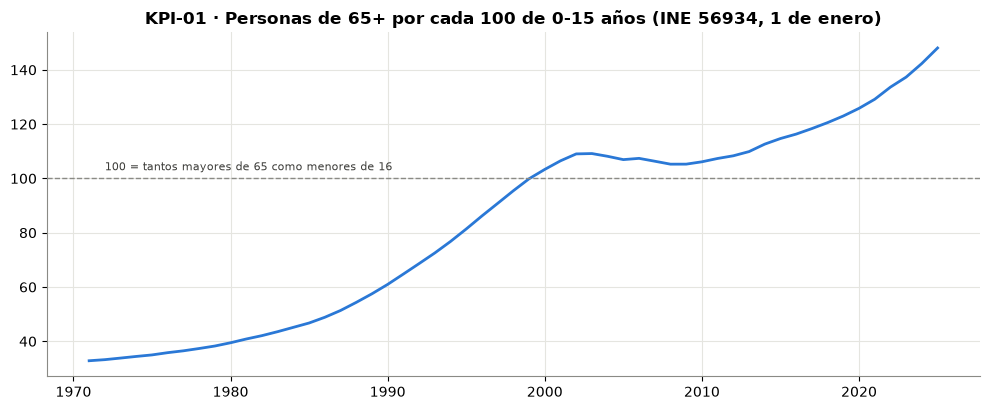

**Respuesta P1.** El peso de 65+ pasó de 9,7 % a 20,7 % y el índice de envejecimiento de 32,8 a 148,1 (×4,5). Desde 2000 hay más mayores de 65 que menores de 16.

In [71]:
p1 = poblacion.loc[[1971, 2025], ["total", "65+", "% 65+", "indice_envejecimiento"]]
display(p1.round(2))
fig, ax = plt.subplots()
ax.plot(poblacion.index, poblacion["indice_envejecimiento"], color=SERIES[0], label="Índice de envejecimiento (KPI-01)")
ax.axhline(100, color="#8a8a85", linestyle="--", linewidth=1)
ax.annotate("100 = tantos mayores de 65 como menores de 16", (1972, 103), fontsize=8, color=TINTA)
anyo_cruce = poblacion.index[poblacion["indice_envejecimiento"] < 100].max() + 1     # desde entonces, siempre por encima de 100
ax.set_title("KPI-01 · Personas de 65+ por cada 100 de 0-15 años (INE 56934, 1 de enero)")
plt.tight_layout(); plt.show()
responder(1, "¿Cuánto ha envejecido la población entre 1971 y 2025?", "KPI-01 · O3",
          f"El peso de 65+ pasó de {es(p1.loc[1971, '% 65+'], 1)} % a {es(p1.loc[2025, '% 65+'], 1)} % y el índice de envejecimiento de "
          f"{es(p1.loc[1971, 'indice_envejecimiento'], 1)} a {es(p1.loc[2025, 'indice_envejecimiento'], 1)} (×{es(p1.loc[2025, 'indice_envejecimiento'] / p1.loc[1971, 'indice_envejecimiento'], 1)}). "
          f"Desde {anyo_cruce} hay más mayores de 65 que menores de 16.")

### P2. ¿La tasa de dependencia total refleja bien la presión sobre las pensiones?

,dependencia_total,dependencia_juvenil,dependencia_mayores
Anyo,,,
1971,64.21,48.34,15.87
2025,53.17,21.43,31.73


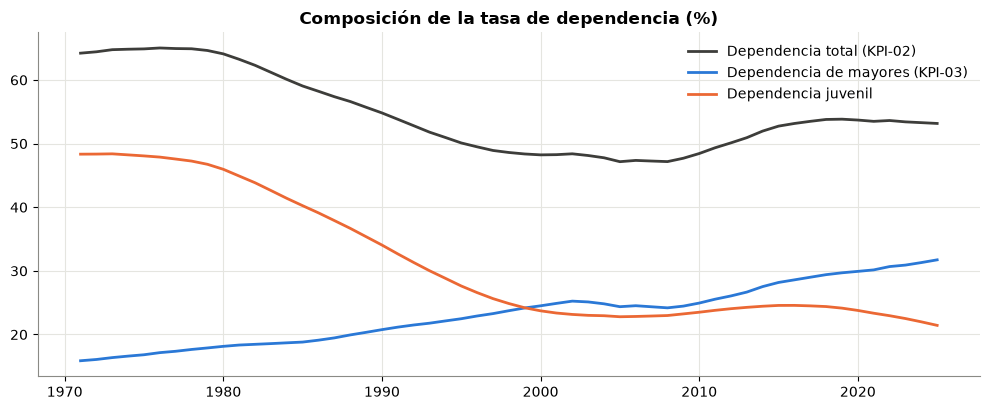

**Respuesta P2.** No por sí sola: la dependencia total bajó de 64,2 % a 53,2 % porque la juvenil cayó de 48,3 % a 21,4 %, mientras la de mayores subió de 15,9 % a 31,7 % (×2,00). Para un sistema de reparto el indicador relevante es la dependencia de mayores.

In [72]:
p2 = poblacion.loc[[1971, 2025], ["dependencia_total", "dependencia_juvenil", "dependencia_mayores"]]
display(p2.round(2))
fig, ax = plt.subplots()
for columna, color, etiqueta in [("dependencia_total", TINTA, "Dependencia total (KPI-02)"), ("dependencia_mayores", SERIES[0], "Dependencia de mayores (KPI-03)"),
                                 ("dependencia_juvenil", SERIES[1], "Dependencia juvenil")]:
    ax.plot(poblacion.index, poblacion[columna], color=color, label=etiqueta)
ax.set_title("Composición de la tasa de dependencia (%)"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
responder(2, "¿La dependencia total refleja la presión sobre las pensiones?", "KPI-02 y KPI-03 · O3",
          f"No por sí sola: la dependencia total bajó de {es(p2.loc[1971, 'dependencia_total'], 1)} % a {es(p2.loc[2025, 'dependencia_total'], 1)} % porque la juvenil cayó de "
          f"{es(p2.loc[1971, 'dependencia_juvenil'], 1)} % a {es(p2.loc[2025, 'dependencia_juvenil'], 1)} %, mientras la de mayores subió de "
          f"{es(p2.loc[1971, 'dependencia_mayores'], 1)} % a {es(p2.loc[2025, 'dependencia_mayores'], 1)} % (×{es(p2.loc[2025, 'dependencia_mayores'] / p2.loc[1971, 'dependencia_mayores'], 2)}). "
          "Para un sistema de reparto el indicador relevante es la dependencia de mayores.")

## Bloque B · Natalidad, mortalidad y migración (KPI-04, KPI-05, KPI-06)

### P3. ¿Desde cuándo la fecundidad está por debajo del nivel de reemplazo y cuál es su mínimo?

In [73]:
icf = df_ine[df_ine.tabla_id == "1407"].set_index("Anyo")["Valor"].sort_index()
bajo_reemplazo = icf < 2.1
desde_reemplazo = icf.index[~bajo_reemplazo].max() + 1          # primer año de la racha actual por debajo de 2,1
display(icf.loc[sorted({icf.index.min(), desde_reemplazo - 1, desde_reemplazo, icf.idxmin(), icf.index.max()})].to_frame("ICF (hijos por mujer)").T)
responder(3, "¿Desde cuándo la fecundidad está bajo el reemplazo y cuál es su mínimo?", "KPI-04 · O3",
          f"Por debajo de 2,1 hijos por mujer de forma ininterrumpida desde {desde_reemplazo} ({icf.index.max() - desde_reemplazo + 1} años). "
          f"El mínimo de la serie es {es(icf.min(), 2)} en {icf.idxmin()} (primer dato: {es(icf.iloc[0], 2)} en {icf.index[0]}).")

Anyo,1975,1980,1981,2024
ICF (hijos por mujer),2.77,2.21,2.04,1.1


**Respuesta P3.** Por debajo de 2,1 hijos por mujer de forma ininterrumpida desde 1981 (44 años). El mínimo de la serie es 1,10 en 2024 (primer dato: 2,77 en 1975).

### P4. ¿Desde qué año mueren más personas de las que nacen?
Manejo mínimo: la tabla 6566 trae cada serie tres veces; se conserva una copia de cada `(COD, Fecha)` para no triplicar los totales.

In [74]:
mnp = df_ine[df_ine.tabla_id == "6566"].drop_duplicates(["COD", "Fecha"])
vegetativo = mnp.pivot_table(index="Anyo", columns="concepto", values="Valor")
vegetativo["saldo_vegetativo"] = vegetativo["Nacimiento"] - vegetativo["Defunción"]
negativo = vegetativo["saldo_vegetativo"] < 0
desde_negativo = vegetativo.index[~negativo].max() + 1
display(vegetativo.loc[desde_negativo - 2:].round().astype("Int64"))
responder(4, "¿Desde qué año el saldo vegetativo es negativo?", "KPI-05 · O3",
          f"Desde {desde_negativo} el saldo vegetativo es negativo todos los años; en {vegetativo.index.max()} fue de "
          f"{es(vegetativo['saldo_vegetativo'].iloc[-1], 0)} personas ({es(vegetativo['Nacimiento'].iloc[-1], 0)} nacimientos frente a "
          f"{es(vegetativo['Defunción'].iloc[-1], 0)} defunciones).")

concepto,Defunción,Nacimiento,saldo_vegetativo
Anyo,,,
2013,390419,425715,35296
2014,395830,427595,31765
2015,422568,420290,-2278
2016,410611,410583,-28
2017,424523,393181,-31342
2018,427721,372777,-54944
2019,418703,360617,-58086
2020,493776,341315,-152461
2021,450744,337380,-113364


**Respuesta P4.** Desde 2015 el saldo vegetativo es negativo todos los años; en 2024 fue de -118.113 personas (318.005 nacimientos frente a 436.118 defunciones).

### P5. ¿Cuánto compensa la migración exterior el saldo natural negativo?

,24309 (hasta 2021),69758 (desde 2021),saldo_vegetativo
Anyo,,,
2018,334158,<NA>,-54944
2019,454232,<NA>,-58086
2020,219357,<NA>,-152461
2021,148070,191094,-113364
2022,<NA>,727005,-135166
2023,<NA>,642296,-115468
2024,<NA>,626268,-118113


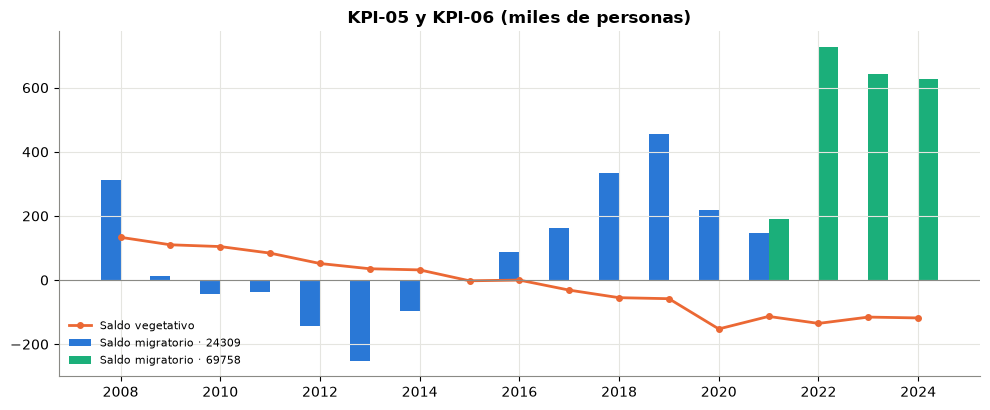

**Respuesta P5.** En 2024 el saldo migratorio exterior fue de 626.268 personas, frente a un saldo vegetativo de -118.113: el crecimiento de la población depende de la inmigración. Ojo: 2021 aparece en las dos operaciones con valores distintos (148.070 y 191.094), por lo que 2020 y 2022 no son directamente comparables.

In [75]:
migracion = pd.DataFrame({"24309 (hasta 2021)": df_ine[df_ine.tabla_id == "24309"].set_index("Anyo")["Valor"],
                          "69758 (desde 2021)": df_ine[df_ine.tabla_id == "69758"].set_index("Anyo")["Valor"]})
migracion["saldo_vegetativo"] = vegetativo["saldo_vegetativo"]
display(migracion.loc[2018:].round().astype("Int64"))
fig, ax = plt.subplots()
ax.bar(migracion.index - 0.2, migracion["24309 (hasta 2021)"] / 1e3, width=0.4, color=SERIES[0], label="Saldo migratorio · 24309")
ax.bar(migracion.index + 0.2, migracion["69758 (desde 2021)"] / 1e3, width=0.4, color=SERIES[2], label="Saldo migratorio · 69758")
ax.plot(migracion.index, migracion["saldo_vegetativo"] / 1e3, color=SERIES[1], marker="o", markersize=4, label="Saldo vegetativo")
ax.axhline(0, color="#8a8a85", linewidth=0.8)
ax.set_xticks(migracion.index[::2])
ax.set_title("KPI-05 y KPI-06 (miles de personas)"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()
ultimo = migracion["69758 (desde 2021)"].last_valid_index()
responder(5, "¿Cuánto compensa la migración el saldo natural negativo?", "KPI-06 · O3",
          f"En {ultimo} el saldo migratorio exterior fue de {es(migracion.loc[ultimo, '69758 (desde 2021)'], 0)} personas, frente a un saldo vegetativo de "
          f"{es(migracion.loc[ultimo, 'saldo_vegetativo'], 0)}: el crecimiento de la población depende de la inmigración. "
          f"Ojo: 2021 aparece en las dos operaciones con valores distintos ({es(migracion.loc[2021, '24309 (hasta 2021)'], 0)} y "
          f"{es(migracion.loc[2021, '69758 (desde 2021)'], 0)}), por lo que 2020 y 2022 no son directamente comparables.")

### P6. ¿Cuántos años se vive, de media, después de los 65 y cómo ha cambiado por sexo?

In [76]:
ev65 = df_ine[df_ine.tabla_id == "1415"].pivot_table(index="Anyo", columns="sexo", values="Valor")
ev_nacer = df_ine[df_ine.tabla_id == "1414"].pivot_table(index="Anyo", columns="sexo", values="Valor")
primero, ultimo = ev65.index.min(), ev65.index.max()
display(pd.concat({"a los 65": ev65.loc[[primero, 2019, 2020, ultimo]], "al nacer": ev_nacer.loc[[primero, ultimo]]}, axis=1).round(2))
responder(6, "¿Cuántos años se vive tras los 65 y cómo cambió por sexo?", "Contexto KPI-03 / gasto · O3",
          f"La esperanza de vida a los 65 años pasó de {es(ev65.loc[primero, 'Ambos sexos'], 1)} a {es(ev65.loc[ultimo, 'Ambos sexos'], 1)} años ({primero}–{ultimo}); "
          f"mujeres +{es(ev65.loc[ultimo, 'Mujeres'] - ev65.loc[primero, 'Mujeres'], 1)} y hombres +{es(ev65.loc[ultimo, 'Hombres'] - ev65.loc[primero, 'Hombres'], 1)} años. "
          f"Una pensión de jubilación se cobra hoy durante más años. En 2020 cayó a {es(ev65.loc[2020, 'Ambos sexos'], 1)} (COVID-19).")

a los 65                    al nacer                
sexo Ambos sexos Hombres Mujeres Ambos sexos Hombres Mujeres
Anyo                                                        
1975       15.19   13.62   16.49       73.44   70.53   76.25
2019       21.52   19.44   23.38         NaN     NaN     NaN
2020       20.35   18.26   22.29         NaN     NaN     NaN
2024       21.87   19.87   23.64       84.01   81.38   86.53

**Respuesta P6.** La esperanza de vida a los 65 años pasó de 15,2 a 21,9 años (1975–2024); mujeres +7,2 y hombres +6,3 años. Una pensión de jubilación se cobra hoy durante más años. En 2020 cayó a 20,4 (COVID-19).

## Bloque C · Cotización y pensiones (KPI-07)

### P7. ¿Cómo ha evolucionado la afiliación y cuánto empleo se perdió en las crisis?
Manejo mínimo: se descartan las notas al pie (sin valor en `TOTAL SISTEMA`) y se convierte la etiqueta "Mes Año" en año y mes para ordenar y filtrar.

,afiliados,hito
fecha,,
2008-05-01,19384101.0,máximo antes de la crisis de 2008
2013-01-01,16083780.0,valle de la crisis
2020-02-01,19279415.0,antes de la COVID-19
2020-04-01,18396362.0,valle COVID-19
2026-05-01,22376159.0,máximo histórico
2026-09-01,22364242.0,último dato


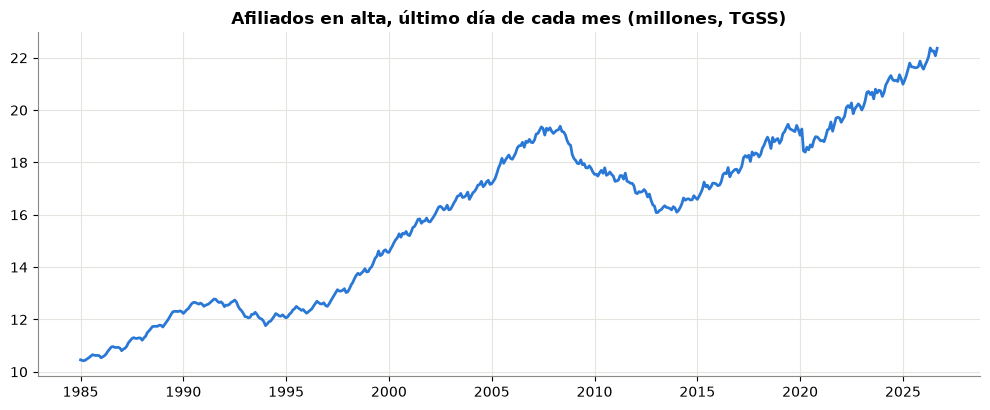

**Respuesta P7.** La crisis de 2008 restó 3,30 millones de afiliados (05/2008 → 01/2013); El COVID-19, 883 mil en dos meses. El máximo histórico es 22,38 millones (05/2026).

In [79]:
MESES = {m: i for i, m in enumerate(["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"], 1)}
afiliacion = df_afiliados.loc[df_afiliados["TOTAL SISTEMA"].notna(), ["Periodo", "TOTAL SISTEMA"]].copy()
partes = afiliacion["Periodo"].str.split()
afiliacion["anyo"], afiliacion["mes"] = partes.str[-1].astype(int), partes.str[0].map(MESES)
afiliacion["fecha"] = pd.to_datetime(dict(year=afiliacion.anyo, month=afiliacion.mes, day=1))
serie_af = afiliacion.set_index("fecha")["TOTAL SISTEMA"]

pico_2007 = serie_af[:"2008-12"].idxmax(); valle_crisis = serie_af["2008":"2014"].idxmin()
covid_antes, covid_valle = serie_af["2020-02"].index[0], serie_af["2020-03":"2020-06"].idxmin()
display(pd.DataFrame({"afiliados": serie_af.loc[[pico_2007, valle_crisis, covid_antes, covid_valle, serie_af.idxmax(), serie_af.index[-1]]]},
                     ).assign(hito=["máximo antes de la crisis de 2008", "valle de la crisis", "antes de la COVID-19", "valle COVID-19", "máximo histórico", "último dato"]))
fig, ax = plt.subplots()
ax.plot(serie_af.index, serie_af / 1e6, color=SERIES[0])
ax.set_title("Afiliados en alta, último día de cada mes (millones, TGSS)")
plt.tight_layout(); plt.show()
responder(7, "¿Cómo evolucionó la afiliación y cuánto empleo se perdió en las crisis?", "Contexto KPI-07 · O3",
          f"La crisis de 2008 restó {es((serie_af[pico_2007] - serie_af[valle_crisis]) / 1e6, 2)} millones de afiliados ({pico_2007:%m/%Y} → {valle_crisis:%m/%Y}); "
          f"El COVID-19, {es((serie_af[covid_antes] - serie_af[covid_valle]) / 1e3, 0)} mil en dos meses. El máximo histórico es "
          f"{es(serie_af.max() / 1e6, 2)} millones ({serie_af.idxmax():%m/%Y}).")

### P8. ¿Cuántos afiliados hay por cada pensión contributiva (KPI-07) y mejora o empeora?
Manejo mínimo: diciembre de afiliados (último día del mes) frente a las filas anuales de pensiones («datos a diciembre»), antes de la sección de porcentajes.

In [80]:
pensiones_anual = df_pensiones[(tipo_fila == "dato anual (diciembre)") & (df_pensiones.hoja == "Nº Pens. Clases")].copy()
pensiones_anual["anyo"] = pensiones_anual["PERIODO"].astype(int)
pensiones_anual = pensiones_anual.set_index("anyo")
afiliados_dic = afiliacion[afiliacion.mes == 12].set_index("anyo")["TOTAL SISTEMA"]
ratio = pd.DataFrame({"afiliados_diciembre": afiliados_dic, "pensiones_diciembre": pensiones_anual["TOTAL"]}).dropna()
ratio["afiliados_por_pension"] = ratio.afiliados_diciembre / ratio.pensiones_diciembre
crec_af = ratio.afiliados_diciembre.iloc[-1] / ratio.afiliados_diciembre.iloc[0] - 1
crec_pen = ratio.pensiones_diciembre.iloc[-1] / ratio.pensiones_diciembre.iloc[0] - 1
display(ratio.round(3))
responder(8, "¿Cuántos afiliados hay por pensión y cómo evoluciona?", "KPI-07 · O2",
          f"Pasó de {es(ratio.afiliados_por_pension.iloc[0], 2)} ({ratio.index[0]}) a {es(ratio.afiliados_por_pension.iloc[-1], 2)} ({ratio.index[-1]}): "
          f"los afiliados crecieron {es((crec_af) * 100, 0)} % y las pensiones {es((crec_pen) * 100, 0)} %. El indicador es por **pensión**, no por pensionista "
          "(una persona puede cobrar más de una pensión).")

,afiliados_diciembre,pensiones_diciembre,afiliados_por_pension
anyo,,,
2016,17741897.0,9473482.0,1.873
2017,18331107.0,9581770.0,1.913
2018,18914563.0,9696272.0,1.951
2019,19261636.0,9801379.0,1.965
2020,18904852.0,9809019.0,1.927
2021,19703812.0,9916966.0,1.987
2022,20159317.0,9994836.0,2.017
2023,20733042.0,10111991.0,2.050
2024,21201126.0,10281477.0,2.062


**Respuesta P8.** Pasó de 1,87 (2016) a 2,08 (2025): los afiliados crecieron 22 % y las pensiones 10 %. El indicador es por **pensión**, no por pensionista (una persona puede cobrar más de una pensión).

### P9. ¿Qué clase de pensión predomina y cómo cambia la composición?

In [81]:
clases = ["JUBILACIÓN", "VIUDEDAD", "INCAPACIDAD PERMANENTE", "ORFANDAD", "F. FAMILIAR"]
composicion = pensiones_anual[clases].astype(float).div(pensiones_anual["TOTAL"], axis=0) * 100
display(composicion.loc[[ratio.index[0], ratio.index[-1]]].round(1))
responder(9, "¿Qué clase de pensión predomina y cómo cambia?", "Contexto KPI-07 / KPI-08",
          f"La jubilación pasó de {es(composicion['JUBILACIÓN'].iloc[0], 1)} % a {es(composicion['JUBILACIÓN'].iloc[-1], 1)} % de las pensiones y la viudedad de "
          f"{es(composicion['VIUDEDAD'].iloc[0], 1)} % a {es(composicion['VIUDEDAD'].iloc[-1], 1)} %: el crecimiento del sistema viene de la jubilación, "
          "la clase más ligada al envejecimiento.")

,JUBILACIÓN,VIUDEDAD,INCAPACIDAD PERMANENTE,ORFANDAD,F. FAMILIAR
anyo,,,,,
2016,61.1,25.0,10.0,3.6,0.4
2025,63.7,22.5,10.1,3.2,0.4


**Respuesta P9.** La jubilación pasó de 61,1 % a 63,7 % de las pensiones y la viudedad de 25,0 % a 22,5 %: el crecimiento del sistema viene de la jubilación, la clase más ligada al envejecimiento.

### P10. ¿Cuál es la pensión media y cuánto ha crecido?
El importe de la nómina está en miles de euros al mes; la pensión media es importe × 1.000 / número de pensiones.

In [82]:
importe_anual = df_pensiones[(tipo_fila == "dato anual (diciembre)") & (df_pensiones.hoja == "Importe €")].copy()
importe_anual = importe_anual.set_index(importe_anual["PERIODO"].astype(int))
pension_media = (importe_anual["TOTAL"] * 1000 / pensiones_anual["TOTAL"]).rename("pensión media (€/mes)")
display(pension_media.round(2).to_frame().T)
responder(10, "¿Cuál es la pensión media y cuánto creció?", "Contexto KPI-08 · O3",
          f"La pensión contributiva media de diciembre pasó de {es(pension_media.iloc[0], 0)} € ({pension_media.index[0]}) a {es(pension_media.iloc[-1], 0)} € "
          f"({pension_media.index[-1]}), un {es((pension_media.iloc[-1] / pension_media.iloc[0] - 1) * 100, 0)} % más, mientras el número de pensiones creció un {es((crec_pen) * 100, 0)} %.")

PERIODO,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
pensión media (€/mes),910.24,926.87,960.98,995.76,1017.97,1039.54,1094.87,1198.65,1261.9,1317.71


**Respuesta P10.** La pensión contributiva media de diciembre pasó de 910 € (2016) a 1.318 € (2025), un 45 % más, mientras el número de pensiones creció un 10 %.

## Bloque D · Sostenibilidad financiera (KPI-08)

### P11. ¿Cuánto pesa el gasto en pensiones sobre el PIB y cuándo alcanzó su máximo?

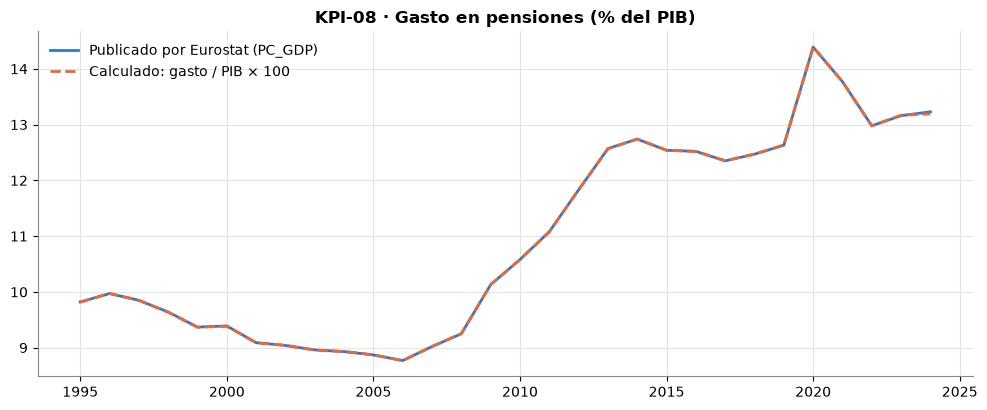

Diferencia máxima entre el calculado y el publicado: 0,039 puntos


**Respuesta P11.** Pasó de 9,8 % (1995) a 13,2 % (2024); el máximo fue 14,4 % en 2020, año en que cayó el PIB.

In [83]:
eu = df_eurostat.assign(anyo=df_eurostat["time"].astype(int))
gasto_pib_publicado = eu[(eu.dataset_id == "gasto_pensiones") & (eu.unit == "PC_GDP")].set_index("anyo")["valor"]
gasto_meur = eu[(eu.dataset_id == "gasto_pensiones") & (eu.unit == "MIO_EUR")].set_index("anyo")["valor"]
pib = eu[eu.dataset_id == "pib"].set_index("anyo")["valor"]
gasto_pib_calculado = (gasto_meur / pib * 100).dropna()
fig, ax = plt.subplots()
ax.plot(gasto_pib_publicado.index, gasto_pib_publicado, color=SERIES[0], label="Publicado por Eurostat (PC_GDP)")
ax.plot(gasto_pib_calculado.index, gasto_pib_calculado, "--", color=SERIES[1], label="Calculado: gasto / PIB × 100")
ax.set_title("KPI-08 · Gasto en pensiones (% del PIB)"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print(f"Diferencia máxima entre el calculado y el publicado: {es((gasto_pib_calculado - gasto_pib_publicado).abs().max(), 3)} puntos")
responder(11, "¿Cuánto pesa el gasto en pensiones sobre el PIB y cuándo fue máximo?", "KPI-08 · O2",
          f"Pasó de {es(gasto_pib_publicado.iloc[0], 1)} % ({gasto_pib_publicado.index[0]}) a {es(gasto_pib_publicado.iloc[-1], 1)} % ({gasto_pib_publicado.index[-1]}); "
          f"el máximo fue {es(gasto_pib_publicado.max(), 1)} % en {gasto_pib_publicado.idxmax()}, año en que cayó el PIB.")

### P12. ¿Crece el gasto en pensiones más rápido que la economía?

In [84]:
inicio, fin = max(gasto_meur.index.min(), pib.index.min()), min(gasto_meur.index.max(), pib.index.max())
crecimiento = pd.DataFrame({"gasto en pensiones (M€)": gasto_meur.loc[[inicio, fin]], "PIB (M€)": pib.loc[[inicio, fin]]})
crecimiento.loc["crecimiento %"] = (crecimiento.loc[fin] / crecimiento.loc[inicio] - 1) * 100
display(crecimiento.round(1))
responder(12, "¿Crece el gasto en pensiones más rápido que el PIB?", "KPI-08 · O3",
          f"Sí: entre {inicio} y {fin} el gasto nominal creció un {es(crecimiento.loc['crecimiento %', 'gasto en pensiones (M€)'], 0)} % y el PIB nominal un "
          f"{es(crecimiento.loc['crecimiento %', 'PIB (M€)'], 0)} %.")

,gasto en pensiones (M€),PIB (M€)
anyo,,
1995,46115.2,469819.9
2024,210875.2,1598588.0
crecimiento %,357.3,240.3


**Respuesta P12.** Sí: entre 1995 y 2024 el gasto nominal creció un 357 % y el PIB nominal un 240 %.

### P13. ¿Son consistentes las fuentes? (población del INE frente a Eurostat)

In [85]:
pob_eurostat = eu[eu.dataset_id == "poblacion_control"].set_index("anyo")["valor"]
consistencia = pd.DataFrame({"INE": poblacion["total"], "Eurostat": pob_eurostat}).dropna()
consistencia["diferencia_%"] = (consistencia.INE - consistencia.Eurostat) / consistencia.Eurostat * 100
display(consistencia.tail(3))
responder(13, "¿Son consistentes la población del INE y la de Eurostat?", "O1 · KR1.2 calidad",
          f"Sí: en los {len(consistencia)} años comunes ({consistencia.index.min()}–{consistencia.index.max()}) la diferencia relativa máxima es "
          f"{es(consistencia['diferencia_%'].abs().max(), 4)} %. Eurostat recibe la población del INE, así que sirve como control de la extracción.")

,INE,Eurostat,diferencia_%
2023,48085361.0,48085361.0,0.0
2024,48619695.0,48619695.0,0.0
2025,49128297.0,49128297.0,0.0


**Respuesta P13.** Sí: en los 55 años comunes (1971–2025) la diferencia relativa máxima es 0,0002 %. Eurostat recibe la población del INE, así que sirve como control de la extracción.

## Bloque E · Escenarios oficiales y relación entre demografía y gasto (KR3.1)

### P14. ¿Qué dicen las Proyecciones de Población del INE para 2050?
Se usan las proyecciones **oficiales** del INE (tabla 36652, 8 escenarios); el proyecto no proyecta nada por su cuenta.

,total,% 65+,dependencia_mayores,indice_envejecimiento
Fecundidad y saldo migratorio altos,58567019.16,28.64,49.85,206.05
Saldo migratorio alto,57152510.15,29.34,50.11,242.15
Fecundidad alta,55933214.95,29.30,51.52,211.82
Central,54558627.78,30.02,51.81,249.57
Fecundidad baja,53168640.95,30.79,52.11,303.95
Saldo migratorio bajo,51967457.66,30.76,53.67,257.57
Fecundidad y saldo migratorio bajos,50618076.81,31.56,54.01,314.90
Saldo migratorio nulo,44027722.09,36.95,69.89,363.20


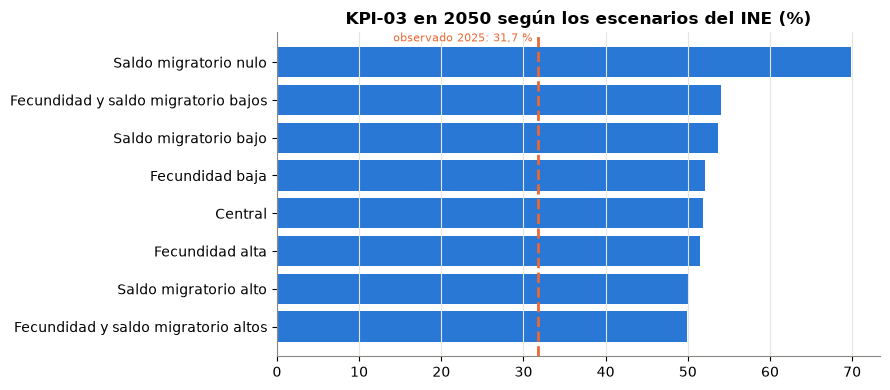

**Respuesta P14.** En los 8 escenarios la dependencia de mayores de 2050 estaría entre 49,8 % (Fecundidad y saldo migratorio altos) y 69,9 % (Saldo migratorio nulo), frente a 31,7 % en 2025: ningún escenario oficial revierte el envejecimiento.

In [86]:
escenarios = sorted(df_ine.loc[df_ine.tabla_id == "36652", "escenario_o_tipo_saldo"].dropna().unique())
proyeccion_2050 = pd.DataFrame({e: grupos_edad("36652", escenario=e).loc[2050, ["total", "% 65+", "dependencia_mayores", "indice_envejecimiento"]]
                                for e in escenarios}).T.sort_values("dependencia_mayores")
ultimo_obs = poblacion.index.max()
display(proyeccion_2050.round(2))
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(proyeccion_2050.index, proyeccion_2050["dependencia_mayores"], color=SERIES[0])
ax.grid(axis="y", visible=False)
ax.axvline(poblacion.loc[ultimo_obs, "dependencia_mayores"], color=SERIES[1], linestyle="--")
ax.annotate(f"observado {ultimo_obs}: {es(poblacion.loc[ultimo_obs, 'dependencia_mayores'], 1)} %", (poblacion.loc[ultimo_obs, "dependencia_mayores"], len(proyeccion_2050) - 0.45),
            xytext=(-4, 0), textcoords="offset points", ha="right", fontsize=8, color=SERIES[1])
ax.set_title("KPI-03 en 2050 según los escenarios del INE (%)")
plt.tight_layout(); plt.show()
responder(14, "¿Qué dicen las proyecciones oficiales para 2050?", "KPI-03 · KR3.1",
          f"En los {len(escenarios)} escenarios la dependencia de mayores de 2050 estaría entre {es(proyeccion_2050['dependencia_mayores'].min(), 1)} % "
          f"({proyeccion_2050.index[0]}) y {es(proyeccion_2050['dependencia_mayores'].max(), 1)} % ({proyeccion_2050.index[-1]}), frente a "
          f"{es(poblacion.loc[ultimo_obs, 'dependencia_mayores'], 1)} % en {ultimo_obs}: ningún escenario oficial revierte el envejecimiento.")

### P15. ¿Se mueve el gasto en pensiones con la dependencia de mayores?

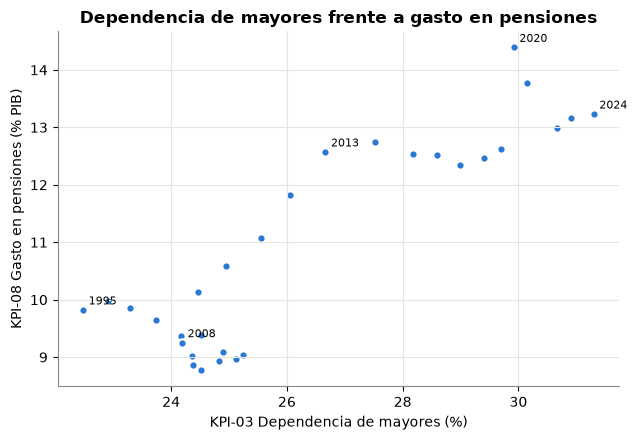

**Respuesta P15.** Sí, de forma descriptiva: la correlación de Pearson 1995–2024 es 0,89. No es una relación causal: el gasto/PIB también depende del ciclo económico (denominador), de la revalorización y de la pensión media.

In [87]:
relacion = pd.DataFrame({"dependencia_mayores": poblacion["dependencia_mayores"], "gasto_pib": gasto_pib_publicado}).dropna()
correlacion = relacion.corr().iloc[0, 1]
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(relacion.dependencia_mayores, relacion.gasto_pib, s=36, color=SERIES[0], edgecolor="white", linewidth=1.5)
for anyo in [relacion.index.min(), 2008, 2013, 2020, relacion.index.max()]:
    ax.annotate(anyo, (relacion.loc[anyo, "dependencia_mayores"], relacion.loc[anyo, "gasto_pib"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel("KPI-03 Dependencia de mayores (%)"); ax.set_ylabel("KPI-08 Gasto en pensiones (% PIB)")
ax.set_title("Dependencia de mayores frente a gasto en pensiones")
plt.tight_layout(); plt.show()
responder(15, "¿Se mueve el gasto con la dependencia de mayores?", "KPI-03 × KPI-08 · O3",
          f"Sí, de forma descriptiva: la correlación de Pearson {relacion.index.min()}–{relacion.index.max()} es {es(correlacion, 2)}. "
          "No es una relación causal: el gasto/PIB también depende del ciclo económico (denominador), de la revalorización y de la pensión media.")

## Síntesis: respuestas, OKRs y conclusiones sobre el reto demográfico

In [88]:
pd.set_option("display.max_colwidth", 400)
display(pd.DataFrame(respuestas).set_index("#"))
pd.set_option("display.max_colwidth", 45)

,pregunta,OKR / KPI,respuesta
#,,,
1,¿Cuánto ha envejecido la población entre 1971 y 2025?,KPI-01 · O3,"El peso de 65+ pasó de 9,7 % a 20,7 % y el índice de envejecimiento de 32,8 a 148,1 (×4,5). Desde 2000 hay más mayores de 65 que menores de 16."
2,¿La dependencia total refleja la presión sobre las pensiones?,KPI-02 y KPI-03 · O3,"No por sí sola: la dependencia total bajó de 64,2 % a 53,2 % porque la juvenil cayó de 48,3 % a 21,4 %, mientras la de mayores subió de 15,9 % a 31,7 % (×2,00). Para un sistema de reparto el indicador relevante es la dependencia de mayores."
3,¿Desde cuándo la fecundidad está bajo el reemplazo y cuál es su mínimo?,KPI-04 · O3,"Por debajo de 2,1 hijos por mujer de forma ininterrumpida desde 1981 (44 años). El mínimo de la serie es 1,10 en 2024 (primer dato: 2,77 en 1975)."
4,¿Desde qué año el saldo vegetativo es negativo?,KPI-05 · O3,Desde 2015 el saldo vegetativo es negativo todos los años; en 2024 fue de -118.113 personas (318.005 nacimientos frente a 436.118 defunciones).
5,¿Cuánto compensa la migración el saldo natural negativo?,KPI-06 · O3,"En 2024 el saldo migratorio exterior fue de 626.268 personas, frente a un saldo vegetativo de -118.113: el crecimiento de la población depende de la inmigración. Ojo: 2021 aparece en las dos operaciones con valores distintos (148.070 y 191.094), por lo que 2020 y 2022 no son directamente comparables."
6,¿Cuántos años se vive tras los 65 y cómo cambió por sexo?,Contexto KPI-03 / gasto · O3,"La esperanza de vida a los 65 años pasó de 15,2 a 21,9 años (1975–2024); mujeres +7,2 y hombres +6,3 años. Una pensión de jubilación se cobra hoy durante más años. En 2020 cayó a 20,4 (COVID-19)."
7,¿Cómo evolucionó la afiliación y cuánto empleo se perdió en las crisis?,Contexto KPI-07 · O3,"La crisis de 2008 restó 3,30 millones de afiliados (05/2008 → 01/2013); la COVID-19, 883 mil en dos meses. El máximo histórico es 22,38 millones (05/2026)."
7,¿Cómo evolucionó la afiliación y cuánto empleo se perdió en las crisis?,Contexto KPI-07 · O3,"La crisis de 2008 restó 3,30 millones de afiliados (05/2008 → 01/2013); la COVID-19, 883 mil en dos meses. El máximo histórico es 22,38 millones (05/2026)."
7,¿Cómo evolucionó la afiliación y cuánto empleo se perdió en las crisis?,Contexto KPI-07 · O3,"La crisis de 2008 restó 3,30 millones de afiliados (05/2008 → 01/2013); El COVID-19, 883 mil en dos meses. El máximo histórico es 22,38 millones (05/2026)."


**Conclusiones:**

1. **El envejecimiento es estructural** (P1, P2, P14). La dependencia de mayores casi se ha duplicado desde 1971 y los ocho escenarios oficiales la sitúan muy por encima del nivel actual en 2050. La caída de la dependencia total es engañosa: refleja menos jóvenes, no menos presión.
2. **La base demográfica no se repone sola** (P3, P4, P5). La fecundidad lleva décadas por debajo del reemplazo, el saldo vegetativo es negativo y la población solo crece por migración, una variable volátil y con una ruptura metodológica en 2021.
3. **Más años cobrando** (P6, P9, P10). La longevidad a los 65 años aumenta, la jubilación gana peso en el total de pensiones y la pensión media crece más que el número de pensiones.
4. **El empleo amortigua, pero no compensa por sí solo** (P7, P8). La relación afiliados/pensión mejoró en la última década gracias al empleo, pero es sensible a las crisis (2008, COVID-19).
5. **El gasto crece más que la economía** (P11, P12, P15). Su peso en el PIB ha subido y se mueve con la dependencia de mayores; atribuir causas exige un modelo con supuestos económicos, que queda fuera del ETL (retroalimentación del profesor).
6. **Calidad y trazabilidad (O1)** (P13). La consistencia INE-Eurostat valida la extracción. Todo lo anterior se calculó a mano sobre el dato original; la Parte 6 muestra cómo el pipeline lo convierte en datos limpios, KPIs y un modelo para Power BI.

# PARTE 6 · Transformación con arquitectura Medallion

| Capa | Qué contiene | Reglas | Dónde |
|---|---|---|---|
| **Bronce** | Los datos originales, byte a byte, con manifiesto | Inmutable; nunca se corrige | `data/bronze/` (Parte 1) |
| **Plata** | Datos depurados: tipados, en formato largo, con categorías normalizadas, sin duplicados ni filas de formato | Esquemas explícitos, mapeos estrictos, reglas de calidad bloqueantes | `data/silver/` |
| **Oro** | Datos integrados: KPIs, modelo en estrella con las tres fuentes y escenarios oficiales en una capa aparte | Fórmula única por KPI, claves estables, integridad referencial | `data/gold/` → `data/serving/` |

**Principio de tratamiento:** ninguna imputación automática. Cada nulo, duplicado y categoría tiene una decisión explícita y justificada en `config/config.yaml` y en el código de `src/transform/`. Si aparece algo no previsto (una etiqueta nueva, una columna nueva, un nulo donde no se espera), la capa se detiene en lugar de adivinar.

## 6.1 Bronce · verificación de integridad
Antes de promover datos a Plata se comprueba que cada archivo de Bronce está en exactamente un manifiesto, con el mismo tamaño y sha256. Un archivo alterado o huérfano detiene el pipeline.

In [89]:
from src.extract.bronze_integrity import BronzeIntegrityChecker

integridad = {}
for fuente in ("ine", "seguridad_social", "eurostat"):
    almacen = config["sources"][fuente]["storage"]
    informe = BronzeIntegrityChecker(almacen["payloads_path"], almacen["manifests_path"], [almacen["unmanifested_path"]]).check()
    integridad[fuente] = {"archivos": informe["payloads_checked"], "manifiestos": informe["manifests_checked"], "íntegro": informe["ok"],
                          **{problema: len(informe[problema]) for problema in ("orphans", "missing", "mismatches", "duplicates")}}
pd.DataFrame(integridad).T

,archivos,manifiestos,íntegro,orphans,missing,mismatches,duplicates
ine,117,9,True,0,0,0,0
seguridad_social,18,9,True,0,0,0,0
eurostat,27,9,True,0,0,0,0


## 6.2 Plata · ejecución de la transformación
Se ejecuta la etapa `plata` del pipeline sobre el último Bronce (el extraído en la Parte 1). Incluye la verificación de integridad y las tres transformaciones (`DemografiaTransform`, `SeguridadSocialTransform`, `EurostatTransform`), cada una con su reporte de calidad.

In [90]:
from src.pipeline import Pipeline
from src.utils.silver_reader import SilverReader


def leer(carpeta_manifiestos, conjunto):
    """Último conjunto con manifiesto completado (sha256 verificado). Las fechas Arrow se pasan a datetime de pandas."""
    frame = SilverReader(carpeta_manifiestos, conjunto).latest()["frame"]
    frame.attrs["tipos_parquet"] = frame.dtypes.astype(str).to_dict()
    for columna, tipo in frame.dtypes.items():
        if "date32" in str(tipo):
            frame[columna] = pd.to_datetime(frame[columna].astype(str))
    return frame


resultado_plata = Pipeline(config).run("plata", "plata")

─────────────── INICIO | Pipeline pipeline_20261003T232945.971778Z · etapas plata → plata · 4 pasos ───────────────

PASO | 1/4 · Bronce · verificación de integridad payload-manifiesto de las tres fuentes

  OK | ine: 117 archivos coinciden con sus 9 manifiestos (sin huérfanos ni diferencias)

  OK | seguridad_social: 18 archivos coinciden con sus 9 manifiestos (sin huérfanos ni diferencias)

  OK | eurostat: 27 archivos coinciden con sus 9 manifiestos (sin huérfanos ni diferencias)

...

  OK | Calidad de Plata Eurostat aprobada: 10 de 10 reglas cumplen

  OK | 162 filas en data/silver/macro/stg_macro_anual.parquet

  OK | Métricas: gasto_pensiones 1990–2024 · gasto_pensiones_pib_publicado 1995–2024 · pib 1995–2025 · 
poblacion_1_enero 1960–2025

  OK | Registro de ejecución: logs/ejecuciones/pipeline_20261003T232945.971778Z.json

──────────────────────────────────────── FIN | Pipeline completado en 12 s ────────────────────────────────────────

In [91]:
silver = config["silver"]
silver_ss = silver["seguridad_social"]
plata_ine = leer(silver["manifests_path"], silver["dataset_name"])
plata_afiliados = leer(silver_ss["manifests_path"], silver_ss["afiliados"]["dataset_name"])
plata_pensiones = leer(silver_ss["manifests_path"], silver_ss["pensiones"]["dataset_name"])
plata_importe = leer(silver_ss["manifests_path"], silver_ss["importe"]["dataset_name"])
plata_macro = leer(silver["eurostat"]["manifests_path"], silver["eurostat"]["dataset_name"])
plata = {"stg_poblacion_anual": plata_ine, "stg_afiliados_mensual": plata_afiliados, "stg_pensiones_cuantia": plata_pensiones,
         "stg_pensiones_importe": plata_importe, "stg_macro_anual": plata_macro}
pd.DataFrame([{"conjunto de Plata": n, "filas": len(f), "columnas": f.shape[1], "nulos": int(f.isna().sum().sum()),
               "run_id de Bronce": f["run_id"].iloc[0]} for n, f in plata.items()]).set_index("conjunto de Plata")

,filas,columnas,nulos,run_id de Bronce
conjunto de Plata,,,,
stg_poblacion_anual,142030,19,3385,ine_20261003T225152.878902Z
stg_afiliados_mensual,501,10,0,seguridad_social_20261003T225614.901428Z
stg_pensiones_cuantia,31,16,0,seguridad_social_20261003T225614.901428Z
stg_pensiones_importe,31,17,0,seguridad_social_20261003T225614.901428Z
stg_macro_anual,162,15,160,eurostat_20261003T230106.796927Z


In [92]:
# Antes y después: el mismo dato (población total, 1 de enero de 2025) en el original y en Plata
display(df_ine[(df_ine.tabla_id == "56934") & (df_ine.tipo_variable_edad == "todas las edades") & (df_ine.sexo == "Total") & a_1_enero
               & (df_ine.Anyo == 2025)][["tabla_id", "COD", "Nombre", "sexo", "edad", "Fecha", "Anyo", "Valor", "FK_Unidad"]])
plata_ine[(plata_ine.metrica == "poblacion") & (plata_ine.tipo_edad == "total") & (plata_ine.sexo == "total") & (plata_ine.anyo == 2025)
          & (plata_ine.escenario == "observado")]

,tabla_id,COD,Nombre,sexo,edad,Fecha,Anyo,Valor,FK_Unidad
35127,56934,ECP320,Total Nacional. Todas las edades. Total. ...,Total,Todas las edades,1735686000000,2025,49128297.0,3


,fuente,tabla_id,consulta,run_id,codigo_serie,fecha_referencia,anyo,territorio,sexo,edad_min,edad_max,edad_etiqueta_original,tipo_edad,metrica,valor,unidad,estado_dato,escenario,es_control
142010,Instituto Nacional de Estadística,56934,total_edad,ine_20261003T225152.878902Z,ECP320,2025-01-01,2025,ES,total,0,<NA>,Todas las edades,total,poblacion,49128297.0,personas,observado,observado,True


## 6.3 Estrategia de nulos, variable por variable

Opciones consideradas: mediana, media, moda, categoría NO INFORMADO, mantener el nulo, o descartar la fila/columna cuando no es un dato. La decisión depende de la causa del nulo (Parte 3.1). La tabla siguiente se genera con los nulos calculados sobre los DataFrames originales de la Parte 1.

In [94]:
def nulos(df, columnas):
    cuentas = [int(df[c].isna().sum()) for c in columnas]
    texto = lambda n: f"{n:,}".replace(",", ".")
    return texto(min(cuentas)) if min(cuentas) == max(cuentas) else f"{texto(min(cuentas))} a {texto(max(cuentas))}"

principales_af = ["TOTAL SISTEMA", "REGIMEN GENERAL | Régimen General (1)"]
regimenes = [c for c in df_afiliados.columns[1:] if df_afiliados[c].isna().sum() > df_afiliados["TOTAL SISTEMA"].isna().sum()]
decisiones = [
    ("INE · `Valor`", nulos(df_ine, ["Valor"]), "Edades simples 100-104 de 2002-2012 que el INE no publicó (publicaba el tramo «100 y más»)",
     "Se **descarta la fila vacía** (solo se admite en edades simples) y se conserva el tramo «100 y más», que sí trae el dato",
     "Imputar inventaría centenarios y rompería el cuadre con el total publicado (ver demostración)"),
    ("INE · `sexo`", nulos(df_ine, ["sexo"]), "Tablas sin desagregación por sexo (6566, 1407, 24309)", "Valor explícito **`total`**",
     "No es un dato desconocido: la serie cubre a ambos sexos. La moda («Hombres») sería falsa y «NO INFORMADO» ocultaría que es un total"),
    ("INE · `edad`, `tipo_variable_edad`", nulos(df_ine, ["edad", "tipo_variable_edad"]), "Tablas sin dimensión de edad",
     "`tipo_edad = total`, `edad_min = 0`, `edad_max` nulo; en fecundidad y esperanza de vida la edad es una **constante de la métrica**", "Igual que `sexo`"),
    ("INE · `escenario_o_tipo_saldo`", nulos(df_ine, ["escenario_o_tipo_saldo"]), "Solo existe en 36652 (escenarios) y en 69758 (tipo de saldo)",
     "**`observado`** en datos observados, **`central`** en 36643 y código normalizado en 36652", "El nulo significa «no es una proyección», y así se etiqueta"),
    ("INE · `territorio`, `concepto`", nulos(df_ine, ["territorio", "concepto"]), "La tabla 69758 los expresa en otras variables",
     "`territorio = ES`; la métrica sale de «Saldo exterior»", "El valor se conoce por la definición de la tabla"),
    ("INE · `tipo_dato`, `nacionalidad`, `pais_nacimiento`, `grupo_indicadores`, `periodicidad`, `orden_nacimiento`",
     nulos(df_ine, ["tipo_dato", "nacionalidad", "pais_nacimiento", "grupo_indicadores", "periodicidad", "orden_nacimiento"]),
     "Variables constantes de una o dos tablas", "Se **validan como constantes** (`constant_variables`) y no pasan a Plata", "No aportan información"),
    ("Afiliados · `TOTAL SISTEMA` y régimen general", nulos(df_afiliados, principales_af), "Filas de **notas al pie**",
     "Se **descartan** las filas sin formato «Mes Año»", "No son observaciones"),
    ("Afiliados · regímenes especiales", nulos(df_afiliados, regimenes), "Regímenes creados, integrados o extinguidos",
     "**No pasan a Plata**: el KPI usa `TOTAL SISTEMA`, completo y comparable", "Imputar regímenes extinguidos inventaría afiliados"),
    ("Pensiones · `PERIODO`", nulos(df_pensiones, ["PERIODO"]), "El año solo se escribe en el primer mes (celda combinada); separadores",
     "**Arrastre del último año leído** dentro de la sección de valores", "No es una estimación: es la lectura correcta del formato"),
    ("Pensiones · `MES`", nulos(df_pensiones, ["MES"]), "Filas anuales sin mes; separadores",
     "Filas anuales = **diciembre**, solo si la hoja trae la nota «Datos anuales a diciembre»; `tipo_corte = anual`", "El mes lo fija la nota de la fuente"),
    ("Pensiones · columnas de valores", nulos(df_pensiones, ["INCAPACIDAD PERMANENTE", "JUBILACIÓN", "VIUDEDAD", "ORFANDAD", "F. FAMILIAR", "TOTAL"]),
     "Separadores y **meses aún no publicados**", "Separadores ignorados; los meses no publicados se registran como tales y **no se cargan**",
     "Imputar media o último valor crearía meses que la Seguridad Social no ha publicado"),
    ("Eurostat · `flag`", nulos(df_eurostat, ["flag"]), "Sin flag = dato definitivo",
     "`estado_dato = observado`; `p`/`e` → `provisional`; `flag_eurostat` se **mantiene nulo**", "La moda no aplica a un indicador de estado"),
    ("Eurostat · `na_item`, `spdepb`, `spdepm`, `age`, `sex`", nulos(df_eurostat, ["na_item", "spdepb", "spdepm", "age", "sex"]),
     "Dimensión de un solo conjunto", "Se validan como filtros de categoría única y no pasan a Plata", "No aportan información"),
    ("**Plata** INE · `edad_max`", nulos(plata_ine, ["edad_max"]), "Tramo abierto y totales no tienen límite superior",
     "**Se mantiene nulo** (`Int64` admite nulos)", "Un número (p. ej. 120) sería un supuesto no publicado"),
]
encabezado = "| Variable | Nulos | Causa | Tratamiento en Plata | Por qué no media / mediana / moda / «NO INFORMADO» |\n|---|---|---|---|---|\n"
display(Markdown(encabezado + "\n".join("| " + " | ".join(fila) + " |" for fila in decisiones)))

| Variable | Nulos | Causa | Tratamiento en Plata | Por qué no media / mediana / moda / «NO INFORMADO» |
|---|---|---|---|---|
| INE · `Valor` | 315 | Edades simples 100-104 de 2002-2012 que el INE no publicó (publicaba el tramo «100 y más») | Se **descarta la fila vacía** (solo se admite en edades simples) y se conserva el tramo «100 y más», que sí trae el dato | Imputar inventaría centenarios y rompería el cuadre con el total publicado (ver demostración) |
| INE · `sexo` | 262 | Tablas sin desagregación por sexo (6566, 1407, 24309) | Valor explícito **`total`** | No es un dato desconocido: la serie cubre a ambos sexos. La moda («Hombres») sería falsa y «NO INFORMADO» ocultaría que es un total |
| INE · `edad`, `tipo_variable_edad` | 266 | Tablas sin dimensión de edad | `tipo_edad = total`, `edad_min = 0`, `edad_max` nulo; en fecundidad y esperanza de vida la edad es una **constante de la métrica** | Igual que `sexo` |
| INE · `escenario_o_tipo_saldo` | 52.288 | Solo existe en 36652 (escenarios) y en 69758 (tipo de saldo) | **`observado`** en datos observados, **`central`** en 36643 y código normalizado en 36652 | El nulo significa «no es una proyección», y así se etiqueta |
| INE · `territorio`, `concepto` | 4 | La tabla 69758 los expresa en otras variables | `territorio = ES`; la métrica sale de «Saldo exterior» | El valor se conoce por la definición de la tabla |
| INE · `tipo_dato`, `nacionalidad`, `pais_nacimiento`, `grupo_indicadores`, `periodicidad`, `orden_nacimiento` | 14 a 177.126 | Variables constantes de una o dos tablas | Se **validan como constantes** (`constant_variables`) y no pasan a Plata | No aportan información |
| Afiliados · `TOTAL SISTEMA` y régimen general | 12 | Filas de **notas al pie** | Se **descartan** las filas sin formato «Mes Año» | No son observaciones |
| Afiliados · regímenes especiales | 150 a 399 | Regímenes creados, integrados o extinguidos | **No pasan a Plata**: el KPI usa `TOTAL SISTEMA`, completo y comparable | Imputar regímenes extinguidos inventaría afiliados |
| Pensiones · `PERIODO` | 102 | El año solo se escribe en el primer mes (celda combinada); separadores | **Arrastre del último año leído** dentro de la sección de valores | No es una estimación: es la lectura correcta del formato |
| Pensiones · `MES` | 56 | Filas anuales sin mes; separadores | Filas anuales = **diciembre**, solo si la hoja trae la nota «Datos anuales a diciembre»; `tipo_corte = anual` | El mes lo fija la nota de la fuente |
| Pensiones · columnas de valores | 26 a 28 | Separadores y **meses aún no publicados** | Separadores ignorados; los meses no publicados se registran como tales y **no se cargan** | Imputar media o último valor crearía meses que la Seguridad Social no ha publicado |
| Eurostat · `flag` | 160 | Sin flag = dato definitivo | `estado_dato = observado`; `p`/`e` → `provisional`; `flag_eurostat` se **mantiene nulo** | La moda no aplica a un indicador de estado |
| Eurostat · `na_item`, `spdepb`, `spdepm`, `age`, `sex` | 96 a 131 | Dimensión de un solo conjunto | Se validan como filtros de categoría única y no pasan a Plata | No aportan información |
| **Plata** INE · `edad_max` | 3.385 | Tramo abierto y totales no tienen límite superior | **Se mantiene nulo** (`Int64` admite nulos) | Un número (p. ej. 120) sería un supuesto no publicado |

**¿Por qué en el proyecto no se usa media, mediana, moda ni NO INFORMADO?** Son series oficiales agregadas: cada celda es una cifra publicada por un organismo. Un valor imputado sería un dato inventado con apariencia oficial que acabaría en un KPI. En las categóricas, ningún nulo es realmente desconocido: su significado se deduce de la definición de la tabla (`total`, `observado`, `ES`). Si apareciera un valor desconocido, el mapeo estricto detiene Plata en lugar de etiquetarlo «NO INFORMADO».

In [95]:
# Demostración: ¿qué pasaría si se imputaran las edades 100-104 con la mediana o la media de la columna?
simples_56934 = df_ine[(df_ine.tabla_id == "56934") & (df_ine.tipo_variable_edad == "edad simple")]["Valor"]
mediana, media = simples_56934.median(), simples_56934.mean()
anyo_demo = 2010
tramo_100 = df_ine[(df_ine.tabla_id == "56934") & (df_ine.edad == "100 y más años") & (df_ine.sexo == "Total") & a_1_enero & (df_ine.Anyo == anyo_demo)]["Valor"].iloc[0]
pd.DataFrame({"personas de 100+ años en " + str(anyo_demo): {
    "Publicado por el INE (tramo «100 y más»)": tramo_100,
    "Imputando 5 edades (100-104) con la mediana de la columna": 5 * mediana,
    "Imputando 5 edades (100-104) con la media de la columna": 5 * media}}).round(0)

,personas de 100+ años en 2010
Publicado por el INE (tramo «100 y más»),7826.0
Imputando 5 edades (100-104) con la mediana de la columna,1259628.0
Imputando 5 edades (100-104) con la media de la columna,1412422.0


In [96]:
# Nulos antes (original) y después (Plata)
antes_despues = pd.DataFrame([
    {"fuente": "INE", "nulos en el original": int(df_ine.isna().sum().sum()), "nulos en Plata": int(plata_ine.isna().sum().sum()),
     "columnas de Plata con nulos": plata_ine.isna().sum().loc[lambda s: s > 0].to_dict()},
    {"fuente": "Seguridad Social · afiliados", "nulos en el original": int(df_afiliados.isna().sum().sum()), "nulos en Plata": int(plata_afiliados.isna().sum().sum()),
     "columnas de Plata con nulos": plata_afiliados.isna().sum().loc[lambda s: s > 0].to_dict()},
    {"fuente": "Seguridad Social · pensiones (número + importe)", "nulos en el original": int(df_pensiones.isna().sum().sum()),
     "nulos en Plata": int(plata_pensiones.isna().sum().sum() + plata_importe.isna().sum().sum()), "columnas de Plata con nulos": {}},
    {"fuente": "Eurostat", "nulos en el original": int(df_eurostat.isna().sum().sum()), "nulos en Plata": int(plata_macro.isna().sum().sum()),
     "columnas de Plata con nulos": plata_macro.isna().sum().loc[lambda s: s > 0].to_dict()},
]).set_index("fuente")
antes_despues

,nulos en el original,nulos en Plata,columnas de Plata con nulos
fuente,,,
INE,938287,3385,{'edad_max': 3385}
Seguridad Social · afiliados,3372,0,{}
Seguridad Social · pensiones (número + importe),324,0,{}
Eurostat,677,160,{'flag_eurostat': 160}


Los únicos nulos que quedan en Plata son intencionales: `edad_max` en tramos abiertos y totales, y `flag_eurostat` cuando Eurostat no marca el dato (definitivo).

## 6.4 Tratamiento de duplicados

In [98]:
# Reconciliación del INE: del original (Bronce) a Plata, paso a paso
quedan = pd.Series(True, index=df_ine.index)
pasos = []

def excluir(motivo, mascara, tratamiento):
    global quedan
    afectadas = quedan & mascara
    pasos.append({"paso": motivo, "filas excluidas": int(afectadas.sum()), "tratamiento": tratamiento})
    quedan &= ~mascara

excluir("56934: fechas distintas del 1 de enero", (df_ine.tabla_id == "56934") & ~a_1_enero,
        "Homogeneizar: la población se toma a 1 de enero, igual que las tablas anuales")
excluir("6566: copias repetidas de cada serie", (df_ine.tabla_id == "6566") & df_ine.duplicated(["COD", "Fecha"]),
        "Duplicado exacto: se conserva una copia")
excluir("24309: año 2021", (df_ine.tabla_id == "24309") & (df_ine.Anyo >= 2021),
        "Duplicado semántico: desde 2021 la fuente canónica es 69758 (reconciliation en config)")
excluir("36652: escenario «Central»", (df_ine.tabla_id == "36652") & (df_ine.escenario_o_tipo_saldo == "Central"),
        "Duplicado idéntico de la tabla 36643 (excluded_scenarios en config)")
excluir("Edades simples sin valor publicado", df_ine["Valor"].isna(), "Dato no publicado: se conserva el tramo abierto")
reconciliacion = pd.DataFrame(pasos)
display(reconciliacion)
print(f"Original: {len(df_ine):,} filas − {reconciliacion['filas excluidas'].sum():,} excluidas = {int(quedan.sum()):,} · "
      f"filas en Plata: {len(plata_ine):,} · ¿cuadra? {int(quedan.sum()) == len(plata_ine)}")

,paso,filas excluidas,tratamiento
0,56934: fechas distintas del 1 de enero,19206,Homogeneizar: la población se toma a 1 de...
1,6566: copias repetidas de cada serie,132,Duplicado exacto: se conserva una copia
2,24309: año 2021,1,Duplicado semántico: desde 2021 la fuente...
3,36652: escenario «Central»,15606,Duplicado idéntico de la tabla 36643 (exc...
4,Edades simples sin valor publicado,165,Dato no publicado: se conserva el tramo a...


Original: 177,140 filas − 35,110 excluidas = 142,030 · filas en Plata: 142,030 · ¿cuadra? True


In [99]:
# Seguridad Social y Eurostat: filas del original frente a Plata
display(pd.crosstab(tipo_fila, df_pensiones["hoja"]).assign(destino=lambda t: np.where(
    t.index.isin(["dato anual (diciembre)", "dato mensual"]), "→ Plata", "se ignora (formato o no publicado)")))
print(f"Afiliados: {len(df_afiliados)} filas originales − {int(df_afiliados['TOTAL SISTEMA'].isna().sum())} notas al pie = {len(plata_afiliados)} meses en Plata")
print(f"Pensiones: {int(tipo_fila[df_pensiones.hoja == 'Nº Pens. Clases'].isin(['dato anual (diciembre)', 'dato mensual']).sum())} filas de datos por hoja → "
      f"{len(plata_pensiones)} (número) y {len(plata_importe)} (importe) en Plata")
print(f"Eurostat: {len(df_eurostat)} observaciones originales → {len(plata_macro)} en Plata (sin duplicados ni descartes)")

# Unicidad de la clave de negocio en Plata (una de las reglas bloqueantes de calidad)
clave_ine = ["metrica", "territorio", "fecha_referencia", "sexo", "tipo_edad", "edad_min", "edad_max", "escenario", "tabla_id"]
print("\nDuplicados en la clave de negocio de Plata:",
      {"stg_poblacion_anual": int(plata_ine.duplicated(clave_ine).sum()),
       "stg_afiliados_mensual": int(plata_afiliados.duplicated(["fecha_referencia"]).sum()),
       "stg_pensiones_cuantia": int(plata_pensiones.duplicated(["fecha_referencia", "tipo_corte"]).sum()),
       "stg_macro_anual": int(plata_macro.duplicated(["metrica", "anyo"]).sum())})

hoja,Importe €,Nº Pens. Clases,destino
tipo_fila,,,
dato anual (diciembre),10,10,→ Plata
dato mensual,21,21,→ Plata
fila vacía,3,3,se ignora (formato o no publicado)
mes aún no publicado,3,3,se ignora (formato o no publicado)
nota al pie,1,1,se ignora (formato o no publicado)
sección «% de variación anual»,38,38,se ignora (formato o no publicado)


Afiliados: 513 filas originales − 12 notas al pie = 501 meses en Plata
Pensiones: 31 filas de datos por hoja → 31 (número) y 31 (importe) en Plata
Eurostat: 162 observaciones originales → 162 en Plata (sin duplicados ni descartes)

Duplicados en la clave de negocio de Plata: {'stg_poblacion_anual': 0, 'stg_afiliados_mensual': 0, 'stg_pensiones_cuantia': 0, 'stg_macro_anual': 0}


El último duplicado semántico, dato anual de diciembre = mes de diciembre, se conserva en Plata con su `tipo_corte` (`anual` / `mensual`) y se resuelve en Oro: el KPI-07 toma **un solo** valor de diciembre por año, con prioridad al corte anual (`CUT_PRIORITY` en `src/indicators/kpi_ratio.py`).

## 6.5 Estandarización de categorías
Cada etiqueta del original se traduce con un **diccionario estricto** (`config.yaml` y `seguridad_social_labels.py`). Las tablas cruzan, serie por serie, la etiqueta original con la de Plata.

In [100]:
series_ine = df_ine[["COD", "tabla_id", "sexo", "escenario_o_tipo_saldo", "FK_Unidad", "territorio"]].drop_duplicates("COD")
series_plata = plata_ine[["codigo_serie", "sexo", "escenario", "unidad", "territorio"]].drop_duplicates("codigo_serie")
cruce = series_ine.merge(series_plata, left_on="COD", right_on="codigo_serie", suffixes=("_original", "_plata"))
print("Sexo (número de series):")
display(pd.crosstab(cruce["sexo_original"].fillna("<nulo>"), cruce["sexo_plata"]))
print("Escenario (correspondencia y número de series):")
display(cruce.groupby([cruce["escenario_o_tipo_saldo"].fillna("<nulo>").rename("escenario original"), cruce["tabla_id"],
                       cruce["escenario"].rename("escenario en Plata")]).size().rename("series").to_frame())
print("Unidad (código FK_Unidad → unidad):")
display(cruce.groupby(["FK_Unidad", "unidad"]).size().rename("series").to_frame().T)
print("Territorio:", cruce.groupby([cruce["territorio_original"].fillna("<nulo>"), "territorio_plata"]).size().to_dict())

Sexo (número de series):


sexo_plata,hombres,mujeres,total
sexo_original,,,
<nulo>,0,0,4
Ambos sexos,0,0,3
Hombres,927,0,0
Mujeres,0,927,0
Total,0,0,925


Escenario (correspondencia y número de series):


series
escenario original                  tabla_id escenario en Plata                         
<nulo>                              1407     observado                                 1
                                    1414     observado                                 3
                                    1415     observado                                 3
                                    24309    observado                                 1
                                    36643    central                                 306
                                    56934    observado                               327
                                    6566     observado                                 2
Fecundidad alta                     36652    fecundidad_alta                         306
Fecundidad baja                     36652    fecundidad_baja                         306
Fecundidad y saldo migratorio altos 36652    fecundidad_y_saldo_migratorio_altos     306
Fecundidad y saldo migratorio bajos 36652    fecundidad_y_saldo_migratorio_bajos     306
Saldo exterior                      69758    observado                                 1
Saldo migratorio alto               36652    saldo_migratorio_alto                   306
Saldo migratorio bajo               36652    saldo_migratorio_bajo                   306
Saldo migratorio nulo               36652    saldo_migratorio_nulo                   306

Unidad (código FK_Unidad → unidad):


FK_Unidad,3,108,110,120,122,155,420
unidad,personas,anos,hijos_por_mujer,nacimientos,defunciones,movimientos_migratorios,migraciones
series,2775,6,1,1,1,1,1


Territorio: {('<nulo>', 'ES'): 1, ('Total Nacional', 'ES'): 2785}


In [101]:
# Edad: la etiqueta de texto se convierte en límites numéricos y tipo de edad
edades = plata_ine[["edad_etiqueta_original", "tipo_edad", "edad_min", "edad_max"]].drop_duplicates()
edades[edades.edad_etiqueta_original.isin(["0 años", "1 año", "15 años", "16 años", "64 años", "65 años", "85 y más años", "100 y más años",
                                           "105 y más años", "Todas las edades"])].sort_values(["tipo_edad", "edad_min"])

,edad_etiqueta_original,tipo_edad,edad_min,edad_max
416,0 años,simple,0,0
417,1 año,simple,1,1
431,15 años,simple,15,15
432,16 años,simple,16,16
480,64 años,simple,64,64
481,65 años,simple,65,65
0,Todas las edades,total,0,<NA>
125349,85 y más años,tramo_abierto,85,<NA>
516,100 y más años,tramo_abierto,100,<NA>
129538,105 y más años,tramo_abierto,105,<NA>


In [102]:
# Seguridad Social: etiquetas de periodo y meses → fecha de referencia
display(plata_afiliados[plata_afiliados.periodo_original.isin(["Enero 1985", "Febrero 1985", meses_afiliados.iloc[-1]])]
        [["periodo_original", "fecha_referencia", "anyo", "mes"]].assign(etiqueta_en_el_excel=lambda t: t.periodo_original.map(
            lambda p: next(o for o in meses_afiliados if " ".join(o.split()) == p)).map(repr)))
plata_pensiones[["periodo_original", "tipo_corte", "fecha_referencia", "anyo", "mes"]].iloc[[0, 9, 10, 21, -1]]

,periodo_original,fecha_referencia,anyo,mes,etiqueta_en_el_excel
0,Enero 1985,1985-01-31,1985,1,'Enero 1985'
1,Febrero 1985,1985-02-28,1985,2,'Febrero 1985'
500,Septiembre 2026,2026-09-30,2026,9,'Septiembre 2026'


,periodo_original,tipo_corte,fecha_referencia,anyo,mes
0,2016,anual,2016-12-01,2016,12
9,2025,anual,2025-12-01,2025,12
10,2025 Ene,mensual,2025-01-01,2025,1
21,2025 Dic,mensual,2025-12-01,2025,12
30,2026 Sep,mensual,2026-09-01,2026,9


In [103]:
# Eurostat: códigos de unidad y flags → unidad legible y estado del dato
display(plata_macro.groupby(["dataset_id", "unidad_origen", "unidad", "metrica", "tipo_medida"]).size().rename("filas").reset_index())
pd.crosstab(plata_macro["flag_eurostat"].fillna("<sin flag>"), plata_macro["estado_dato"])

,dataset_id,unidad_origen,unidad,metrica,tipo_medida,filas
0,gasto_pensiones,MIO_EUR,millones_eur,gasto_pensiones,flujo_anual,35
1,gasto_pensiones,PC_GDP,porcentaje_pib,gasto_pensiones_pib_publicado,ratio_anual,30
2,pib,CP_MEUR,millones_eur,pib,flujo_anual,31
3,poblacion_control,NR,personas,poblacion_1_enero,stock_1_enero,66


estado_dato,observado,provisional
flag_eurostat,,
<sin flag>,160,0
p,0,2


## 6.6 Tipos de datos en Plata
Los esquemas de Plata (`demografia_schema.py`, `seguridad_social_schema.py`, `eurostat_schema.py`) fijan el tipo de cada columna. Las fechas pasan a `date`, los conteos a `Int64` (entero con nulos) y las categorías a texto normalizado.

In [104]:
def tipo(frame, *columnas):
    return " / ".join(frame.attrs["tipos_parquet"][c] for c in columnas)

pd.DataFrame([
    ("df_ine.Fecha", str(df_ine["Fecha"].dtype), "fecha_referencia", tipo(plata_ine, "fecha_referencia")),
    ("df_ine.edad", str(df_ine["edad"].dtype), "edad_min / edad_max / tipo_edad", tipo(plata_ine, "edad_min", "edad_max", "tipo_edad")),
    ("df_ine.Valor", str(df_ine["Valor"].dtype), "valor + unidad + metrica", tipo(plata_ine, "valor", "unidad", "metrica")),
    ("df_afiliados.TOTAL SISTEMA", str(df_afiliados["TOTAL SISTEMA"].dtype), "total_afiliados", tipo(plata_afiliados, "total_afiliados")),
    ("df_afiliados.Periodo", str(df_afiliados["Periodo"].dtype), "fecha_referencia / anyo / mes", tipo(plata_afiliados, "fecha_referencia", "anyo", "mes")),
    ("df_pensiones.PERIODO + MES", f'{df_pensiones["PERIODO"].dtype} + {df_pensiones["MES"].dtype}', "fecha_referencia / anyo / mes", tipo(plata_pensiones, "fecha_referencia", "anyo", "mes")),
    ("df_pensiones.INCAPACIDAD PERMANENTE", str(df_pensiones["INCAPACIDAD PERMANENTE"].dtype), "pensiones_incapacidad_permanente", tipo(plata_pensiones, "pensiones_incapacidad_permanente")),
    ("df_pensiones.TOTAL (hoja Importe €)", str(df_pensiones["TOTAL"].dtype), "importe_total + unidad", tipo(plata_importe, "importe_total", "unidad")),
    ("df_eurostat.time", str(df_eurostat["time"].dtype), "anyo / fecha_referencia", tipo(plata_macro, "anyo", "fecha_referencia")),
    ("df_eurostat.flag", str(df_eurostat["flag"].dtype), "flag_eurostat / estado_dato", tipo(plata_macro, "flag_eurostat", "estado_dato")),
], columns=["variable original", "tipo original", "variable en Plata", "tipo en Plata (Parquet)"])

,variable original,tipo original,variable en Plata,tipo en Plata (Parquet)
0,df_ine.Fecha,int64,fecha_referencia,date32[day][pyarrow]
1,df_ine.edad,str,edad_min / edad_max / tipo_edad,int64 / Int64 / string
2,df_ine.Valor,float64,valor + unidad + metrica,float64 / string / string
3,df_afiliados.TOTAL SISTEMA,float64,total_afiliados,Int64
4,df_afiliados.Periodo,str,fecha_referencia / anyo / mes,date32[day][pyarrow] / int64 / int64
5,df_pensiones.PERIODO + MES,object + str,fecha_referencia / anyo / mes,date32[day][pyarrow] / int64 / int64
6,df_pensiones.INCAPACIDAD PERMANENTE,object,pensiones_incapacidad_permanente,Int64
7,df_pensiones.TOTAL (hoja Importe €),float64,importe_total + unidad,float64 / string
8,df_eurostat.time,str,anyo / fecha_referencia,int64 / date32[day][pyarrow]
9,df_eurostat.flag,object,flag_eurostat / estado_dato,string / string


In [105]:
# Reporte de calidad de Plata: reglas bloqueantes (falla = la capa no se publica) y advertencias
def reporte_calidad(carpeta):
    _, manifiesto = ultimo_manifiesto(carpeta)
    reporte = json.loads((Path(carpeta) / manifiesto["quality_report"]).read_text(encoding="utf-8"))
    return reporte["estado"], pd.DataFrame(reporte["reglas"])[["regla", "resultado", "descripcion"]]

for nombre, carpeta in [("INE", silver["manifests_path"]), ("Seguridad Social", silver_ss["manifests_path"]), ("Eurostat", silver["eurostat"]["manifests_path"])]:
    estado, reglas = reporte_calidad(carpeta)
    print(f"Plata {nombre}: estado {estado} · {reglas.resultado.value_counts().to_dict()}")
reporte_calidad(silver["manifests_path"])[1].head(12)

Plata INE: estado aprobado · {'cumple': 10}
Plata Seguridad Social: estado aprobado · {'cumple': 33}
Plata Eurostat: estado aprobado · {'cumple': 10}


,regla,resultado,descripcion
0,integridad_bronce,cumple,Plata solo lee Bronce con la integridad e...
1,esquema,cumple,"QLT-001: columnas, tipos, nulos obligator..."
2,valores_no_nulos,cumple,SLV-005: ninguna fila sin valor
3,fraccion_nulos,cumple,QLT-002: fracción de nulos por columna de...
4,no_negativos,cumple,"QLT-002: población, nacimientos y defunci..."
5,edad_max_estructural,cumple,QLT-002: edad_max nula solo en tramos abi...
6,clave_unica,cumple,SLV-005: clave de negocio sin duplicados
7,sin_mezcla_observado_proyectado,cumple,SLV-005: ninguna clave mezcla observado y...
8,totales_por_edad,cumple,SLV-005: detalle igual a 'Todas las edade...
9,tramo_homologado,cumple,SLV-003: tramo homologado igual a la suma...


## 6.7 Oro · integración de las tres fuentes
Oro se divide en tres capas separadas:

| Capa de Oro | Contenido | Módulos |
|---|---|---|
| **indicadores** | Los 8 KPIs con una fórmula única, guardando numerador y denominador | `src/indicators/` |
| **modelo** | Modelo en estrella de datos observados: 6 dimensiones, `fact_indicadores_anual` y el panel `dm_panel_anual` (una fila por año) | `src/model/` |
| **escenarios** | Proyecciones oficiales del INE sobre las mismas dimensiones, fuera del modelo | `src/scenarios/` |
| **carga** | SQLite con claves primarias y foráneas, CSV y scripts PostgreSQL para Power BI | `src/serving/` |

In [106]:
resultado_oro = Pipeline(config).run("indicadores", "carga")

──────────── INICIO | Pipeline pipeline_20261003T233730.419908Z · etapas indicadores → carga · 6 pasos ────────────

PASO | 1/6 · Oro/indicadores · kpis_demograficos

  OK | Calidad de Oro indicadores demográficos aprobada: 12 de 12 reglas cumplen

  OK | 1 885 KPIs en data/gold/indicadores/kpis_demograficos.parquet (indice_envejecimiento, porcentaje_mayores_65,
saldo_vegetativo, tasa_dependencia, tasa_dependencia_mayores)

PASO | 2/6 · Oro/indicadores · kpi_ratio_sostenibilidad_anual

...

  OK | Calidad de Carga aprobada: 3 de 3 reglas cumplen

  OK | SQLite: data/serving/pensiones_espana.sqlite (14 tablas, 3 vistas, integridad referencial verificada)

  OK | CSV para Power BI: data/serving/csv · scripts PostgreSQL: data/serving/postgresql

  OK | Registro de ejecución: logs/ejecuciones/pipeline_20261003T233730.419908Z.json

──────────────────────────────────────── FIN | Pipeline completado en 3 s ─────────────────────────────────────────

In [107]:
ind = config["indicadores"]
kpis_dem = leer(ind["demografia"]["manifests_path"], ind["demografia"]["dataset_name"])
kpi_pensiones = leer(ind["pensiones"]["manifests_path"], ind["pensiones"]["dataset_name"])
integrados = leer(ind["integrados"]["manifests_path"], ind["integrados"]["dataset_name"])
display(kpis_dem.groupby(["indicador", "escenario_kr"]).agg(filas=("valor", "size"), desde=("anyo", "min"), hasta=("anyo", "max")).unstack(fill_value=0)["filas"])
display(kpi_pensiones[["anyo", "total_afiliados", "total_pensiones", "ratio_cotizantes_pensionistas", "pension_media_eur"]].tail(3))
integrados[integrados.indicador == "gasto_pensiones_pib"][["anyo", "numerador", "denominador", "valor", "valor_publicado", "diferencia_publicado", "estado_dato"]].tail(4).round(4)

escenario_kr,base,observado,optimista,pesimista,sensibilidad
indicador,,,,,
indice_envejecimiento,51,55,51,51,255
porcentaje_mayores_65,51,55,51,51,255
saldo_vegetativo,0,33,0,0,0
tasa_dependencia,51,55,51,51,255
tasa_dependencia_mayores,51,55,51,51,255


,anyo,total_afiliados,total_pensiones,ratio_cotizantes_pensionistas,pension_media_eur
7,2023,20733042,10111991,2.050342,1198.654604
8,2024,21201126,10281477,2.062070,1261.901522
9,2025,21679951,10434856,2.077647,1317.708030


,anyo,numerador,denominador,valor,valor_publicado,diferencia_publicado,estado_dato
26,2021,170105.34,1235474.0,13.7684,13.77,-0.0016,observado
27,2022,178535.07,1375863.0,12.9762,12.98,-0.0038,observado
28,2023,197055.65,1496277.0,13.1697,13.16,0.0097,observado
29,2024,210875.25,1598588.0,13.1913,13.23,-0.0387,provisional


In [110]:
# Verificación cruzada: los KPIs de Oro coinciden con los calculados sobre el dato original en la Parte 5
def oro(indicador, anyo):
    return kpis_dem.query("indicador == @indicador and anyo == @anyo and escenario == 'observado'")["valor"].iloc[0]

pd.DataFrame([
    ["KPI-01 índice de envejecimiento 2025", poblacion.loc[2025, "indice_envejecimiento"], oro("indice_envejecimiento", 2025)],
    ["KPI-03 dependencia de mayores 2025", poblacion.loc[2025, "dependencia_mayores"], oro("tasa_dependencia_mayores", 2025)],
    ["KPI-02 tasa de dependencia 1971", poblacion.loc[1971, "dependencia_total"], oro("tasa_dependencia", 1971)],
    ["KPI-07 afiliados por pensión " + str(ratio.index[-1]), ratio.afiliados_por_pension.iloc[-1],
     kpi_pensiones.set_index("anyo").loc[ratio.index[-1], "ratio_cotizantes_pensionistas"]],
], columns=["indicador", "Parte 5 (original)", "Oro (pipeline)"]).assign(diferencia=lambda t: (t.iloc[:, 1] - t.iloc[:, 2]).abs())

,indicador,Parte 5 (original),Oro (pipeline),diferencia
0,KPI-01 índice de envejecimiento 2025,148.054838,148.054838,0.000000
1,KPI-03 dependencia de mayores 2025,31.734055,31.734055,0.000000
2,KPI-02 tasa de dependencia 1971,64.214766,64.214770,0.000005
3,KPI-07 afiliados por pensión 2025,2.077647,2.077647,0.000000


In [112]:
# Modelo dimensional y controles de integridad
modelo_dir = config["modelo"]["manifests_path"]
dims = {n: leer(modelo_dir, n) for n in ["dim_tiempo", "dim_territorio", "dim_sexo", "dim_grupo_edad", "dim_fuente", "dim_indicador"]}
hechos = leer(modelo_dir, "fact_indicadores_anual")
panel = leer(modelo_dir, "dm_panel_anual")
display(pd.DataFrame({n: [len(f), f.shape[1]] for n, f in {**dims, "fact_indicadores_anual": hechos, "dm_panel_anual": panel}.items()}, index=["filas", "columnas"]).T)
pk = ["tiempo_key", "territorio_key", "sexo_key", "grupo_edad_key", "indicador_key"]
fks = {"tiempo_key": "dim_tiempo", "territorio_key": "dim_territorio", "sexo_key": "dim_sexo", "grupo_edad_key": "dim_grupo_edad",
       "indicador_key": "dim_indicador", "fuente_key": "dim_fuente"}
print("Filas con clave primaria duplicada:", int(hechos.duplicated(pk).sum()))
print("Claves foráneas huérfanas:", {c: int((~hechos[c].isin(dims[d][c])).sum()) for c, d in fks.items()})
print("Fuentes integradas en la tabla de hechos:", hechos.merge(dims["dim_fuente"], on="fuente_key")["codigo_fuente"].value_counts().to_dict())

,filas,columnas
dim_tiempo,106,7
dim_territorio,1,4
dim_sexo,3,3
dim_grupo_edad,4,5
dim_fuente,4,6
dim_indicador,21,21
fact_indicadores_anual,1563,14
dm_panel_anual,55,29


Filas con clave primaria duplicada: 0
Claves foráneas huérfanas: {'tiempo_key': 0, 'territorio_key': 0, 'sexo_key': 0, 'grupo_edad_key': 0, 'indicador_key': 0, 'fuente_key': 0}
Fuentes integradas en la tabla de hechos: {'ine': 1346, 'eurostat': 96, 'seguridad_social': 81, 'integrado': 40}


In [113]:
# El panel consolidado: una fila por año con las tres fuentes integradas (celda vacía = la fuente no publica ese año; no se imputa)
panel.set_index("anyo").loc[2016:, ["poblacion_total", "indice_envejecimiento", "tasa_dependencia_mayores", "indicador_coyuntural_fecundidad",
                                    "saldo_vegetativo", "saldo_migratorio_exterior", "ratio_cotizantes_pensionistas", "gasto_pensiones_pib",
                                    "pension_media_mensual", "tiene_datos_provisionales"]].round(3)

,poblacion_total,indice_envejecimiento,tasa_dependencia_mayores,indicador_coyuntural_fecundidad,saldo_vegetativo,saldo_migratorio_exterior,ratio_cotizantes_pensionistas,gasto_pensiones_pib,pension_media_mensual,tiene_datos_provisionales
anyo,,,,,,,,,,
2016,46418884.0,116.330,28.588,1.33,-28.0,87422.0,1.873,12.520,910.244,False
2017,46497393.0,118.362,28.999,1.31,-31342.0,163272.0,1.913,12.352,926.867,False
2018,46645070.0,120.558,29.406,1.26,-54944.0,334158.0,1.951,12.471,960.981,False
2019,46918951.0,122.997,29.696,1.23,-58086.0,454232.0,1.965,12.634,995.758,False
2020,47318050.0,125.818,29.921,1.18,-152461.0,219357.0,1.927,14.391,1017.967,False
2021,47400798.0,129.165,30.153,1.18,-113364.0,191094.0,1.987,13.768,1039.541,False
2022,47486727.0,133.637,30.676,1.16,-135166.0,727005.0,2.017,12.976,1094.865,False
2023,48085361.0,137.327,30.909,1.12,-115468.0,642296.0,2.050,13.170,1198.655,False
2024,48619695.0,142.351,31.303,1.10,-118113.0,626268.0,2.062,13.191,1261.902,True


In [115]:
# Escenarios oficiales y carga en la base de datos
esc_dir = config["escenarios"]["manifests_path"]
dim_escenario = leer(esc_dir, "dim_escenario")
mart_2050 = leer(esc_dir, "dm_escenarios_2050")
display(dim_escenario[["escenario_key", "codigo_escenario", "escenario_kr", "etiqueta_ine"]])
con = sqlite3.connect("data/serving/pensiones_espana.sqlite")
objetos = pd.read_sql("SELECT type AS tipo, name AS nombre FROM sqlite_master WHERE type IN ('table','view') ORDER BY type, name", con)
objetos["filas"] = [con.execute(f"SELECT COUNT(*) FROM {n}").fetchone()[0] for n in objetos.nombre]
print("Violaciones de clave foránea en SQLite (PRAGMA foreign_key_check):", con.execute("PRAGMA foreign_key_check").fetchall())
objetos

,escenario_key,codigo_escenario,escenario_kr,etiqueta_ine
0,1,central,base,Central
1,2,fecundidad_alta,sensibilidad,Fecundidad alta
2,3,fecundidad_baja,sensibilidad,Fecundidad baja
3,4,saldo_migratorio_alto,sensibilidad,Saldo migratorio alto
4,5,saldo_migratorio_bajo,sensibilidad,Saldo migratorio bajo
5,6,fecundidad_y_saldo_migratorio_altos,optimista,Fecundidad y saldo migratorio altos
6,7,fecundidad_y_saldo_migratorio_bajos,pesimista,Fecundidad y saldo migratorio bajos
7,8,saldo_migratorio_nulo,sensibilidad,Saldo migratorio nulo


Violaciones de clave foránea en SQLite (PRAGMA foreign_key_check): []


,tipo,nombre,filas
0,table,aux_calidad_reglas,126
1,table,aux_kpis_integrados,70
2,table,aux_linaje,12
3,table,dim_escenario,8
4,table,dim_fuente,4
5,table,dim_grupo_edad,4
6,table,dim_indicador,21
7,table,dim_sexo,3
8,table,dim_territorio,1
9,table,dim_tiempo,106


In [116]:
# Consulta SQL sobre la base consolidada: último valor de cada KPI, listo para Power BI
pd.read_sql("""
    SELECT codigo_kpi, nombre_indicador, anyo, ROUND(valor, 3) AS valor, unidad, estado_dato
    FROM vw_kpis_observados k
    WHERE anyo = (SELECT MAX(anyo) FROM vw_kpis_observados WHERE codigo_kpi = k.codigo_kpi)
    ORDER BY codigo_kpi
""", con)

,codigo_kpi,nombre_indicador,anyo,valor,unidad,estado_dato
0,KPI-01,Índice de envejecimiento,2025,148.055,porcentaje,observado
1,KPI-02,Tasa de dependencia demográfica,2025,53.168,porcentaje,observado
2,KPI-03,Tasa de dependencia de mayores,2025,31.734,porcentaje,observado
3,KPI-04,Indicador coyuntural de fecundidad,2024,1.100,hijos_por_mujer,observado
4,KPI-05,Saldo vegetativo,2024,-118113.000,personas,observado
5,KPI-06,Saldo migratorio con el extranjero,2024,626268.000,migraciones,observado
6,KPI-07,Ratio afiliados en alta por pensión contr...,2025,2.078,afiliados_por_pension,observado
7,KPI-08,Gasto en pensiones sobre el PIB,2024,13.191,porcentaje_pib,provisional


### Linaje de un dato: del KPI a la URL de origen (KR1.3)
Se reconstruye el origen del gasto en pensiones/PIB del último año, recorriendo los manifiestos de cada capa hacia atrás.

In [117]:
def buscar_manifiesto(run_id):
    return json.loads(Path(next(glob.iglob(f"data/**/{run_id}.manifest.json", recursive=True))).read_text(encoding="utf-8"))

clave_kpi = dims["dim_indicador"].set_index("codigo_indicador").loc["gasto_pensiones_pib", "indicador_key"]
fila = hechos[hechos.indicador_key == clave_kpi].sort_values("tiempo_key").iloc[-1]
print(f"1. Oro/modelo   · {fila.tiempo_key}: {fila.valor:.4f} {fila.unidad} ({fila.estado_dato}) · origen {fila.dataset_origen} · run_id {fila.run_id_origen}")
m_ind = buscar_manifiesto(fila.run_id_origen)
fila_ind = integrados[(integrados.indicador == "gasto_pensiones_pib") & (integrados.anyo == fila.tiempo_key)].iloc[0]
print(f"2. Indicadores  · {fila_ind.numerador:,.2f} / {fila_ind.denominador:,.1f} × 100 · publicado por Eurostat: {fila_ind.valor_publicado}")
entrada = next(e for e in m_ind["silver_inputs"] if e["dataset"] == "macro")
m_plata = buscar_manifiesto(entrada["run_id"])
print(f"3. Plata        · {entrada['run_id']} · sha256 {entrada['sha256'][:16]}…")
for b in m_plata["bronze_inputs"]:
    if b["dataset_id"] in ("gasto_pensiones", "pib"):
        bronce = next(p for p in buscar_manifiesto(b["run_id"])["payloads"] if p["dataset_id"] == b["dataset_id"])
        print(f"4. Bronce       · {b['dataset_id']} · versión {bronce['source_updated']} · HTTP {bronce['status_code']}\n                 {bronce['url']}")

1. Oro/modelo   · 2024: 13.1913 porcentaje_pib (provisional) · origen kpis_integrados_anual · run_id indicadores_integrados_20261003T233730.843792Z
2. Indicadores  · 210,875.25 / 1,598,588.0 × 100 · publicado por Eurostat: 13.23
3. Plata        · silver_eurostat_20261003T232958.041329Z · sha256 66d87db795aa7be6…
4. Bronce       · pib · versión 2026-10-02T23:00:00+0200 · HTTP 200
                 https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/nama_10_gdp?format=JSON&lang=EN&geo=ES&freq=A&na_item=B1GQ&unit=CP_MEUR
4. Bronce       · gasto_pensiones · versión 2026-09-30T23:00:00+0200 · HTTP 200
                 https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/spr_exp_pens?format=JSON&lang=EN&geo=ES&freq=A&spdepb=TOTAL&spdepm=TOTAL&unit=MIO_EUR&unit=PC_GDP


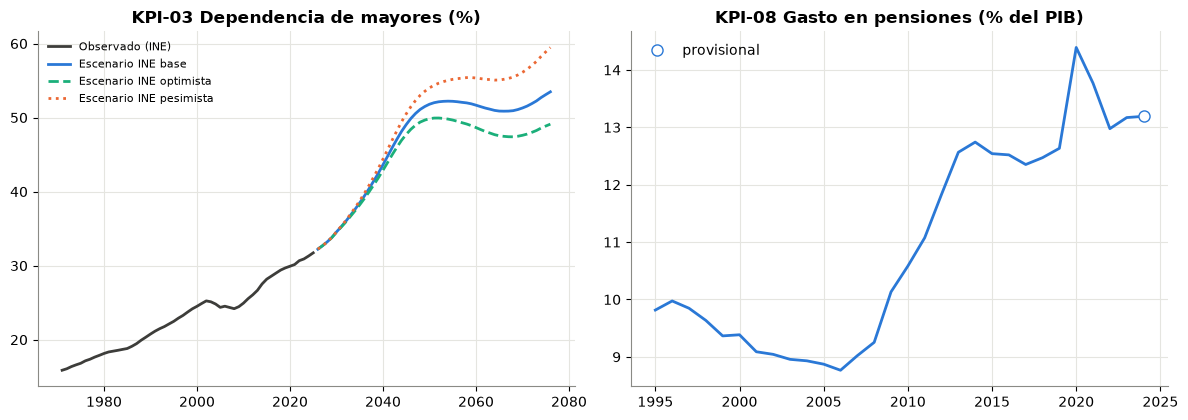

In [118]:
# Resultado integrado: KPI-03 observado y escenarios oficiales, y KPI-08 desde la base consolidada
obs = pd.read_sql("SELECT anyo, codigo_indicador, valor, estado_dato FROM vw_indicadores_observados WHERE codigo_sexo='total' AND codigo_grupo='total'", con)
proy = pd.read_sql("""SELECT anyo, escenario_kr, codigo_indicador, valor FROM vw_proyecciones
                      WHERE codigo_sexo='total' AND codigo_grupo='total' AND escenario_kr IN ('base','optimista','pesimista')""", con)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
o = obs[obs.codigo_indicador == "tasa_dependencia_mayores"].sort_values("anyo")
axes[0].plot(o.anyo, o.valor, color=TINTA, label="Observado (INE)")
for kr, (estilo, color) in {"base": ("-", SERIES[0]), "optimista": ("--", SERIES[2]), "pesimista": (":", SERIES[1])}.items():
    p = proy[(proy.codigo_indicador == "tasa_dependencia_mayores") & (proy.escenario_kr == kr)].sort_values("anyo")
    axes[0].plot(p.anyo, p.valor, estilo, color=color, label=f"Escenario INE {kr}")
axes[0].set_title("KPI-03 Dependencia de mayores (%)"); axes[0].legend(frameon=False, fontsize=8)
g = obs[obs.codigo_indicador == "gasto_pensiones_pib"].sort_values("anyo")
axes[1].plot(g.anyo, g.valor, color=SERIES[0])
prov = g[g.estado_dato == "provisional"]
axes[1].plot(prov.anyo, prov.valor, "o", color=SERIES[0], markerfacecolor="white", markersize=8, label="provisional")
axes[1].set_title("KPI-08 Gasto en pensiones (% del PIB)"); axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

# PARTE 7 · Automatización del pipeline con la librería `schedule`

Las fuentes publican de forma periódica: el INE y Eurostat actualizan y revisan sus tablas, y la Seguridad Social publica cada mes. Para no depender de una ejecución manual, el pipeline completo (extracción → Plata → Oro → carga) se programa con **`schedule`**.

**Cómo funciona `schedule`.** Se declara *qué* ejecutar y *cuándo* (`schedule.every().monday.at("06:00").do(tarea)`), y un bucle llama a `run_pending()`

| Pieza | Archivo | Función |
|---|---|---|
| Configuración | `config/config.yaml › programacion` | Frecuencia (`diaria`, `semanal`, `cada_minutos`, `cada_segundos`), día, hora, tramo de etapas y ruta del registro |
| Programador | `src/programacion.py` (`ProgramadorETL`) | Declara el trabajo en un `schedule.Scheduler`, ejecuta el pipeline, **registra** cada ejecución en `logs/programacion.jsonl` y **aísla los fallos** (un error se registra y se reintenta en la siguiente ejecución, sin detener el programador) |
| Punto de entrada | `programar.py` | `python programar.py` (deja el programador activo), `--ahora` (ejecuta al arrancar) y `--una-vez` (una ejecución y termina) |
| Pruebas | `tests/test_programacion.py` | Frecuencias, validación de la configuración, ejecución programada con reloj simulado y aislamiento de fallos |

## 7.1 El mecanismo, con una tarea mínima

In [119]:
import schedule
from datetime import datetime

reloj = schedule.Scheduler()                       # programador propio (no el global), como en src/programacion.py
marcas = []
reloj.every(2).seconds.do(lambda: marcas.append(datetime.now().strftime("%H:%M:%S")))
print("Trabajo declarado:", reloj.jobs[0])
while len(marcas) < 3:                            # bucle de schedule: comprobar cada medio segundo si toca ejecutar
    reloj.run_pending()
    time.sleep(0.5)
print("La tarea se ejecutó a las:", marcas)

Trabajo declarado: Job(interval=2, unit=seconds, do=<lambda>, args=(), kwargs={})
La tarea se ejecutó a las: ['19:04:07', '19:04:09', '19:04:11']


## 7.2 La programación del proyecto
Por defecto, el pipeline completo se ejecuta cada lunes a las 06:00 (hora local). Una frecuencia semanal basta para recoger las publicaciones mensuales de la Seguridad Social y las revisiones del INE y de Eurostat sin descargar de más.

In [120]:
from src.programacion import ProgramadorETL

display(pd.Series(config["programacion"], name="config.yaml › programacion").to_frame())
programador = ProgramadorETL(config)
trabajo = programador.programar()
print("Trabajo programado :", trabajo)
DIAS = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
print("Próxima ejecución  :", f"{DIAS[trabajo.next_run.weekday()]} {trabajo.next_run:%d/%m/%Y %H:%M}")
programador.detener()                               # en el notebook no se deja activo; en producción lo mantiene programar.py

,config.yaml › programacion
frecuencia,semanal
dia,lunes
hora,06:00
intervalo,60
desde,bronce
hasta,carga
registro,logs/programacion.jsonl


Trabajo programado : Job(interval=1, unit=weeks, do=ejecutar_trabajo, args=(), kwargs={})
Próxima ejecución  : lunes 05/10/2026 06:00


## 7.3 Demostración: ejecución programada del pipeline
Para no esperar hasta el lunes, se usa una copia de la configuración con frecuencia cada 10 segundos y se deja que `schedule` lance **una** ejecución del pipeline. Con `DEMO_DESDE = "bronce"` la ejecución incluye la extracción automática de las tres fuentes (descarga en vivo, ≈ 1-2 minutos y ≈ 20 MB más en Bronce).

In [121]:
DEMO_DESDE = "bronce"

config_demo = copy.deepcopy(config)
config_demo["programacion"].update({"frecuencia": "cada_segundos", "intervalo": 10, "desde": DEMO_DESDE, "hasta": "carga"})
programador_demo = ProgramadorETL(config_demo)
trabajo_demo = programador_demo.programar()
print(f"Trabajo: {trabajo_demo} · próxima ejecución {trabajo_demo.next_run:%H:%M:%S}")
ejecuciones = programador_demo.iniciar(max_ejecuciones=1, espera_s=1)
programador_demo.detener()
pd.DataFrame(ejecuciones)

Trabajo: Job(interval=10, unit=seconds, do=ejecutar_trabajo, args=(), kwargs={}) · próxima ejecución 19:05:00


────────────── INICIO | Pipeline pipeline_20261004T000500.211397Z · etapas bronce → carga · 13 pasos ──────────────

PASO | 1/13 · Bronce · descarga de las tablas del INE (API JSON)

  OK | 56934 · Población por sexo y edad: 3 consultas descargadas (HTTP 200, 3,99 MB)

  OK | 6566 · Fenómenos demográficos por tipo de fenómeno demográfico: 1 consulta descargada (HTTP 200, 23,2 KB)

...

  OK | SQLite: data/serving/pensiones_espana.sqlite (14 tablas, 3 vistas, integridad referencial verificada)

  OK | CSV para Power BI: data/serving/csv · scripts PostgreSQL: data/serving/postgresql

  OK | Registro de ejecución: logs/ejecuciones/pipeline_20261004T000500.211397Z.json

──────────────────────────────────────── FIN | Pipeline completado en 98 s ────────────────────────────────────────

,inicio_utc,desde,hasta,estado,run_id,error,fin_utc,duracion_s
0,2026-10-04T00:05:00Z,bronce,carga,completada,pipeline_20261004T000500.211397Z,None,2026-10-04T00:06:38Z,98.492


In [122]:
# Registro persistente de las ejecuciones programadas (una línea JSON por ejecución)
pd.read_json(config["programacion"]["registro"], lines=True).tail(5)

,inicio_utc,desde,hasta,estado,run_id,error,fin_utc,duracion_s
0,2026-10-02T03:11:16Z,plata,carga,completada,pipeline_20261002T031116.239506Z,NaN,2026-10-02T03:11:20Z,4.060
1,2026-10-02T03:17:27Z,bronce,carga,completada,pipeline_20261002T031727.434781Z,NaN,2026-10-02T03:19:34Z,126.753
2,2026-10-04T00:05:00Z,bronce,carga,completada,pipeline_20261004T000500.211397Z,NaN,2026-10-04T00:06:38Z,98.492


## 7.4 Ejecución fuera del notebook

```bash
python programar.py            # deja el programador activo según config.yaml (Ctrl+C para detenerlo)
python programar.py --ahora    # ejecuta una vez al arrancar y después según la programación
python programar.py --una-vez  # una sola ejecución y termina (código de salida 0 si se completó)
```
**Garantías del diseño:**
- Cada ejecución automática deja su rastro en `logs/programacion.jsonl` (inicio, fin, duración, estado, `run_id` del pipeline y error) además del registro detallado del pipeline en `logs/ejecuciones/`.
- Un fallo (por ejemplo, el INE no responde) no detiene el programador ni toca los datos publicados: la capa que falla no se publica y Power BI sigue leyendo la última versión aprobada.
- Bronce nunca se sobrescribe: cada ejecución guarda una versión nueva con su manifiesto, de modo que las revisiones de las fuentes quedan trazadas.

# Conclusiones

| OKR | Evidencia en este notebook |
|---|---|
| **O1** Integración con calidad y trazabilidad | 3 fuentes extraídas con conexión controlada y cerrada (Parte 1); perfil de calidad completo (Parte 3); tratamiento justificado de nulos, duplicados y categorías (Parte 6); reconciliación exacta de filas; integridad referencial; linaje hasta la URL de origen; ejecución automática (Parte 7) |
| **O2** Indicadores y tablero | 8 KPIs calculados por el pipeline y verificados contra el cálculo manual sobre el dato original (Partes 5 y 6); base consolidada para Power BI |
| **O3** Uso analítico | 15 preguntas de negocio respondidas (Parte 5); escenarios oficiales del INE en una capa separada |

**Limitaciones:** KPI-07 por *pensión*, no por *pensionista*; pensiones disponibles desde 2016; ruptura de la serie migratoria en 2021; PIB y gasto recientes provisionales; ámbito nacional; los escenarios son demográficos, no fiscales; los scripts de PostgreSQL se generan pero no se ejecutaron contra un servidor.

La documentación completa está en `docs/` (índice en el `README.md`).

In [114]:
con.close()